# Initialization


In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd

%matplotlib inline

#REPO = Path.cwd()

#if not (REPO / "new-results").exists():
 #   REPO = Path("/Users/ramontorres/Desktop/sustainability")
REPO = Path("/Users/ramontorres/Desktop/sustainability/new-results/")
RESULTS_DIR = REPO
ANALYSIS_DIR = REPO
FIGURES_DIR = ANALYSIS_DIR / "figures" / "section5"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f'REPO: {REPO}')
print(f'RESULTS_DIR: {RESULTS_DIR}')
print(f'RESULTS_DIR exists: {RESULTS_DIR.exists()}')
print(f'Contents: {list(RESULTS_DIR.iterdir())[:5]}')


NETWORKS = ["n1", "n2", "n4", "n5", "n6"]
NETWORK_RUN_IDS = {"n1": 1, "n2": 2, "n4": 4, "n5": 5, "n6": 6}

CONFIG_ORDER = [
    "baseline",
    "a0.20-k0.10-q1",
    "a0.30-k0.10-q1",
    "a0.50-k0.10-q1",
    "a1.0-k0.04-q1",
    "a1.0-k0.10-q1",
]
CONFIG_LABELS = {
    "baseline": "Baseline",
    "a0.20-k0.10-q1": "T90",
    "a0.30-k0.10-q1": "T85",
    "a0.50-k0.10-q1": "T80",
    "a1.0-k0.04-q1": "T75",
    "a1.0-k0.10-q1": "T70",
}
CONFIG_COLORS = {
    "baseline": "#3B3B3B",
    "a0.20-k0.10-q1": "#1F77B4",
    "a0.30-k0.10-q1": "#2CA02C",
    "a0.50-k0.10-q1": "#D62728",
    "a1.0-k0.04-q1": "#9467BD",
    "a1.0-k0.10-q1": "#E97451",
}
CONFIG_MARKERS = {
    "baseline": "o",
    "a0.20-k0.10-q1": "s",
    "a0.30-k0.10-q1": "^",
    "a0.50-k0.10-q1": "D",
    "a1.0-k0.04-q1": "v",
    "a1.0-k0.10-q1": "*",
}

FONT_SIZE = 22
LABEL_SIZE = 24
LEGEND_SIZE = 22
LINE_WIDTH = 3.2
MARKER_SIZE = 9

def save_figure(fig, out_path, **kwargs):
    out_path = Path(out_path)
    pdf_path = out_path.with_suffix(".pdf")
    fig.savefig(out_path, **kwargs)
    fig.savefig(pdf_path, **kwargs)
    return out_path, pdf_path


REPO: /Users/ramontorres/Desktop/sustainability/new-results
RESULTS_DIR: /Users/ramontorres/Desktop/sustainability/new-results
RESULTS_DIR exists: True
Contents: [PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/section5_carbon_optimization.ipynb'), PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/figs.tar.gz'), PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n6'), PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n1'), PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/savings_boxplot.png')]


In [2]:
from math import sqrt
SPINE_COLOR = 'gray'

def latexify(fig_width=None, fig_height=None, columns=1):
    """Set up matplotlib's RC params for LaTeX plotting.
    Call this before plotting a figure.
    Parameters
    ----------
    fig_width : float, optional, inches
    fig_height : float,  optional, inches
    columns : {1, 2}
    """

    # code adapted from http://www.scipy.org/Cookbook/Matplotlib/LaTeX_Examples

    # Width and max height in inches for IEEE journals taken from
    # computer.org/cms/Computer.org/Journal%20templates/transactions_art_guide.pdf

    assert(columns in [1,2])

    if fig_width is None:
        fig_width = 3.39 if columns==1 else 6.9 # width in inches

    if fig_height is None:
        golden_mean = (sqrt(5)-1.0)/2.0    # Aesthetic ratio
        fig_height = fig_width*golden_mean # height in inches

    MAX_HEIGHT_INCHES = 8.0
    if fig_height > MAX_HEIGHT_INCHES:
        print("WARNING: fig_height too large:" + fig_height +
              "so will reduce to" + MAX_HEIGHT_INCHES + "inches.")
        fig_height = MAX_HEIGHT_INCHES

    params = {'backend': 'ps',
              'text.latex.preamble': ['\\usepackage{gensymb}'],
              'axes.labelsize': 8, # fontsize for x and y labels (was 10)
              'axes.titlesize': 8,
              'font.size': 8, # was 10
              'legend.fontsize': 8, # was 10
              'xtick.labelsize': 8,
              'ytick.labelsize': 8,
              'text.usetex': True,
              'figure.figsize': [fig_width,fig_height],
              'font.family': 'times new roman'
    }

    #matplotlib.rcParams.update(params)
    return params


def format_axes(ax):

    for spine in ['top', 'right']:
        ax.spines[spine].set_color(SPINE_COLOR)
        ax.spines[spine].set_linewidth(0.5)

    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(SPINE_COLOR)
        ax.spines[spine].set_linewidth(0.5)

    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_tick_params(direction='in', color=SPINE_COLOR)

    return ax

latexify()

def getCDF(data):
    xdata = np.sort(data)
    ydata = [i/len(xdata) for i in range(len(xdata))]
    return xdata, ydata

def getCDFish(data):
    xdata = np.sort(data)
    ydata = [i for i in range(len(xdata))]
    return xdata, ydata

import re
def atoi(text):
    return int(text) if text.isdigit() else text

def natural_keys(text):
    '''
    alist.sort(key=natural_keys) sorts in human order
    http://nedbatchelder.com/blog/200712/human_sorting.html
    (See Toothy's implementation in the comments)
    '''
    return [ atoi(c) for c in re.split(r'(\d+)', text) ]

TIMESTAMP_STR_FORMATS = [
    '%Y%m%d_%H:%M:%S',
    '%Y-%m-%d %H:%M:%S.%f',
    '%Y%m%d %H:%M:%S',
    '%Y-%m-%d_%H:%M:%S',
    '%Y-%m-%dT%H:%M:%S.%f',
    '%H:%M:%S.%f',
    '%Y-%m-%dT%H:%M:%S.%f%z',
    '%Y%m%dT%H:%M:%S',
    '%Y-%m-%d_%H:%M:%S.%f',
    '%Y%m%d_%H:%M:%S.%f',
    '%Y-%m-%dT%H:%M:%S',
    '%Y-%m-%d %H:%M:%S',
    '%Y%m%dT%H:%M:%S.%f',
    '%H:%M:%S',
    '%Y%m%d %H:%M:%S.%f']

def to_epoch(t_str):
    """
    Covert a timestamp string to an epoch number.
    :param str t_str: a timestamp string.
    :return int: epoch number of the timestamp.
    """
    try:
        t = float(t_str)
        return t
    except ValueError:
        for format in TIMESTAMP_STR_FORMATS:
            try:
                t = datetime.datetime.strptime(t_str, format)
                return float(time.mktime(t.utctimetuple()) * 1000.0 + t.microsecond / 1000.0)
            except ValueError:
                pass
    raise exceptions.InvalidDataFormat


# Section 5 - carbon optimization

First pass over the Shadow results for the NDSS draft.


## Load data

In [210]:
# Config paths are a little different for n4, so normalize them here.
config_paths = {
    "n4": {
        "baseline": RESULTS_DIR / "n4" / "baseline",
        "a0.20-k0.10-q1": RESULTS_DIR / "n4" / "a0.20-k0.10-q1",
        "a0.30-k0.10-q1": RESULTS_DIR / "n4" / "a0.30-k0.10-q1",
        "a0.50-k0.10-q1": RESULTS_DIR / "n4"  / "a0.50-k0.10-q1",
        "a1.0-k0.04-q1": RESULTS_DIR / "n4"  / "a1.0-k0.04-q1",
        "a1.0-k0.10-q1": RESULTS_DIR / "n4" / "a1.0-k0.10-q1",
    }
}

for network in ["n1", "n2", "n5", "n6"]:
    base = RESULTS_DIR / f"{network}"
    config_paths[network] = {config: base / config for config in CONFIG_ORDER}


def hour_dirs_for(network, config_dir):
    run_id = NETWORK_RUN_IDS[network]
    hour_dirs = [
        p for p in config_dir.glob("*_Hour_*")
        if re.search(rf"_Run_{run_id}_Hour_\d+$", p.name)
    ]
    if not hour_dirs:
        hour_dirs = list(config_dir.glob("*_Hour_*"))
    return sorted(
        hour_dirs,
        key=lambda p: int(re.search(r"_Hour_(\d+)$", p.name).group(1)),
    )

config_paths


{'n4': {'baseline': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n4/baseline'),
  'a0.20-k0.10-q1': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n4/a0.20-k0.10-q1'),
  'a0.30-k0.10-q1': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n4/a0.30-k0.10-q1'),
  'a0.50-k0.10-q1': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n4/a0.50-k0.10-q1'),
  'a1.0-k0.04-q1': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n4/a1.0-k0.04-q1'),
  'a1.0-k0.10-q1': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n4/a1.0-k0.10-q1')},
 'n1': {'baseline': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n1/baseline'),
  'a0.20-k0.10-q1': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n1/a0.20-k0.10-q1'),
  'a0.30-k0.10-q1': PosixPath('/Users/ramontorres/Desktop/sustainability/new-results/n1/a0.30-k0.10-q1'),
  'a0.50-k0.10-q1': PosixPath('/Users/ramontorres/Desktop/sus

In [211]:
# Debug: check which paths exist
for network in NETWORKS:
    for config in CONFIG_ORDER:
        p = config_paths.get(network, {}).get(config)
        if p is None:
            print(f'{network}/{config}: NO PATH')
        elif not p.exists():
            print(f'{network}/{config}: PATH NOT FOUND — {p}')
        else:
            hours = hour_dirs_for(network, p)
            print(f'{network}/{config}: OK — {len(hours)} hours — {p}')



# One row per network/config/hour.
summary_rows = []
missing_rows = []

for network in NETWORKS:
    for config in CONFIG_ORDER:
        config_dir = config_paths[network][config]
        hour_dirs = hour_dirs_for(network, config_dir)

        for hour_dir in hour_dirs:
            match = re.search(r"_Hour_(\d+)$", hour_dir.name)
            if not match:
                continue
            hour = int(match.group(1))
            emissions_path = hour_dir / "cache_emissions.csv"
            tgen_path = hour_dir / "cache_tgen.json"

            if not emissions_path.exists():
                missing_rows.append({"network": network, "config": config, "hour": hour, "missing": "cache_emissions.csv"})
                continue

            emissions = pd.read_csv(emissions_path)
            tgen = {}
            if tgen_path.exists():
                tgen = json.loads(tgen_path.read_text())

            summary_rows.append({
                "network": network,
                "config": config,
                "config_label": CONFIG_LABELS[config],
                "hour": hour,
                "relay_rows": len(emissions),
                "throughput_bytes": emissions["throughput"].sum(),
                "carbon_emissions": emissions["carbon_emissions"].sum(),
                "energy_kwh": emissions["energy_kwh"].sum(),
                "circuits_built": emissions["circuits_built"].sum() if "circuits_built" in emissions else np.nan,
                "tgen_perf_actual": tgen.get("perf_actual", np.nan),
                "tgen_markov_recv": tgen.get("markov_recv", np.nan),
                "source_dir": str(hour_dir.relative_to(REPO)),
            })

master_df = pd.DataFrame(summary_rows)
master_df["throughput_gib"] = master_df["throughput_bytes"] / 1024**3
master_df["network_label"] = master_df["network"].str.upper()

missing_df = pd.DataFrame(missing_rows)

print(f"Loaded {len(master_df):,} hourly config rows")
print(f"Missing rows: {len(missing_df):,}")
master_df.head()


n1/baseline: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n1/baseline
n1/a0.20-k0.10-q1: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n1/a0.20-k0.10-q1
n1/a0.30-k0.10-q1: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n1/a0.30-k0.10-q1
n1/a0.50-k0.10-q1: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n1/a0.50-k0.10-q1
n1/a1.0-k0.04-q1: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n1/a1.0-k0.04-q1
n1/a1.0-k0.10-q1: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n1/a1.0-k0.10-q1
n2/baseline: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n2/baseline
n2/a0.20-k0.10-q1: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n2/a0.20-k0.10-q1
n2/a0.30-k0.10-q1: OK — 24 hours — /Users/ramontorres/Desktop/sustainability/new-results/n2/a0.30-k0.10-q1
n2/a0.50-k0.10-q1: OK — 24 hours — /Users/ramontorres/Desktop/sus

,network,config,config_label,hour,relay_rows,throughput_bytes,carbon_emissions,energy_kwh,circuits_built,tgen_perf_actual,tgen_markov_recv,source_dir,throughput_gib,network_label
0,n1,baseline,Baseline,0,618,2021838802902,307.091504,1.895332,78669,2450612224,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_0,1882.984119,N1
1,n1,baseline,Baseline,1,618,2051781016269,308.817096,1.915031,78637,2271129600,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_1,1910.869979,N1
2,n1,baseline,Baseline,2,618,2071985484259,316.334227,1.934472,78643,2276935680,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_2,1929.686856,N1
3,n1,baseline,Baseline,3,618,1970253920287,303.635473,1.851555,78612,2271922176,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_3,1834.941954,N1
4,n1,baseline,Baseline,4,618,2102944411750,316.213746,1.958131,78693,2351204352,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_4,1958.519604,N1


In [212]:
# Quick coverage check before plotting.
config_rank = {config: i for i, config in enumerate(CONFIG_ORDER)}
coverage = (
    master_df.groupby(["network", "config"], as_index=False)
    .agg(hours=("hour", "nunique"), throughput_gib=("throughput_gib", "sum"), carbon=("carbon_emissions", "sum"))
)
coverage["config_rank"] = coverage["config"].map(config_rank)
coverage = coverage.sort_values(["network", "config_rank"]).drop(columns="config_rank")

coverage

,network,config,hours,throughput_gib,carbon
5,n1,baseline,24,49847.751728,8198.904338
0,n1,a0.20-k0.10-q1,24,49177.441923,6452.674216
1,n1,a0.30-k0.10-q1,24,48797.653263,5781.401983
2,n1,a0.50-k0.10-q1,24,48045.664365,4690.180174
3,n1,a1.0-k0.04-q1,24,46178.560691,2917.685943
4,n1,a1.0-k0.10-q1,24,43819.684027,1946.798204
11,n2,baseline,24,49685.015692,8435.439001
6,n2,a0.20-k0.10-q1,24,49005.120967,6656.990346
7,n2,a0.30-k0.10-q1,24,48645.095203,5984.755281
8,n2,a0.50-k0.10-q1,24,48019.791230,4874.239138


## Data and carbon over time

In [213]:
# Compare each config to the same network's baseline in the same hour.
baseline_hourly = (
    master_df[master_df["config"] == "baseline"]
    [["network", "hour", "throughput_bytes", "carbon_emissions"]]
    .rename(columns={
        "throughput_bytes": "baseline_throughput_bytes",
        "carbon_emissions": "baseline_carbon_emissions",
    })
)

relative_df = master_df.merge(baseline_hourly, on=["network", "hour"], how="left")
relative_df["throughput_pct_baseline"] = relative_df["throughput_bytes"] / relative_df["baseline_throughput_bytes"] * 100
relative_df["carbon_pct_baseline"] = relative_df["carbon_emissions"] / relative_df["baseline_carbon_emissions"] * 100

relative_df.head()

,network,config,config_label,hour,relay_rows,throughput_bytes,carbon_emissions,energy_kwh,circuits_built,tgen_perf_actual,tgen_markov_recv,source_dir,throughput_gib,network_label,baseline_throughput_bytes,baseline_carbon_emissions,throughput_pct_baseline,carbon_pct_baseline
0,n1,baseline,Baseline,0,618,2021838802902,307.091504,1.895332,78669,2450612224,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_0,1882.984119,N1,2021838802902,307.091504,100.0,100.0
1,n1,baseline,Baseline,1,618,2051781016269,308.817096,1.915031,78637,2271129600,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_1,1910.869979,N1,2051781016269,308.817096,100.0,100.0
2,n1,baseline,Baseline,2,618,2071985484259,316.334227,1.934472,78643,2276935680,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_2,1929.686856,N1,2071985484259,316.334227,100.0,100.0
3,n1,baseline,Baseline,3,618,1970253920287,303.635473,1.851555,78612,2271922176,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_3,1834.941954,N1,1970253920287,303.635473,100.0,100.0
4,n1,baseline,Baseline,4,618,2102944411750,316.213746,1.958131,78693,2351204352,0,n1/baseline/avg_Simulation_0.1_Run_1_Hour_4,1958.519604,N1,2102944411750,316.213746,100.0,100.0


In [214]:
# Treat networks the same: average the per-network baseline-relative values by hour/config.
time_series_df = (
    relative_df.groupby(["config", "config_label", "hour"], as_index=False)
    .agg(
        networks=("network", "nunique"),
        throughput_pct_baseline=("throughput_pct_baseline", "mean"),
        throughput_pct_std=("throughput_pct_baseline", "std"),
        carbon_pct_baseline=("carbon_pct_baseline", "mean"),
        carbon_pct_std=("carbon_pct_baseline", "std"),
    )
)

time_series_df.head()

,config,config_label,hour,networks,throughput_pct_baseline,throughput_pct_std,carbon_pct_baseline,carbon_pct_std
0,a0.20-k0.10-q1,T90,0,5,98.298854,0.490972,78.876717,0.883416
1,a0.20-k0.10-q1,T90,1,5,98.377088,0.473596,79.192151,1.154605
2,a0.20-k0.10-q1,T90,2,5,98.308342,0.495891,78.090181,1.019755
3,a0.20-k0.10-q1,T90,3,5,98.333624,0.528650,78.199005,0.985556
4,a0.20-k0.10-q1,T90,4,5,98.364392,0.486886,78.910415,1.094615


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/data_carbon_pct_baseline_over_time.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/data_carbon_pct_baseline_over_time.pdf


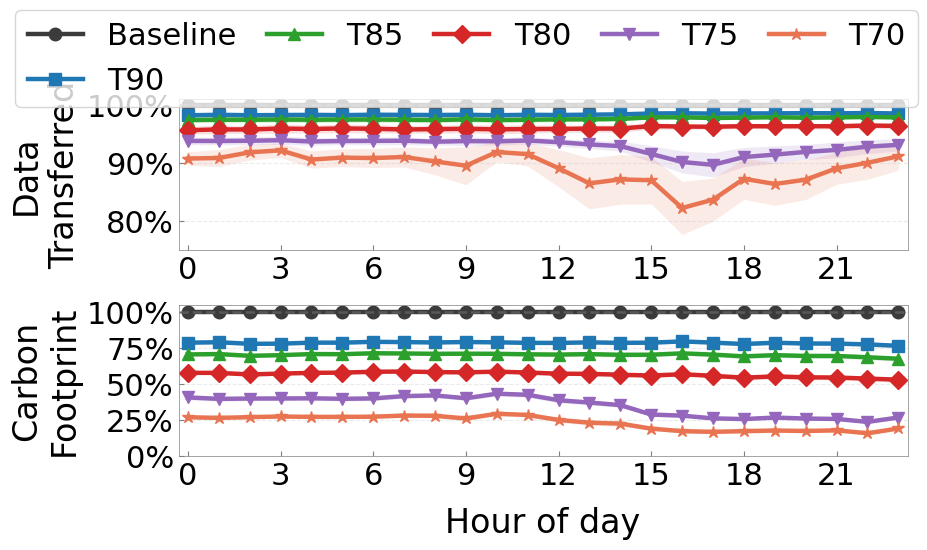

In [215]:
fig, axes = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)

for config in CONFIG_ORDER:
    cfg = time_series_df[time_series_df["config"] == config].sort_values("hour")
    label = CONFIG_LABELS[config]
    color = CONFIG_COLORS[config]
    marker = CONFIG_MARKERS[config]

    hours = cfg["hour"].to_numpy()
    throughput_mean = cfg["throughput_pct_baseline"].to_numpy()
    throughput_std = cfg["throughput_pct_std"].fillna(0).to_numpy()
    carbon_mean = cfg["carbon_pct_baseline"].to_numpy()
    carbon_std = cfg["carbon_pct_std"].fillna(0).to_numpy()

    axes[0].fill_between(
        hours, throughput_mean - throughput_std, throughput_mean + throughput_std,
        color=color, alpha=0.14, linewidth=0,
    )
    axes[0].plot(
        hours, throughput_mean,
        label=label, color=color, marker=marker, linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
    )
    axes[1].fill_between(
        hours, carbon_mean - carbon_std, carbon_mean + carbon_std,
        color=color, alpha=0.14, linewidth=0,
    )
    axes[1].plot(
        hours, carbon_mean,
        label=label, color=color, marker=marker, linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
    )

for ax, ylabel in zip(axes, ["Data\nTransferred", "Carbon\nFootprint"]):
    ax.axhline(100, color="#666666", linestyle="--", linewidth=1.8, alpha=0.7)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE, rotation=90)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    format_axes(ax)

axes[0].set_ylim(bottom=75)
axes[0].set_yticks([80, 90, 100])
axes[1].set_ylim(bottom=0, top=105)
axes[1].set_yticks([0, 25, 50, 75, 100])
axes[1].set_xlabel("Hour of day", fontsize=LABEL_SIZE, labelpad=12)
axes[1].set_xticks(range(0, 24, 3))
axes[1].set_xlim(-0.3, 23.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 0.99), frameon=True, fontsize=LEGEND_SIZE, handlelength=1.8, columnspacing=1.0)

fig.subplots_adjust(left=0.18, right=0.99, bottom=0.15, top=0.80, hspace=0.36)
out_path = FIGURES_DIR / "data_carbon_pct_baseline_over_time.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


In [216]:
# Mean hourly throughput std, inside vs outside hours 13-20, for T75 and T70.
peak_hours = range(13, 21)  # 13, 14, ..., 20 inclusive

hourly_throughput_std_df = (
    time_series_df[time_series_df["config_label"].isin(["T75", "T70"])]
    .pivot(index="hour", columns="config_label", values="throughput_pct_std")
    .sort_index()
)

inside_mean = hourly_throughput_std_df.loc[hourly_throughput_std_df.index.isin(peak_hours)].mean()
outside_mean = hourly_throughput_std_df.loc[~hourly_throughput_std_df.index.isin(peak_hours)].mean()

print("Mean std, hours 13-20:")
print(inside_mean.round(2).map(lambda v: f"{v:.2f}%"))

print("\nMean std, outside hours 13-20:")
print(outside_mean.round(2).map(lambda v: f"{v:.2f}%"))


# Mean hourly carbon emissions std, inside vs outside hours 13-20, for T75 and T70.
peak_hours = range(13, 21)  # 13, 14, ..., 20 inclusive

# Mean carbon emissions std across all hours, for T75 and T70.
carbon_std_summary = (
    time_series_df[time_series_df["config_label"].isin(["T75", "T70"])]
    .groupby("config_label")["carbon_pct_std"]
    .mean()
)

print("\nCARBON EMISSIONS\n")
print(carbon_std_summary.round(2).map(lambda v: f"{v:.2f}%"))

Mean std, hours 13-20:
config_label
T70    3.96%
T75    1.42%
dtype: object

Mean std, outside hours 13-20:
config_label
T70    2.01%
T75    0.77%
dtype: object

CARBON EMISSIONS

config_label
T70    1.32%
T75    1.45%
Name: carbon_pct_std, dtype: object


In [217]:
# T70 throughput and carbon emissions vs baseline: min and max across hours.
t70_df = time_series_df[time_series_df["config_label"] == "T70"]

throughput_min = t70_df["throughput_pct_baseline"].min()
throughput_max = t70_df["throughput_pct_baseline"].max()
carbon_min = t70_df["carbon_pct_baseline"].min()
carbon_max = t70_df["carbon_pct_baseline"].max()

print(f"Throughput (% of baseline) — min: {throughput_min:.2f}%, max: {throughput_max:.2f}%")
print(f"Carbon emissions (% of baseline) — min: {carbon_min:.2f}%, max: {carbon_max:.2f}%")

Throughput (% of baseline) — min: 82.32%, max: 92.26%
Carbon emissions (% of baseline) — min: 16.08%, max: 29.61%


## By network


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/data_carbon_pct_baseline_by_network.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/data_carbon_pct_baseline_by_network.pdf


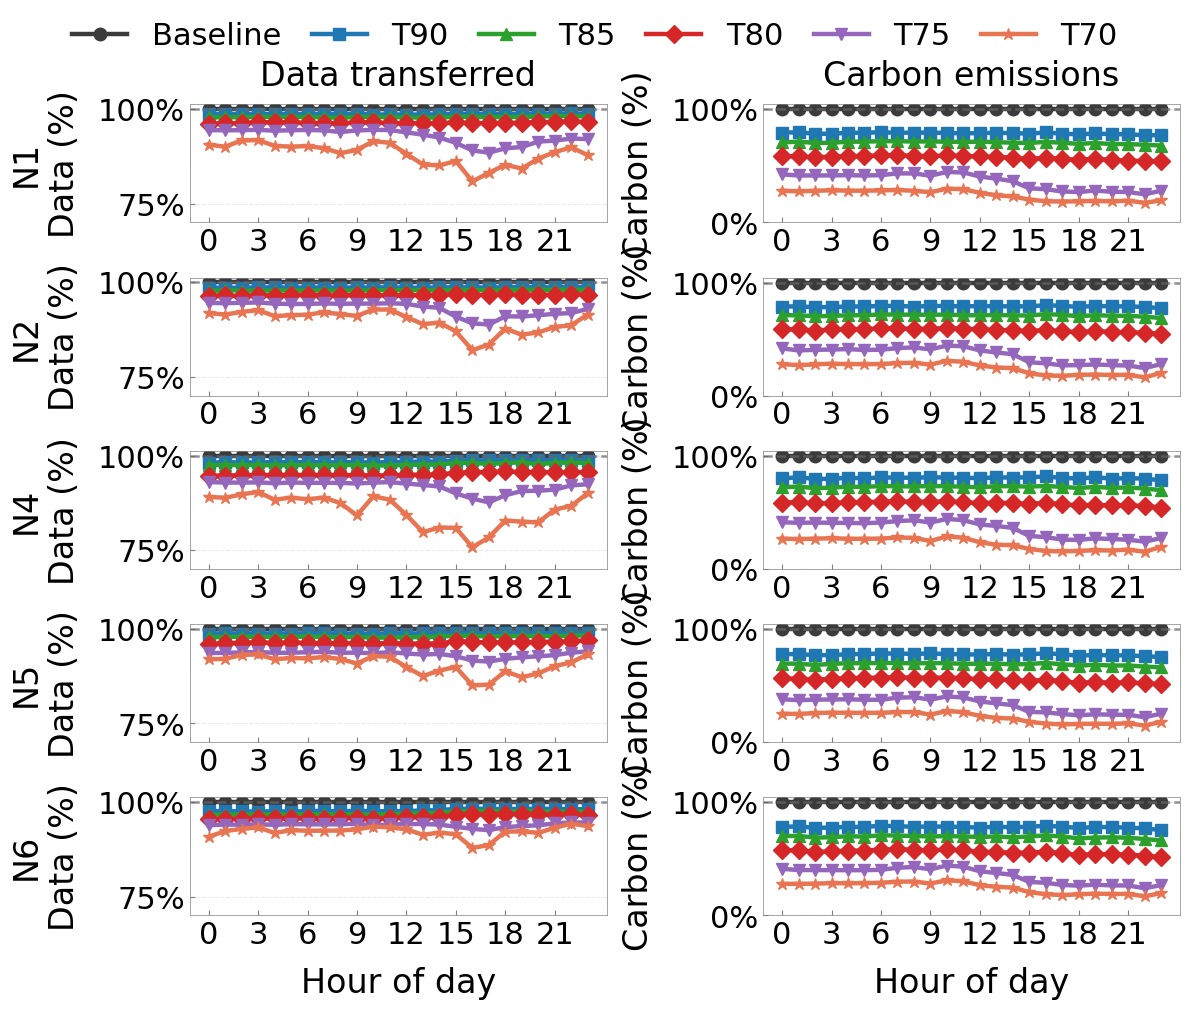

In [218]:
fig, axes = plt.subplots(len(NETWORKS), 2, figsize=(12, 10), sharex=True, sharey="col")

for row, network in enumerate(NETWORKS):
    network_df = relative_df[relative_df["network"] == network]
    for config in CONFIG_ORDER:
        cfg = network_df[network_df["config"] == config].sort_values("hour")
        label = CONFIG_LABELS[config]
        color = CONFIG_COLORS[config]
        marker = CONFIG_MARKERS[config]

        axes[row, 0].plot(
            cfg["hour"], cfg["throughput_pct_baseline"],
            label=label, color=color, marker=marker, linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        )
        axes[row, 1].plot(
            cfg["hour"], cfg["carbon_pct_baseline"],
            label=label, color=color, marker=marker, linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        )

    axes[row, 0].set_ylabel(f"{network.upper()}\nData (%)", fontsize=LABEL_SIZE, labelpad=12)
    axes[row, 1].set_ylabel("Carbon (%)", fontsize=LABEL_SIZE, labelpad=12)

for ax in axes.flat:
    ax.axhline(100, color="#666666", linestyle="--", linewidth=1.8, alpha=0.7)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_xticks(range(0, 24, 3))
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    format_axes(ax)

for row in range(len(NETWORKS)):
    axes[row, 0].set_ylim(bottom=70)
    axes[row, 1].set_ylim(bottom=0)

axes[0, 0].set_title("Data transferred", fontsize=LABEL_SIZE, pad=14)
axes[0, 1].set_title("Carbon emissions", fontsize=LABEL_SIZE, pad=14)
axes[-1, 0].set_xlabel("Hour of day", fontsize=LABEL_SIZE, labelpad=12)
axes[-1, 1].set_xlabel("Hour of day", fontsize=LABEL_SIZE, labelpad=12)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc="upper center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=LEGEND_SIZE, handlelength=1.8, columnspacing=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])

out_path = FIGURES_DIR / "data_carbon_pct_baseline_by_network.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight")
print(png_path)
print(pdf_path)
plt.show()


## Completion and congestion CDFs

CDFs for stream completion time and relay write congestion. The congestion plot keeps one main CDF and uses an inset to zoom into the high-percentile tail.

In [219]:
# Load completion times and daily per-relay congestion.
cdf_labels = {**CONFIG_LABELS, "baseline": "Base."}
completion_parts = []
congestion_hour_parts = []
congestion_skipped_rows = []

for network in NETWORKS:
    for config in CONFIG_ORDER:
        config_dir = config_paths[network][config]
        hour_dirs = hour_dirs_for(network, config_dir)

        for hour_dir in hour_dirs:
            match = re.search(r"_Hour_(\d+)$", hour_dir.name)
            if not match:
                continue
            hour = int(match.group(1))

            completion_path = hour_dir / "cache_completion_times.json"
            if completion_path.exists():
                times = json.loads(completion_path.read_text())
                if times:
                    completion_parts.append(pd.DataFrame({
                        "network": network,
                        "config": config,
                        "config_label": CONFIG_LABELS[config],
                        "hour": hour,
                        "time_s": times,
                    }))

            emissions_path = hour_dir / "cache_emissions.csv"
            if not emissions_path.exists():
                continue
            columns = pd.read_csv(emissions_path, nrows=0).columns
            needed = {"relay", "write_congested_s", "read_congested_s"}
            if not needed.issubset(columns):
                congestion_skipped_rows.append({
                    "network": network,
                    "config": config,
                    "hour": hour,
                    "source_dir": str(hour_dir.relative_to(REPO)),
                })
                continue

            congestion_hour = pd.read_csv(
                emissions_path,
                usecols=["relay", "write_congested_s", "read_congested_s"],
            )
            congestion_hour["network"] = network
            congestion_hour["config"] = config
            congestion_hour["config_label"] = CONFIG_LABELS[config]
            congestion_hour["hour"] = hour
            congestion_hour_parts.append(congestion_hour)

completion_df = pd.concat(completion_parts, ignore_index=True)
completion_df["config_label"] = completion_df["config"].map(CONFIG_LABELS)

congestion_hour_df = pd.concat(congestion_hour_parts, ignore_index=True)
congestion_relay_df = (
    congestion_hour_df.groupby(["network", "config", "config_label", "relay"], as_index=False)
    .agg(
        write_congested_s=("write_congested_s", "sum"),
        read_congested_s=("read_congested_s", "sum"),
    )
)
congestion_relay_df["total_congested_s"] = congestion_relay_df["write_congested_s"] + congestion_relay_df["read_congested_s"]
congestion_skipped_df = pd.DataFrame(congestion_skipped_rows)

print(f"Completion observations: {len(completion_df):,}")
print(f"Daily relay congestion rows: {len(congestion_relay_df):,}")
print(f"Skipped congestion files: {len(congestion_skipped_df):,}")
completion_df.head()


Completion observations: 3,070,618
Daily relay congestion rows: 16,516
Skipped congestion files: 76


,network,config,config_label,hour,time_s
0,n1,baseline,Baseline,0,2.759692
1,n1,baseline,Baseline,0,1.373089
2,n1,baseline,Baseline,0,5.611827
3,n1,baseline,Baseline,0,1.674852
4,n1,baseline,Baseline,0,1.513605


In [220]:
# Quick CDF summaries.
completion_summary_df = (
    completion_df.groupby(["config", "config_label"])["time_s"]
    .quantile([0.5, 0.9, 0.95, 0.99])
    .unstack()
    .rename(columns={0.5: "p50_s", 0.9: "p90_s", 0.95: "p95_s", 0.99: "p99_s"})
    .reset_index()
)
completion_summary_df["streams"] = completion_summary_df["config"].map(completion_df.groupby("config").size())
completion_summary_df["config_rank"] = completion_summary_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
completion_summary_df = completion_summary_df.sort_values("config_rank").drop(columns="config_rank")

congestion_summary_rows = []
for config in CONFIG_ORDER:
    vals = congestion_relay_df.loc[congestion_relay_df["config"] == config, "write_congested_s"].to_numpy()
    congestion_summary_rows.append({
        "config": config,
        "config_label": CONFIG_LABELS[config],
        "relays": len(vals),
        "congested_relays": int((vals > 0).sum()),
        "congested_pct": (vals > 0).mean() * 100 if len(vals) else np.nan,
        "p90_s": np.percentile(vals, 90) if len(vals) else np.nan,
        "p95_s": np.percentile(vals, 95) if len(vals) else np.nan,
        "p99_s": np.percentile(vals, 99) if len(vals) else np.nan,
        "max_s": vals.max() if len(vals) else np.nan,
    })
congestion_summary_df = pd.DataFrame(congestion_summary_rows)

completion_summary_df, congestion_summary_df

(           config config_label     p50_s      p90_s      p95_s      p99_s  \
 5        baseline     Baseline  1.805540   3.167535   3.576956   4.402722   
 0  a0.20-k0.10-q1          T90  1.823999   3.276658   3.784238  12.062512   
 1  a0.30-k0.10-q1          T85  1.854608   3.394935   4.015153  18.446538   
 2  a0.50-k0.10-q1          T80  1.942930   3.886787   6.307340  60.000000   
 3   a1.0-k0.04-q1          T75  2.049454   5.885163  15.000000  60.000000   
 4   a1.0-k0.10-q1          T70  2.225644  11.940437  22.945602  60.000000   
 
    streams  
 5   511917  
 0   511889  
 1   511881  
 2   511759  
 3   511634  
 4   511538  ,
            config config_label  relays  congested_relays  congested_pct  \
 0        baseline     Baseline    3094                 2       0.064641   
 1  a0.20-k0.10-q1          T90    3222               228       7.076350   
 2  a0.30-k0.10-q1          T85    3207               277       8.637356   
 3  a0.50-k0.10-q1          T80    3191          

In [221]:
# Percentage of streams that finish under 5 seconds, per config.
under_5s_df = (
    completion_df.assign(under_5s=completion_df["time_s"] < 5)
    .groupby(["config", "config_label"], as_index=False)
    .agg(
        streams=("time_s", "size"),
        under_5s_count=("under_5s", "sum"),
    )
)
under_5s_df["under_5s_pct"] = under_5s_df["under_5s_count"] / under_5s_df["streams"] * 100
under_5s_df["config_rank"] = under_5s_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
under_5s_df = under_5s_df.sort_values("config_rank").drop(columns="config_rank")

print(under_5s_df[["config_label", "streams", "under_5s_count", "under_5s_pct"]].round(2))

  config_label  streams  under_5s_count  under_5s_pct
5     Baseline   511917          509677         99.56
0          T90   511889          503057         98.27
1          T85   511881          497961         97.28
2          T80   511759          480187         93.83
3          T75   511634          453213         88.58
4          T70   511538          426066         83.29


In [222]:
# Percentage of streams that take longer than 10 seconds, per config.
over_10s_df = (
    completion_df.assign(over_10s=completion_df["time_s"] > 10)
    .groupby(["config", "config_label"], as_index=False)
    .agg(
        streams=("time_s", "size"),
        over_10s_count=("over_10s", "sum"),
    )
)
over_10s_df["over_10s_pct"] = over_10s_df["over_10s_count"] / over_10s_df["streams"] * 100
over_10s_df["config_rank"] = over_10s_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
over_10s_df = over_10s_df.sort_values("config_rank").drop(columns="config_rank")

print(over_10s_df[["config_label", "streams", "over_10s_count", "over_10s_pct"]].round(2))

  config_label  streams  over_10s_count  over_10s_pct
5     Baseline   511917             646          0.13
0          T90   511889            5637          1.10
1          T85   511881            8917          1.74
2          T80   511759           20598          4.02
3          T75   511634           39219          7.67
4          T70   511538           58983         11.53


In [223]:
# Percentage of streams that finish under 1 minute (60s), per config.
under_60s_df = (
    completion_df.assign(under_60s=completion_df["time_s"] < 60)
    .groupby(["config", "config_label"], as_index=False)
    .agg(
        streams=("time_s", "size"),
        under_60s_count=("under_60s", "sum"),
    )
)
under_60s_df["under_60s_pct"] = under_60s_df["under_60s_count"] / under_60s_df["streams"] * 100
under_60s_df["config_rank"] = under_60s_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
under_60s_df = under_60s_df.sort_values("config_rank").drop(columns="config_rank")

print(under_60s_df[["config_label", "streams", "under_60s_count", "under_60s_pct"]].round(2))

# Average % of streams under 60s across all configs, excluding baseline.
avg_under_60s_pct = under_60s_df.loc[under_60s_df["config"] != "baseline", "under_60s_pct"].mean()
print(f"Average % of streams under 60s (excluding baseline): {avg_under_60s_pct:.2f}%")

  config_label  streams  under_60s_count  under_60s_pct
5     Baseline   511917           511512          99.92
0          T90   511889           509706          99.57
1          T85   511881           508583          99.36
2          T80   511759           503536          98.39
3          T75   511634           497980          97.33
4          T70   511538           494035          96.58
Average % of streams under 60s (excluding baseline): 98.25%


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/completion_time_cdf.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/completion_time_cdf.pdf


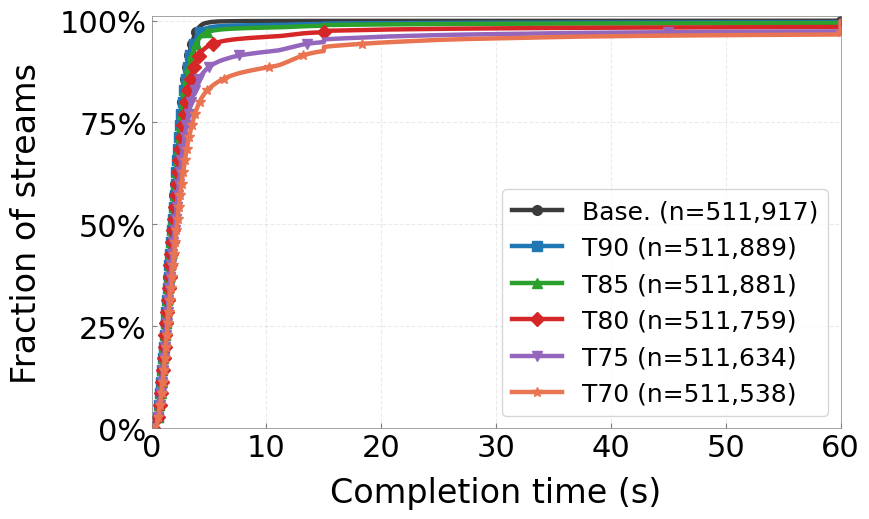

In [224]:
# Figure 11: completion time CDF.
fig, ax = plt.subplots(figsize=(8.8, 5.3))

for config in CONFIG_ORDER:
    times = np.sort(completion_df.loc[completion_df["config"] == config, "time_s"].to_numpy())
    if len(times) == 0:
        continue
    y = np.arange(1, len(times) + 1) / len(times)
    mark_every = max(1, len(times) // 35)
    ax.plot(
        times, y,
        color=CONFIG_COLORS[config], linewidth=LINE_WIDTH,
        marker=CONFIG_MARKERS[config], markersize=7, markevery=mark_every,
        label=f"{cdf_labels[config]} (n={len(times):,})",
    )

ax.set_xlim(0, 60)
ax.set_ylim(0, 1.01)
ax.set_xlabel("Completion time (s)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Fraction of streams", fontsize=LABEL_SIZE, labelpad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.tick_params(axis="both", labelsize=FONT_SIZE)
format_axes(ax)

ax.legend(loc="lower right", frameon=True, fontsize=18)
fig.tight_layout()

out_path = FIGURES_DIR / "completion_time_cdf.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/relay_congestion_cdf_tail_inset.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/relay_congestion_cdf_tail_inset.pdf


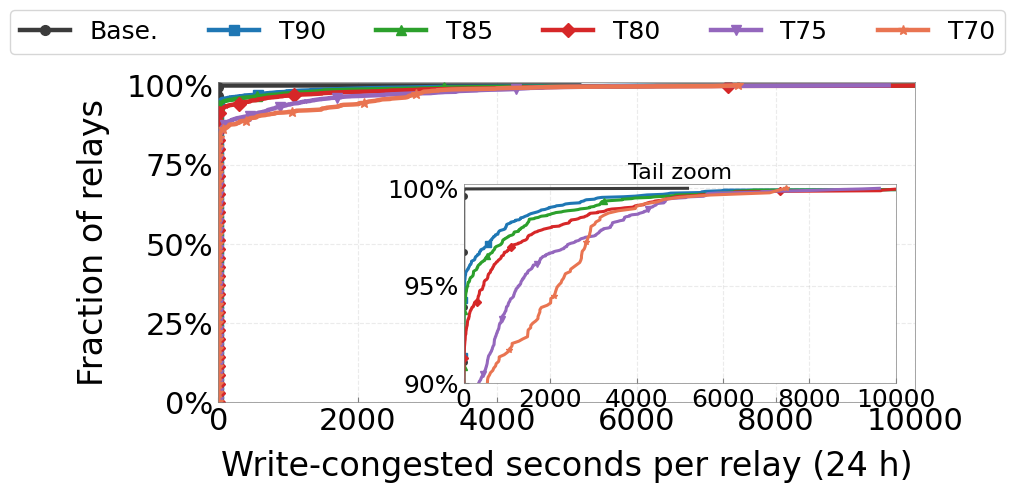

In [302]:
# Figure 12: write congestion CDF with tail inset.
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(8.5, 5))
axins = inset_axes(ax, width="62%", height="62%", loc="lower right", borderpad=1.4)

all_tail_vals = []
for config in CONFIG_ORDER:
    vals = np.sort(congestion_relay_df.loc[congestion_relay_df["config"] == config, "write_congested_s"].to_numpy())
    if len(vals) == 0:
        continue
    y = np.arange(1, len(vals) + 1) / len(vals)
    all_tail_vals.extend(vals)
    mark_every = max(1, len(vals) // 35)

    ax.plot(vals, y, color=CONFIG_COLORS[config], linewidth=LINE_WIDTH, marker=CONFIG_MARKERS[config], markersize=7, markevery=mark_every, label=cdf_labels[config])
    axins.plot(vals, y, color=CONFIG_COLORS[config], linewidth=2.2, marker=CONFIG_MARKERS[config], markersize=4, markevery=mark_every)

tail_xmax = float(np.ceil(np.nanpercentile(all_tail_vals, 99.95) / 1000) * 1000)
tail_xmax = max(1000, tail_xmax)

ax.set_xlim(0, tail_xmax)
ax.set_ylim(0, 1.01)
ax.set_xlabel("Write-congested seconds per relay (24 h)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Fraction of relays", fontsize=LABEL_SIZE, labelpad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.tick_params(axis="both", labelsize=FONT_SIZE)
format_axes(ax)

axins.set_xlim(0, tail_xmax)
axins.set_ylim(0.9, 1.002)
axins.set_title("Tail zoom", fontsize=16, pad=4)
axins.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
axins.set_yticks([0.9, 0.95, 1.0])
axins.grid(axis="both", linestyle="--", alpha=0.25)
axins.tick_params(axis="both", labelsize=FONT_SIZE-4)
format_axes(axins)
#mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.35", linewidth=1.0)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc="upper center", bbox_to_anchor=(0.5, 0.99), frameon=True, fontsize=18)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.18, top=0.82)

out_path = FIGURES_DIR / "relay_congestion_cdf_tail_inset.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


## Exploring

In [226]:
# Average each network's hourly percentages first, then average across networks.
tradeoff_network_df = (
    relative_df.groupby(["network", "config", "config_label"], as_index=False)
    .agg(
        data_pct_baseline=("throughput_pct_baseline", "mean"),
        carbon_pct_baseline=("carbon_pct_baseline", "mean"),
        hours=("hour", "nunique"),
    )
)

tradeoff_df = (
    tradeoff_network_df.groupby(["config", "config_label"], as_index=False)
    .agg(
        networks=("network", "nunique"),
        hours_min=("hours", "min"),
        data_pct_baseline=("data_pct_baseline", "mean"),
        data_pct_std=("data_pct_baseline", "std"),
        carbon_pct_baseline=("carbon_pct_baseline", "mean"),
        carbon_pct_std=("carbon_pct_baseline", "std"),
    )
)
tradeoff_df["data_loss_pct"] = 100 - tradeoff_df["data_pct_baseline"]
tradeoff_df["carbon_saved_pct"] = 100 - tradeoff_df["carbon_pct_baseline"]
tradeoff_df["carbon_saved_per_data_loss"] = np.where(
    tradeoff_df["data_loss_pct"] > 0,
    tradeoff_df["carbon_saved_pct"] / tradeoff_df["data_loss_pct"],
    np.nan,
)
tradeoff_df["carbon_per_gib_pct_baseline"] = (
    tradeoff_df["carbon_pct_baseline"] / tradeoff_df["data_pct_baseline"] * 100
)

tradeoff_df["config_rank"] = tradeoff_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
tradeoff_df = tradeoff_df.sort_values("config_rank").drop(columns="config_rank")
tradeoff_df

,config,config_label,networks,hours_min,data_pct_baseline,data_pct_std,carbon_pct_baseline,carbon_pct_std,data_loss_pct,carbon_saved_pct,carbon_saved_per_data_loss,carbon_per_gib_pct_baseline
5,baseline,Baseline,5,24,100.000000,0.000000,100.000000,0.000000,0.000000,0.000000,NaN,100.000000
0,a0.20-k0.10-q1,T90,5,24,98.462185,0.386459,78.709443,1.103486,1.537815,21.290557,13.844682,79.938753
1,a0.30-k0.10-q1,T85,5,24,97.692400,0.366086,70.458712,1.352260,2.307600,29.541288,12.801734,72.123023
2,a0.50-k0.10-q1,T80,5,24,96.112966,0.593912,56.872223,1.259074,3.887034,43.127777,11.095292,59.172270
3,a1.0-k0.04-q1,T75,5,24,92.961980,0.778463,35.188004,1.424002,7.038020,64.811996,9.208839,37.852038
4,a1.0-k0.10-q1,T70,5,24,89.203571,2.531906,23.537556,1.265991,10.796429,76.462444,7.082198,26.386338


In [227]:
# Add latency and congestion details to the headline table.
summary_table_df = tradeoff_df.merge(
    completion_summary_df[["config", "p95_s", "p99_s"]].rename(columns={
        "p95_s": "completion_p95_s",
        "p99_s": "completion_p99_s",
    }),
    on="config",
    how="left",
).merge(
    congestion_summary_df[["config", "congested_pct", "p99_s"]].rename(columns={
        "p99_s": "write_congestion_p99_s",
    }),
    on="config",
    how="left",
)

summary_table_df["label"] = summary_table_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})
summary_table_df["carbon_saved_per_data_loss"] = summary_table_df["carbon_saved_per_data_loss"].replace([np.inf, -np.inf], np.nan)

summary_display_df = pd.DataFrame({
    "Setting": summary_table_df["label"],
    "Data kept": summary_table_df["data_pct_baseline"].map(lambda v: f"{v:.0f}%"),
    "Carbon left": summary_table_df["carbon_pct_baseline"].map(lambda v: f"{v:.0f}%"),
    "Carbon saved": summary_table_df["carbon_saved_pct"].map(lambda v: f"{v:.0f}%"),
    "Carbon/GiB": summary_table_df["carbon_per_gib_pct_baseline"].map(lambda v: f"{v:.0f}%"),
    "Saved / lost": summary_table_df["carbon_saved_per_data_loss"].map(lambda v: "-" if pd.isna(v) else f"{v:.1f}x"),
    "p95 complete": summary_table_df["completion_p95_s"].map(lambda v: f"{v:.1f}s"),
    "p99 complete": summary_table_df["completion_p99_s"].map(lambda v: f"{v:.1f}s"),
    "Congested relays": summary_table_df["congested_pct"].map(lambda v: f"{v:.1f}%"),
    "p99 congestion": summary_table_df["write_congestion_p99_s"].map(lambda v: f"{v/60:.1f}m"),
})

summary_csv_path = FIGURES_DIR / "headline_tradeoff_summary.csv"
summary_display_df.to_csv(summary_csv_path, index=False)
print(summary_csv_path)
summary_display_df

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/headline_tradeoff_summary.csv


,Setting,Data kept,Carbon left,Carbon saved,Carbon/GiB,Saved / lost,p95 complete,p99 complete,Congested relays,p99 congestion
0,Base.,100%,100%,0%,100%,-,3.6s,4.4s,0.1%,0.0m
1,T90,98%,79%,21%,80%,13.8x,3.8s,12.1s,7.1%,32.8m
2,T85,98%,70%,30%,72%,12.8x,4.0s,18.4s,8.6%,48.5m
3,T80,96%,57%,43%,59%,11.1x,6.3s,60.0s,10.6%,62.4m
4,T75,93%,35%,65%,38%,9.2x,15.0s,60.0s,18.0%,71.9m
5,T70,89%,24%,76%,26%,7.1x,22.9s,60.0s,20.1%,66.3m


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/headline_carbon_saved_vs_data_loss.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/headline_carbon_saved_vs_data_loss.pdf


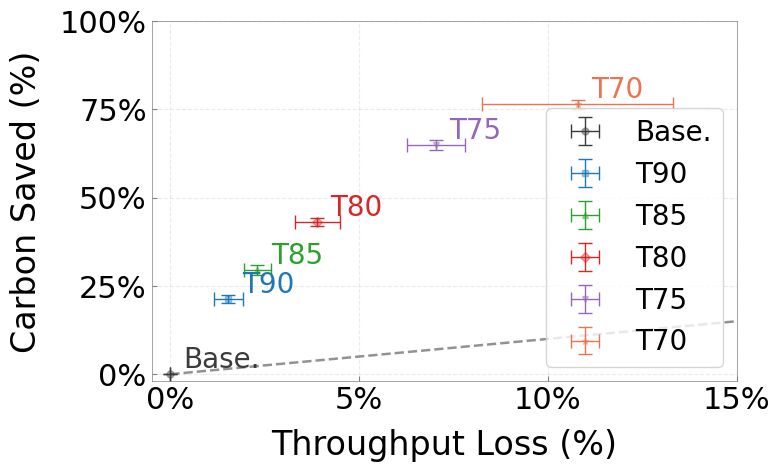

In [ ]:
# Plot: carbon savings versus data loss. Points above the diagonal are good tradeoffs.
fig, ax = plt.subplots(figsize=(7.5, 4.5))

xmax = max(15, float(np.ceil(tradeoff_df["data_loss_pct"].max() / 5) * 5))
ymax = 100
ax.plot([0, xmax], [0, xmax], color="#777777", linestyle="--", linewidth=1.8, alpha=0.8, label="1:1")

for _, row in tradeoff_df.iterrows():
    config = row["config"]
    label = "Base." if config == "baseline" else CONFIG_LABELS[config]
    x = row["data_loss_pct"]
    y = row["carbon_saved_pct"]
    xerr = 0 if pd.isna(row["data_pct_std"]) else row["data_pct_std"]
    yerr = 0 if pd.isna(row["carbon_pct_std"]) else row["carbon_pct_std"]

    plotline, caps, bars = ax.errorbar(
        x, y, xerr=xerr, yerr=yerr,
        fmt=CONFIG_MARKERS[config], markersize=5,
        color=CONFIG_COLORS[config], ecolor=CONFIG_COLORS[config],
        elinewidth=1.0, capsize=5, label=label,
    )
    ax.text(x + 0.35, y + 1.8, label, fontsize=20, color=CONFIG_COLORS[config])
    plotline.set_alpha(0.4) 


# Set transparency only for the error lines and caps

ax.set_xlim(-0.5, xmax)
ax.set_ylim(-2, ymax)
ax.set_xlabel("Loss in Data Transfer (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Carbon Saved (%)", fontsize=LABEL_SIZE, labelpad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.tick_params(axis="both", labelsize=FONT_SIZE)
format_axes(ax)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[1:], labels[1:], loc="lower right", frameon=True, fontsize=20)
fig.subplots_adjust(left=0.20, right=0.98, bottom=0.18, top=0.98)

out_path = FIGURES_DIR / "headline_carbon_saved_vs_data_loss.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/headline_carbon_per_gib.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/headline_carbon_per_gib.pdf


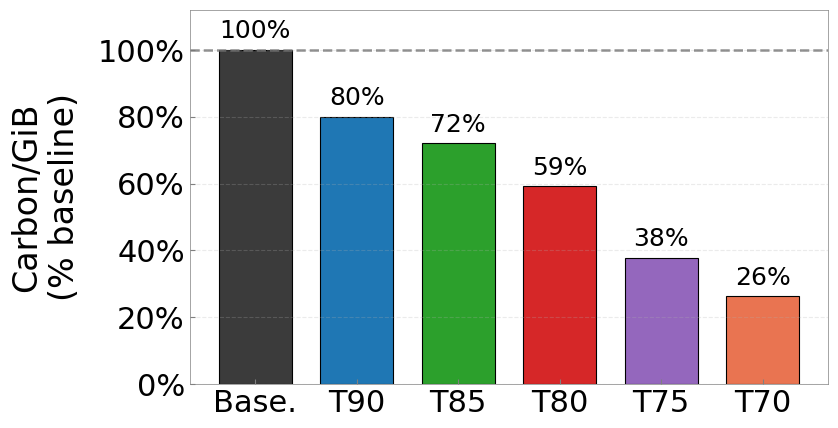

In [229]:
# Plot: carbon per GiB relative to baseline.
plot_df = tradeoff_df.copy()
plot_df["label"] = plot_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})

fig, ax = plt.subplots(figsize=(8.4, 4.8))
x = np.arange(len(plot_df))
colors = [CONFIG_COLORS[config] for config in plot_df["config"]]
bars = ax.bar(x, plot_df["carbon_per_gib_pct_baseline"], color=colors, edgecolor="black", linewidth=0.8, width=0.72)

for bar, val in zip(bars, plot_df["carbon_per_gib_pct_baseline"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 2, f"{val:.0f}%", ha="center", va="bottom", fontsize=18)

ax.axhline(100, color="#777777", linestyle="--", linewidth=1.8, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], fontsize=FONT_SIZE)
ax.set_ylim(0, 112)
ax.set_ylabel("Carbon/GiB\n(% baseline)", fontsize=LABEL_SIZE, labelpad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.tick_params(axis="y", labelsize=FONT_SIZE)
format_axes(ax)
fig.subplots_adjust(left=0.22, right=0.98, bottom=0.18, top=0.96)

out_path = FIGURES_DIR / "headline_carbon_per_gib.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/headline_tradeoff_summary_table.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/headline_tradeoff_summary_table.pdf


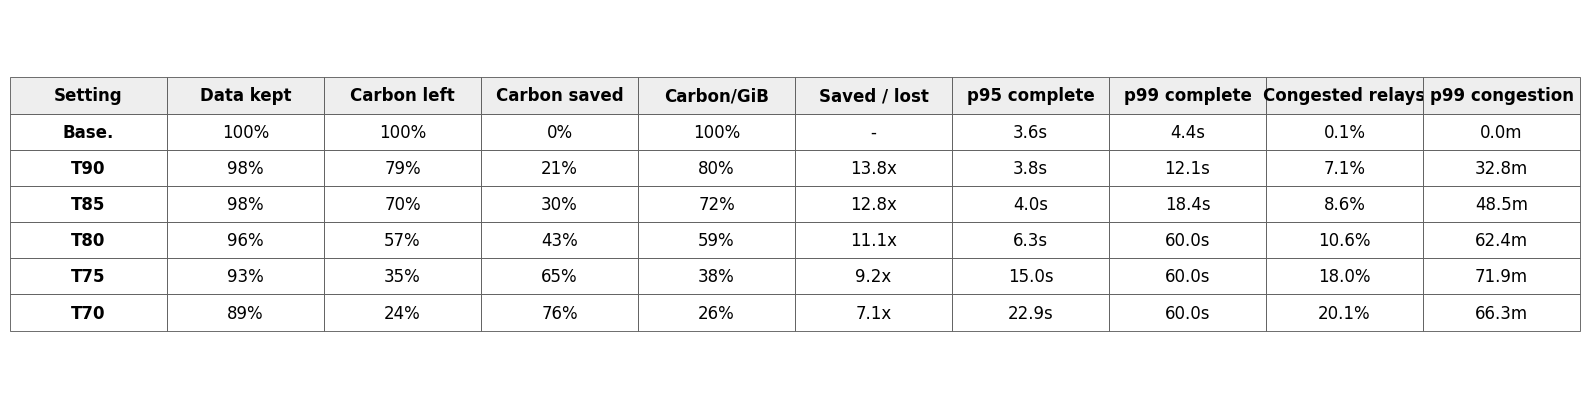

In [230]:
# Render the table as a figure for easy paper/slide reuse.
fig, ax = plt.subplots(figsize=(16, 4.2))
ax.axis("off")

table = ax.table(
    cellText=summary_display_df.values,
    colLabels=summary_display_df.columns,
    cellLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.0, 1.8)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#555555")
    cell.set_linewidth(0.6)
    if row == 0:
        cell.set_facecolor("#eeeeee")
        cell.set_text_props(weight="bold")
    elif col == 0:
        cell.set_text_props(weight="bold")

fig.tight_layout()
out_path = FIGURES_DIR / "headline_tradeoff_summary_table.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


## Country breakdown

In [231]:
# One row per country/network/config/hour.
country_hour_parts = []

for network in NETWORKS:
    for config in CONFIG_ORDER:
        config_dir = config_paths[network][config]
        hour_dirs = hour_dirs_for(network, config_dir)

        for hour_dir in hour_dirs:
            match = re.search(r"_Hour_(\d+)$", hour_dir.name)
            if not match:
                continue
            emissions_path = hour_dir / "cache_emissions.csv"
            if not emissions_path.exists():
                continue

            emissions = pd.read_csv(
                emissions_path,
                usecols=["country", "throughput", "carbon_emissions", "carbon_intensity"],
            )
            emissions["country"] = emissions["country"].fillna("Unknown").astype(str)

            country_hour = (
                emissions.groupby("country", as_index=False)
                .agg(
                    throughput_bytes=("throughput", "sum"),
                    carbon_emissions=("carbon_emissions", "sum"),
                    carbon_intensity=("carbon_intensity", "mean"),
                )
            )
            country_hour["network"] = network
            country_hour["config"] = config
            country_hour["config_label"] = CONFIG_LABELS[config]
            country_hour["hour"] = int(match.group(1))
            country_hour_parts.append(country_hour)

country_hour_df = pd.concat(country_hour_parts, ignore_index=True)
print(f"Country-hour rows: {len(country_hour_df):,}")
country_hour_df.head()


Country-hour rows: 28,049


,country,throughput_bytes,carbon_emissions,carbon_intensity,network,config,config_label,hour
0,AL,945440157,0.016730,15.0,n1,baseline,Baseline,0
1,AT,41116445980,6.187471,158.0,n1,baseline,Baseline,0
2,AU,8014684,0.073890,289.0,n1,baseline,Baseline,0
3,BD,305768212,0.205382,442.0,n1,baseline,Baseline,0
4,BE,20110417231,1.111052,63.0,n1,baseline,Baseline,0


In [232]:
# Daily country shares, with missing countries counted as zero for each network/config.
country_daily_raw = (
    country_hour_df.groupby(["network", "config", "config_label", "country"], as_index=False)
    .agg(
        throughput_bytes=("throughput_bytes", "sum"),
        carbon_emissions=("carbon_emissions", "sum"),
        carbon_intensity=("carbon_intensity", "mean"),
    )
)

all_countries = sorted(country_hour_df["country"].dropna().unique())
full_country_grid = pd.MultiIndex.from_product(
    [NETWORKS, CONFIG_ORDER, all_countries],
    names=["network", "config", "country"],
).to_frame(index=False)

country_ci = country_hour_df.groupby("country")["carbon_intensity"].mean()
country_daily_df = full_country_grid.merge(
    country_daily_raw,
    on=["network", "config", "country"],
    how="left",
)
country_daily_df["config_label"] = country_daily_df["config"].map(CONFIG_LABELS)
country_daily_df["throughput_bytes"] = country_daily_df["throughput_bytes"].fillna(0)
country_daily_df["carbon_emissions"] = country_daily_df["carbon_emissions"].fillna(0)
country_daily_df["carbon_intensity"] = country_daily_df["country"].map(country_ci)

country_daily_df["data_share"] = (
    country_daily_df["throughput_bytes"]
    / country_daily_df.groupby(["network", "config"])["throughput_bytes"].transform("sum")
    * 100
)
country_daily_df["carbon_share"] = (
    country_daily_df["carbon_emissions"]
    / country_daily_df.groupby(["network", "config"])["carbon_emissions"].transform("sum")
    * 100
)

country_avg_df = (
    country_daily_df.groupby(["config", "config_label", "country"], as_index=False)
    .agg(
        data_share=("data_share", "mean"),
        carbon_share=("carbon_share", "mean"),
        carbon_intensity=("carbon_intensity", "mean"),
    )
)
country_avg_df["carbon_minus_data_pp"] = country_avg_df["carbon_share"] - country_avg_df["data_share"]

country_config_totals_df = (
    country_daily_df.groupby(["network", "config", "config_label"], as_index=False)
    .agg(
        throughput_bytes=("throughput_bytes", "sum"),
        carbon_emissions=("carbon_emissions", "sum"),
    )
)
country_config_baseline_df = (
    country_config_totals_df[country_config_totals_df["config"] == "baseline"]
    [["network", "throughput_bytes", "carbon_emissions"]]
    .rename(columns={
        "throughput_bytes": "baseline_throughput_bytes",
        "carbon_emissions": "baseline_carbon_emissions",
    })
)
country_config_totals_df = country_config_totals_df.merge(country_config_baseline_df, on="network", how="left")
country_config_totals_df["throughput_pct_baseline"] = country_config_totals_df["throughput_bytes"] / country_config_totals_df["baseline_throughput_bytes"] * 100
country_config_totals_df["carbon_pct_baseline"] = country_config_totals_df["carbon_emissions"] / country_config_totals_df["baseline_carbon_emissions"] * 100

# Match the main time-series figure: average hourly network-normalized percentages.
country_total_summary_df = (
    time_series_df.groupby(["config", "config_label"], as_index=False)
    .agg(
        throughput_pct_baseline=("throughput_pct_baseline", "mean"),
        carbon_pct_baseline=("carbon_pct_baseline", "mean"),
    )
)

country_rank_df = (
    country_avg_df.groupby("country", as_index=False)
    .agg(
        max_carbon_share=("carbon_share", "max"),
        avg_carbon_share=("carbon_share", "mean"),
        carbon_intensity=("carbon_intensity", "mean"),
    )
)
baseline_carbon_share = (
    country_avg_df[country_avg_df["config"] == "baseline"]
    [["country", "carbon_share"]]
    .rename(columns={"carbon_share": "baseline_carbon_share"})
)
country_rank_df = country_rank_df.merge(baseline_carbon_share, on="country", how="left")
country_rank_df["baseline_carbon_share"] = country_rank_df["baseline_carbon_share"].fillna(0)

TOP_COUNTRIES = (
    country_rank_df.sort_values(["max_carbon_share", "baseline_carbon_share"], ascending=False)
    .head(9)["country"]
    .tolist()
)

palette = list(plt.get_cmap("tab20").colors)
COUNTRY_COLORS = {country: palette[i % len(palette)] for i, country in enumerate(TOP_COUNTRIES)}
COUNTRY_COLORS["Other"] = "#c9c9c9"
COUNTRY_HATCHES = {
    country: hatch
    for country, hatch in zip(TOP_COUNTRIES, ["/", "x", ".", "o", "+", "-", "**", "OO", "||"])
}
COUNTRY_HATCHES["Other"] = ""
COUNTRY_LABELS = {
    country: f"{country} ({country_ci.get(country, np.nan):.0f})"
    for country in TOP_COUNTRIES
}
COUNTRY_LABELS["Other"] = "Other"

print("Top countries shown:", TOP_COUNTRIES)
country_avg_df[country_avg_df["country"].isin(TOP_COUNTRIES)].head()


Top countries shown: ['DE', 'US', 'CA', 'FI', 'FR', 'LU', 'NL', 'PL', 'GB']


,config,config_label,country,data_share,carbon_share,carbon_intensity,carbon_minus_data_pp
8,a0.20-k0.10-q1,T90,CA,4.525670,2.850815,88.458333,-1.674855
13,a0.20-k0.10-q1,T90,DE,23.588663,27.555962,156.916667,3.967300
17,a0.20-k0.10-q1,T90,FI,5.818053,2.587522,64.375000,-3.230531
18,a0.20-k0.10-q1,T90,FR,11.761001,2.323295,29.087615,-9.437706
19,a0.20-k0.10-q1,T90,GB,2.902588,1.601208,88.958333,-1.301380


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/country_data_carbon_stacked_bar.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/country_data_carbon_stacked_bar.pdf
country            DE     US
config                      
baseline        34.97  13.87
a0.20-k0.10-q1  23.59   9.73
a0.30-k0.10-q1  19.35   8.28
a0.50-k0.10-q1  12.62   5.67
a1.0-k0.04-q1    9.87   0.01
a1.0-k0.10-q1    0.44   0.02
config
baseline          56.75
a0.20-k0.10-q1    52.15
a0.30-k0.10-q1    49.65
a0.50-k0.10-q1    43.46
a1.0-k0.04-q1     31.95
a1.0-k0.10-q1      7.77
Name: carbon_share, dtype: float64


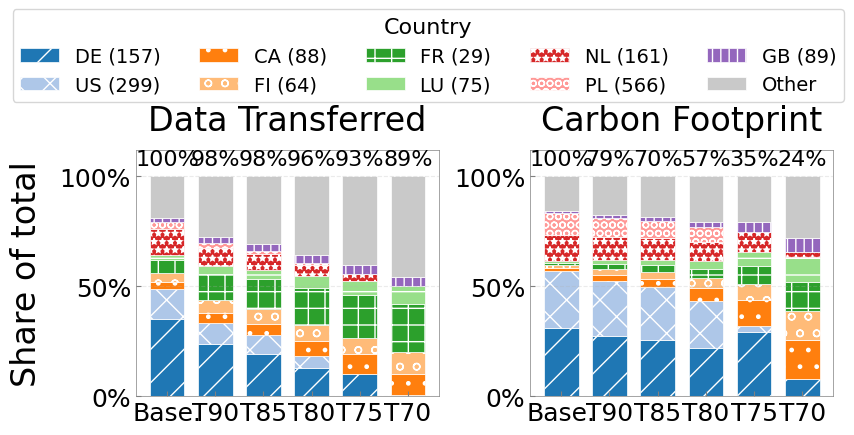

In [236]:
# Paired stacked bar: data composition vs carbon composition.
stacked_bar_labels = {**CONFIG_LABELS, "baseline": "Base."}
x = np.arange(len(CONFIG_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)

for ax, metric, title, total_col in [
    (axes[0], "data_share", "Data Transferred", "throughput_pct_baseline"),
    (axes[1], "carbon_share", "Carbon Footprint", "carbon_pct_baseline"),
]:
    bottoms = np.zeros(len(CONFIG_ORDER))

    for country in TOP_COUNTRIES:
        vals = (
            country_avg_df[country_avg_df["country"] == country]
            .set_index("config")
            .reindex(CONFIG_ORDER)[metric]
            .fillna(0)
            .to_numpy()
        )
        ax.bar(
            x, vals, bottom=bottoms, width=0.72,
            color=COUNTRY_COLORS[country], edgecolor="white", linewidth=0.5,
            hatch=COUNTRY_HATCHES[country],
            label=COUNTRY_LABELS[country],
        )
        bottoms += vals

    other_vals = np.maximum(0, 100 - bottoms)
    ax.bar(
        x, other_vals, bottom=bottoms, width=0.72,
        color=COUNTRY_COLORS["Other"], edgecolor="white", linewidth=0.5,
        label=COUNTRY_LABELS["Other"],
    )

    total_labels = (
        country_total_summary_df.set_index("config")
        .reindex(CONFIG_ORDER)[total_col]
        .round(0)
        .astype(int)
    )
    for i, pct in enumerate(total_labels):
        ax.text(i, 103, f"{pct}%", ha="center", va="bottom", fontsize=16)

    ax.set_title(title, fontsize=LABEL_SIZE, pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels([stacked_bar_labels[c] for c in CONFIG_ORDER], rotation=0, fontsize=18)
    ax.set_ylim(0, 112)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.tick_params(axis="y", labelsize=18)
    format_axes(ax)

axes[0].set_ylabel("Share of total", fontsize=LABEL_SIZE, labelpad=12)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(
    handles, labels, ncol=5, loc="upper center", bbox_to_anchor=(0.45, 1.35),
    frameon=True, fontsize=14, title="Country", title_fontsize=16,
)
#fig.text(0.5, -0.02, "Numbers above bars show total relative to baseline", ha="center", fontsize=16)
#fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(right=None, bottom=None, left=None, top=None, wspace=0.3, hspace=None)


out_path = FIGURES_DIR / "country_data_carbon_stacked_bar.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
traffic_share_de_us = (
    country_avg_df[country_avg_df["country"].isin(["DE", "US"])]
    .pivot(index="config", columns="country", values="data_share")
    .reindex(CONFIG_ORDER)
)
print(traffic_share_de_us.round(2))
# Combined carbon emissions share (US + Germany), by config.
carbon_share_de_us = (
    country_avg_df[country_avg_df["country"].isin(["DE", "US"])]
    .groupby("config")["carbon_share"]
    .sum()
    .reindex(CONFIG_ORDER)
)
print(carbon_share_de_us.round(2))
plt.show()


In [237]:
# Traffic share change for T70 vs baseline.
countries_of_interest = ["PL", "DE", "NL", "FR", "CA", "CH"]

t70_vs_baseline = (
    country_avg_df[country_avg_df["country"].isin(countries_of_interest)]
    .pivot_table(index="country", columns="config_label", values="data_share")
    .reindex(countries_of_interest)[["Baseline", "T70"]]
)
t70_vs_baseline["change_pp"] = t70_vs_baseline["T70"] - t70_vs_baseline["Baseline"]
t70_vs_baseline["pct_change_relative"] = (
    (t70_vs_baseline["T70"] - t70_vs_baseline["Baseline"]) / t70_vs_baseline["Baseline"] * 100
)

print(t70_vs_baseline.round(2))

print("\nReduction (Poland, Germany, Netherlands):")
print(t70_vs_baseline.loc[["PL", "DE", "NL"], ["change_pp", "pct_change_relative"]].round(2))

print("\nIncrease (France, Canada, Switzerland):")
print(t70_vs_baseline.loc[["FR", "CA", "CH"], ["change_pp", "pct_change_relative"]].round(2))

config_label  Baseline    T70  change_pp  pct_change_relative
country                                                      
PL                3.11   0.00      -3.11              -100.00
DE               34.97   0.44     -34.53               -98.73
NL               12.08   0.26     -11.83               -97.89
FR                6.05  22.14      16.09               266.00
CA                3.02   9.61       6.59               218.61
CH                2.97  11.12       8.16               274.91

Reduction (Poland, Germany, Netherlands):
config_label  change_pp  pct_change_relative
country                                     
PL                -3.11              -100.00
DE               -34.53               -98.73
NL               -11.83               -97.89

Increase (France, Canada, Switzerland):
config_label  change_pp  pct_change_relative
country                                     
FR                16.09               266.00
CA                 6.59               218.61
CH             

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/country_carbon_inefficiency_heatmap.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/country_carbon_inefficiency_heatmap.pdf


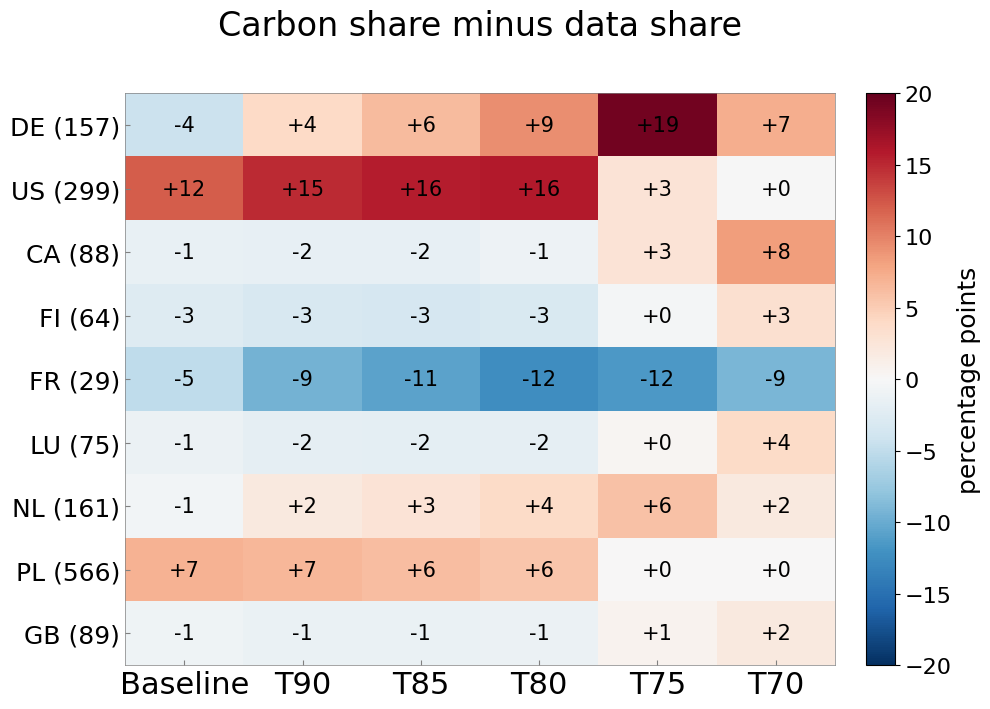

In [238]:
# Heatmap: which countries create more carbon share than data share?
from matplotlib.colors import TwoSlopeNorm

heatmap_df = (
    country_avg_df[country_avg_df["country"].isin(TOP_COUNTRIES)]
    .pivot(index="country", columns="config", values="carbon_minus_data_pp")
    .reindex(TOP_COUNTRIES)
    .reindex(columns=CONFIG_ORDER)
)
row_labels = [COUNTRY_LABELS[country] for country in heatmap_df.index]
col_labels = [CONFIG_LABELS[config] for config in heatmap_df.columns]

limit = np.nanmax(np.abs(heatmap_df.to_numpy()))
limit = max(5, float(np.ceil(limit / 5) * 5))

fig, ax = plt.subplots(figsize=(10, 7.2))
im = ax.imshow(
    heatmap_df.to_numpy(), cmap="RdBu_r", aspect="auto",
    norm=TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit),
)

ax.set_xticks(np.arange(len(col_labels)))
ax.set_xticklabels(col_labels, fontsize=FONT_SIZE)
ax.set_yticks(np.arange(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=18)
ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        display_val = 0 if abs(val) < 0.5 else val
        ax.text(j, i, f"{display_val:+.0f}", ha="center", va="center", fontsize=15, color="black")

ax.set_title("Carbon share minus data share", fontsize=LABEL_SIZE, pad=42)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("percentage points", fontsize=18)
cbar.ax.tick_params(labelsize=16)
format_axes(ax)
fig.tight_layout()

out_path = FIGURES_DIR / "country_carbon_inefficiency_heatmap.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/country_data_vs_carbon_scatter.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/country_data_vs_carbon_scatter.pdf


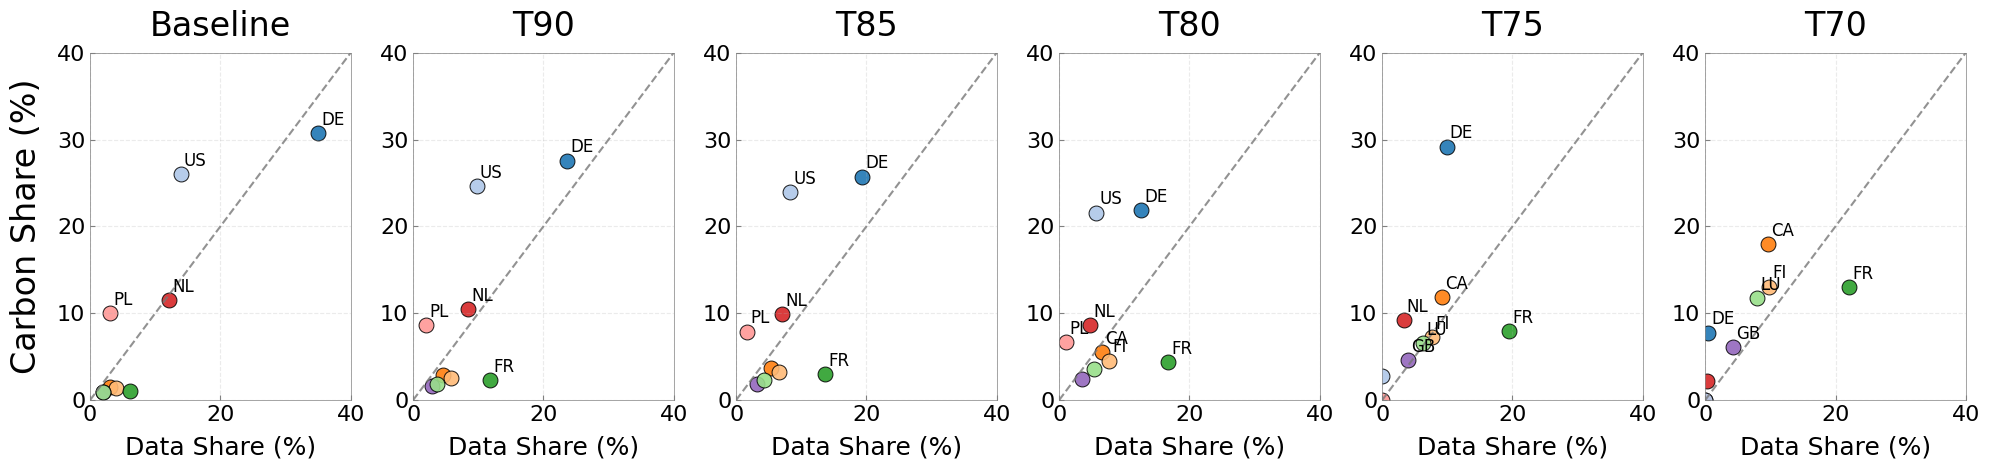

In [239]:
# Scatter: countries above the diagonal produce more carbon than their traffic share.
scatter_df = country_avg_df[country_avg_df["country"].isin(TOP_COUNTRIES)].copy()
axis_max = np.nanmax(scatter_df[["data_share", "carbon_share"]].to_numpy())
axis_max = max(25, float(np.ceil(axis_max / 10) * 10))

fig, axes = plt.subplots(1, len(CONFIG_ORDER), figsize=(20, 4.8), sharex=True, sharey=True)

for ax, config in zip(axes, CONFIG_ORDER):
    sub = scatter_df[scatter_df["config"] == config].copy()
    ax.plot([0, axis_max], [0, axis_max], color="#777777", linestyle="--", linewidth=1.5, alpha=0.8)

    for _, row in sub.iterrows():
        country = row["country"]
        ax.scatter(
            row["data_share"], row["carbon_share"],
            s=115, color=COUNTRY_COLORS[country], edgecolor="black", linewidth=0.7, alpha=0.9,
        )
        if row["carbon_share"] >= 4 or row["data_share"] >= 8:
            ax.text(
                row["data_share"] + 0.5, row["carbon_share"] + 0.5,
                country, fontsize=12, ha="left", va="bottom",
            )

    ax.set_title(CONFIG_LABELS[config], fontsize=LABEL_SIZE, pad=12)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=16)
    format_axes(ax)

axes[0].set_ylabel("Carbon Share (%)", fontsize=LABEL_SIZE, labelpad=10)
for ax in axes:
    ax.set_xlabel("Data Share (%)", fontsize=18, labelpad=8)

fig.tight_layout()
out_path = FIGURES_DIR / "country_data_vs_carbon_scatter.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


In [240]:
# Same calculation, collapsed across the day.
daily_relative_df = (
    relative_df.groupby(["network", "config", "config_label"], as_index=False)
    .agg(
        throughput_bytes=("throughput_bytes", "sum"),
        carbon_emissions=("carbon_emissions", "sum"),
        hours=("hour", "nunique"),
    )
)

daily_baseline = (
    daily_relative_df[daily_relative_df["config"] == "baseline"]
    [["network", "throughput_bytes", "carbon_emissions"]]
    .rename(columns={
        "throughput_bytes": "baseline_throughput_bytes",
        "carbon_emissions": "baseline_carbon_emissions",
    })
)

daily_relative_df = daily_relative_df.merge(daily_baseline, on="network", how="left")
daily_relative_df["throughput_pct_baseline"] = daily_relative_df["throughput_bytes"] / daily_relative_df["baseline_throughput_bytes"] * 100
daily_relative_df["carbon_pct_baseline"] = daily_relative_df["carbon_emissions"] / daily_relative_df["baseline_carbon_emissions"] * 100

daily_summary_df = (
    daily_relative_df.groupby(["config", "config_label"], as_index=False)
    .agg(
        networks=("network", "nunique"),
        hours_min=("hours", "min"),
        throughput_pct_baseline=("throughput_pct_baseline", "mean"),
        carbon_pct_baseline=("carbon_pct_baseline", "mean"),
    )
)

daily_summary_df

,config,config_label,networks,hours_min,throughput_pct_baseline,carbon_pct_baseline
0,a0.20-k0.10-q1,T90,5,24,98.471871,78.689368
1,a0.30-k0.10-q1,T85,5,24,97.704991,70.410669
2,a0.50-k0.10-q1,T80,5,24,96.128827,56.716199
3,a1.0-k0.04-q1,T75,5,24,92.852523,34.388345
4,a1.0-k0.10-q1,T70,5,24,88.963663,22.980501
5,baseline,Baseline,5,24,100.000000,100.000000


In [241]:
# Useful to spot partial runs before interpreting the averages.
missing_hours = (
    master_df.groupby(["network", "config"], as_index=False)["hour"]
    .agg(lambda s: sorted(set(range(24)) - set(s)))
    .rename(columns={"hour": "missing_hours"})
)

missing_hours[missing_hours["missing_hours"].map(len) > 0]

,network,config,missing_hours


## Extra checks

These are the extra checks I would use when writing the results story.


In [242]:
# Decompose carbon savings into traffic loss vs cleaner routing.
decomposition_df = tradeoff_df.copy()
decomposition_df["label"] = decomposition_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})
decomposition_df["traffic_loss_component"] = 100 - decomposition_df["data_pct_baseline"]
decomposition_df["cleaner_routing_component"] = decomposition_df["data_pct_baseline"] - decomposition_df["carbon_pct_baseline"]
decomposition_df["traffic_loss_component"] = decomposition_df["traffic_loss_component"].clip(lower=0)
decomposition_df["cleaner_routing_component"] = decomposition_df["cleaner_routing_component"].clip(lower=0)
decomposition_df["routing_share_of_savings"] = (
    decomposition_df["cleaner_routing_component"] / decomposition_df["carbon_saved_pct"] * 100
).replace([np.inf, -np.inf], np.nan)

decomposition_display_df = pd.DataFrame({
    "Setting": decomposition_df["label"],
    "Total carbon saved": decomposition_df["carbon_saved_pct"].map(lambda v: f"{v:.0f}%"),
    "From less traffic": decomposition_df["traffic_loss_component"].map(lambda v: f"{v:.0f}%"),
    "From cleaner routing": decomposition_df["cleaner_routing_component"].map(lambda v: f"{v:.0f}%"),
    "Cleaner-routing share": decomposition_df["routing_share_of_savings"].map(lambda v: "-" if pd.isna(v) else f"{v:.0f}%"),
})

decomposition_csv_path = FIGURES_DIR / "carbon_savings_decomposition.csv"
decomposition_display_df.to_csv(decomposition_csv_path, index=False)
print(decomposition_csv_path)
decomposition_display_df


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/carbon_savings_decomposition.csv


,Setting,Total carbon saved,From less traffic,From cleaner routing,Cleaner-routing share
5,Base.,0%,0%,0%,-
0,T90,21%,2%,20%,93%
1,T85,30%,2%,27%,92%
2,T80,43%,4%,39%,91%
3,T75,65%,7%,58%,89%
4,T70,76%,11%,66%,86%


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/carbon_savings_decomposition.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/carbon_savings_decomposition.pdf


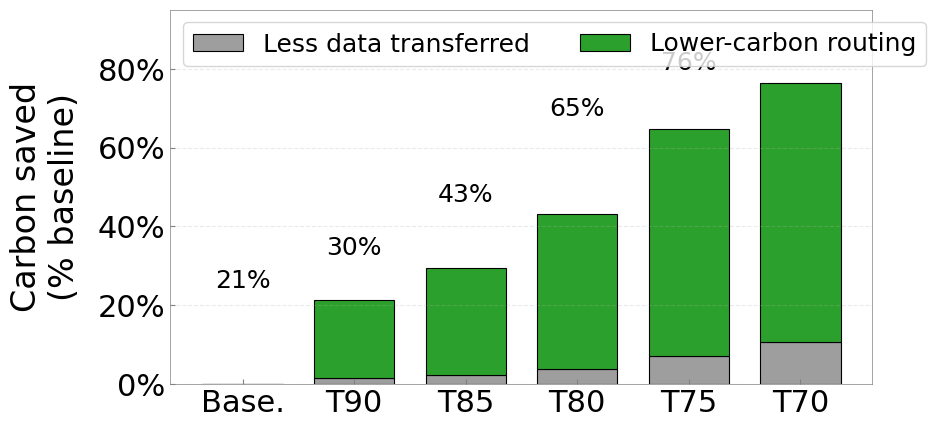

In [243]:
# Plot: most of the carbon reduction comes from lower-carbon routing, not just lost traffic.
# This is not a very useful figure
plot_df = decomposition_df.copy()
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(9.0, 4.8))
traffic_bars = ax.bar(
    x, plot_df["traffic_loss_component"], width=0.72,
    color="#9E9E9E", edgecolor="black", linewidth=0.8,
    label="Less data transferred",
)
routing_bars = ax.bar(
    x, plot_df["cleaner_routing_component"], width=0.72,
    bottom=plot_df["traffic_loss_component"],
    color="#2CA02C", edgecolor="black", linewidth=0.8,
    label="Lower-carbon routing",
)

for i, row in plot_df.iterrows():
    total = row["carbon_saved_pct"]
    if total > 0:
        ax.text(i, total + 2, f"{total:.0f}%", ha="center", va="bottom", fontsize=18)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["label"], fontsize=FONT_SIZE)
ax.set_ylim(0, 95)
ax.set_ylabel("Carbon saved\n(% baseline)", fontsize=LABEL_SIZE, labelpad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.tick_params(axis="y", labelsize=FONT_SIZE)
ax.legend(ncol=2, loc="upper left", frameon=True, fontsize=18)
format_axes(ax)
fig.subplots_adjust(left=0.20, right=0.98, bottom=0.18, top=0.96)

out_path = FIGURES_DIR / "carbon_savings_decomposition.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


In [244]:
# What setting would we pick under simple data-retention budgets?
budget_rows = []
for min_data_kept in [99, 97.5, 97, 95, 92, 90]:
    candidates = summary_table_df[summary_table_df["data_pct_baseline"] >= min_data_kept].copy()
    if candidates.empty:
        continue
    best = candidates.sort_values(["carbon_saved_pct", "data_pct_baseline"], ascending=[False, False]).iloc[0]
    budget_rows.append({
        "min_data_kept_pct": min_data_kept,
        "config": best["config"],
        "setting": "Base." if best["config"] == "baseline" else CONFIG_LABELS[best["config"]],
        "data_pct_baseline": best["data_pct_baseline"],
        "carbon_saved_pct": best["carbon_saved_pct"],
        "carbon_per_gib_pct_baseline": best["carbon_per_gib_pct_baseline"],
        "completion_p95_s": best["completion_p95_s"],
        "congested_pct": best["congested_pct"],
    })

budget_df = pd.DataFrame(budget_rows)
budget_display_df = pd.DataFrame({
    "Data floor": budget_df["min_data_kept_pct"].map(lambda v: f"{v:g}%"),
    "Pick": budget_df["setting"],
    "Data kept": budget_df["data_pct_baseline"].map(lambda v: f"{v:.1f}%"),
    "Carbon saved": budget_df["carbon_saved_pct"].map(lambda v: f"{v:.1f}%"),
    "Carbon/GiB": budget_df["carbon_per_gib_pct_baseline"].map(lambda v: f"{v:.1f}%"),
    "p95 done": budget_df["completion_p95_s"].map(lambda v: f"{v:.1f}s"),
    "Congested": budget_df["congested_pct"].map(lambda v: f"{v:.1f}%"),
})

budget_csv_path = FIGURES_DIR / "performance_budget_choices.csv"
budget_display_df.to_csv(budget_csv_path, index=False)
print(budget_csv_path)
budget_display_df


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/performance_budget_choices.csv


,Data floor,Pick,Data kept,Carbon saved,Carbon/GiB,p95 done,Congested
0,99%,Base.,100.0%,0.0%,100.0%,3.6s,0.1%
1,97.5%,T85,97.7%,29.5%,72.1%,4.0s,8.6%
2,97%,T85,97.7%,29.5%,72.1%,4.0s,8.6%
3,95%,T80,96.1%,43.1%,59.2%,6.3s,10.6%
4,92%,T75,93.0%,64.8%,37.9%,15.0s,18.0%
5,90%,T75,93.0%,64.8%,37.9%,15.0s,18.0%


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/performance_budget_choices_table.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/performance_budget_choices_table.pdf


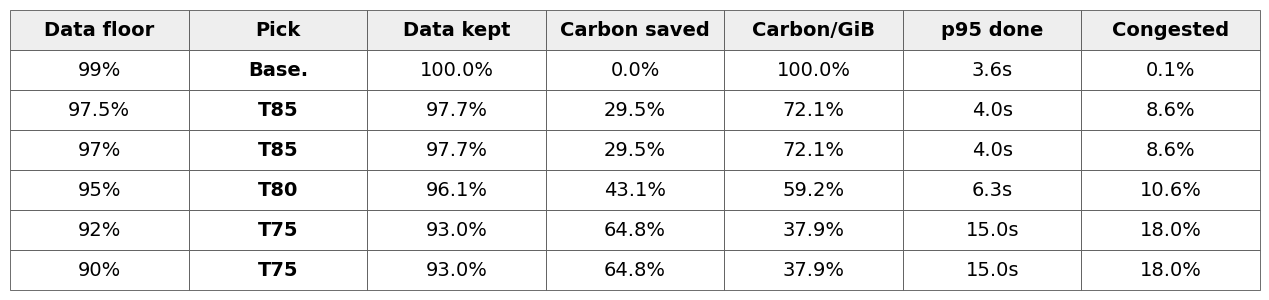

In [245]:
# Render the budget table for quick reuse.
fig, ax = plt.subplots(figsize=(12.8, 3.1))
ax.axis("off")

table = ax.table(
    cellText=budget_display_df.values,
    colLabels=budget_display_df.columns,
    cellLoc="center",
    loc="center",
    bbox=[0, 0, 1, 1],
)
table.auto_set_font_size(False)
table.set_fontsize(14)
# bbox fixes the footprint; scaling tends to push cells outside the axes.

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#555555")
    cell.set_linewidth(0.6)
    if row == 0:
        cell.set_facecolor("#eeeeee")
        cell.set_text_props(weight="bold")
    elif col == 1:
        cell.set_text_props(weight="bold")

fig.tight_layout()
out_path = FIGURES_DIR / "performance_budget_choices_table.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


In [246]:
# Per-network endpoint values: this checks whether the average hides one dominant network.
network_endpoint_df = tradeoff_network_df.copy()
network_endpoint_df["network_label"] = network_endpoint_df["network"].str.upper()
network_endpoint_df["label"] = network_endpoint_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})
network_endpoint_df["data_loss_pct"] = 100 - network_endpoint_df["data_pct_baseline"]
network_endpoint_df["carbon_saved_pct"] = 100 - network_endpoint_df["carbon_pct_baseline"]

network_endpoint_display_df = network_endpoint_df.sort_values(["network", "config"]).copy()
network_endpoint_display_df.head()


,network,config,config_label,data_pct_baseline,carbon_pct_baseline,hours,network_label,label,data_loss_pct,carbon_saved_pct
0,n1,a0.20-k0.10-q1,T90,98.653315,78.749124,24,N1,T90,1.346685,21.250876
1,n1,a0.30-k0.10-q1,T85,97.892363,70.592839,24,N1,T85,2.107637,29.407161
2,n1,a0.50-k0.10-q1,T80,96.385507,57.373173,24,N1,T80,3.614493,42.626827
3,n1,a1.0-k0.04-q1,T75,92.805783,36.414621,24,N1,T75,7.194217,63.585379
4,n1,a1.0-k0.10-q1,T70,88.161580,24.275486,24,N1,T70,11.838420,75.724514


In [ ]:
# Plot: per-network robustness of the data/carbon tradeoff.
heatmap_metric_specs = [
    ("data_pct_baseline", "Data Transferred", "Greens", 90, 100),
    ("carbon_pct_baseline", "Carbon Footprint", "YlOrRd", 0, 100),
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharey=True)

for ax, (metric, title, cmap, vmin, vmax) in zip(axes, heatmap_metric_specs):
    matrix = (
        network_endpoint_df.pivot(index="network_label", columns="config", values=metric)
        .reindex([n.upper() for n in NETWORKS])
        .reindex(columns=CONFIG_ORDER)
    )
    im = ax.imshow(matrix.to_numpy(), cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=LABEL_SIZE, pad=12)
    ax.set_xticks(np.arange(len(CONFIG_ORDER)))
    ax.set_xticklabels(["Base.", "T90", "T85", "T80", "T75"], fontsize=18)
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=FONT_SIZE)
    ax.tick_params(axis="both", length=0)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.iloc[i, j]
            ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=17, color="black")

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
    cbar.ax.tick_params(labelsize=14)

fig.tight_layout()
out_path = FIGURES_DIR / "per_network_tradeoff_heatmap.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


In [247]:
# Marginal effect of each more aggressive setting.
ordered_tradeoff_df = tradeoff_df.set_index("config").reindex(CONFIG_ORDER).reset_index()
ordered_tradeoff_df["label"] = ordered_tradeoff_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})

marginal_rows = []
for i in range(1, len(ordered_tradeoff_df)):
    prev = ordered_tradeoff_df.iloc[i - 1]
    cur = ordered_tradeoff_df.iloc[i]
    extra_data_lost = prev["data_pct_baseline"] - cur["data_pct_baseline"]
    extra_carbon_saved = prev["carbon_pct_baseline"] - cur["carbon_pct_baseline"]
    marginal_rows.append({
        "step": f"{prev['label']} to {cur['label']}",
        "config": cur["config"],
        "extra_data_lost_pct": extra_data_lost,
        "extra_carbon_saved_pct": extra_carbon_saved,
        "marginal_saved_per_lost": extra_carbon_saved / extra_data_lost if extra_data_lost > 0 else np.nan,
    })

marginal_df = pd.DataFrame(marginal_rows)
marginal_display_df = pd.DataFrame({
    "Move": marginal_df["step"],
    "Extra data lost": marginal_df["extra_data_lost_pct"].map(lambda v: f"{v:.1f}%"),
    "Extra carbon saved": marginal_df["extra_carbon_saved_pct"].map(lambda v: f"{v:.1f}%"),
    "Extra saved / lost": marginal_df["marginal_saved_per_lost"].map(lambda v: "-" if pd.isna(v) else f"{v:.1f}x"),
})

marginal_csv_path = FIGURES_DIR / "marginal_tradeoff_steps.csv"
marginal_display_df.to_csv(marginal_csv_path, index=False)
print(marginal_csv_path)
marginal_display_df


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/marginal_tradeoff_steps.csv


,Move,Extra data lost,Extra carbon saved,Extra saved / lost
0,Base. to T90,1.5%,21.3%,13.8x
1,T90 to T85,0.8%,8.3%,10.7x
2,T85 to T80,1.6%,13.6%,8.6x
3,T80 to T75,3.2%,21.7%,6.9x
4,T75 to T70,3.8%,11.7%,3.1x


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/marginal_tradeoff_steps.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/marginal_tradeoff_steps.pdf


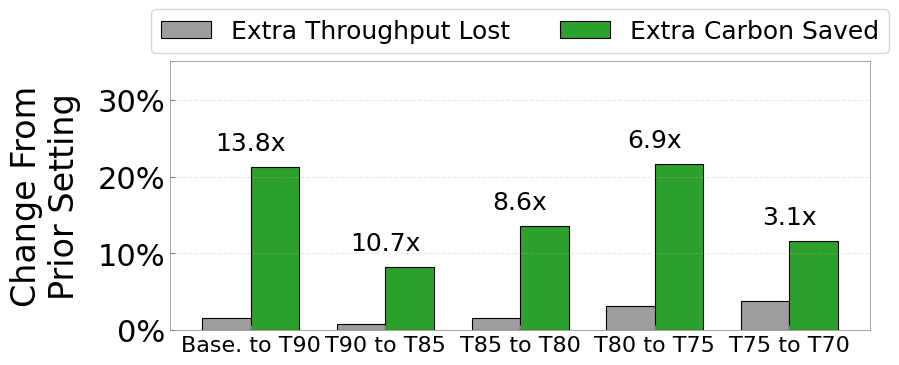

In [248]:
# Plot: the stepwise tradeoff makes the elbow visible.
plot_df = marginal_df.copy()
x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.bar(
    x - width / 2, plot_df["extra_data_lost_pct"], width=width,
    color="#9E9E9E", edgecolor="black", linewidth=0.8,
    label="Extra Throughput Lost",
)
ax.bar(
    x + width / 2, plot_df["extra_carbon_saved_pct"], width=width,
    color="#2CA02C", edgecolor="black", linewidth=0.8,
    label="Extra Carbon Saved",
)

for i, row in plot_df.iterrows():
    ratio = row["marginal_saved_per_lost"]
    if not pd.isna(ratio):
        ymax = max(row["extra_data_lost_pct"], row["extra_carbon_saved_pct"])
        ax.text(i, ymax + 1.5, f"{ratio:.1f}x", ha="center", va="bottom", fontsize=18)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["step"], fontsize=16)
ax.set_ylabel("Change From\nPrior Setting", fontsize=LABEL_SIZE, labelpad=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_ylim(0, max(35, plot_df[["extra_data_lost_pct", "extra_carbon_saved_pct"]].max().max() + 8))
ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.tick_params(axis="y", labelsize=FONT_SIZE)
ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.24), frameon=True, fontsize=18)
format_axes(ax)
fig.subplots_adjust(left=0.22, right=0.98, bottom=0.22, top=0.78)

out_path = FIGURES_DIR / "marginal_tradeoff_steps.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


In [249]:
# Top over-represented carbon countries in each setting.
country_excess_rows = []
for config in CONFIG_ORDER:
    sub = country_avg_df[country_avg_df["config"] == config].copy()
    sub = sub[sub["carbon_minus_data_pp"] > 0].sort_values("carbon_minus_data_pp", ascending=False)
    top = sub.head(3)
    country_excess_rows.append({
        "config": config,
        "setting": "Base." if config == "baseline" else CONFIG_LABELS[config],
        "top_countries": ", ".join(
            f"{row.country} (+{row.carbon_minus_data_pp:.1f} pp)" for row in top.itertuples()
        ),
        "top3_data_share": top["data_share"].sum(),
        "top3_carbon_share": top["carbon_share"].sum(),
        "top3_excess_pp": top["carbon_minus_data_pp"].sum(),
    })

country_excess_df = pd.DataFrame(country_excess_rows)
country_excess_display_df = pd.DataFrame({
    "Setting": country_excess_df["setting"],
    "Top carbon-heavy countries": country_excess_df["top_countries"],
    "Top-3 data share": country_excess_df["top3_data_share"].map(lambda v: f"{v:.1f}%"),
    "Top-3 carbon share": country_excess_df["top3_carbon_share"].map(lambda v: f"{v:.1f}%"),
    "Top-3 excess": country_excess_df["top3_excess_pp"].map(lambda v: f"{v:.1f} pp"),
})

country_excess_csv_path = FIGURES_DIR / "country_top_carbon_excess.csv"
country_excess_display_df.to_csv(country_excess_csv_path, index=False)
print(country_excess_csv_path)
country_excess_display_df


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/country_top_carbon_excess.csv


,Setting,Top carbon-heavy countries,Top-3 data share,Top-3 carbon share,Top-3 excess
0,Base.,"US (+12.1 pp), PL (+6.9 pp), CZ (+0.9 pp)",17.7%,37.6%,20.0 pp
1,T90,"US (+14.9 pp), PL (+6.6 pp), DE (+4.0 pp)",35.4%,60.7%,25.4 pp
2,T85,"US (+15.6 pp), DE (+6.4 pp), PL (+6.2 pp)",29.3%,57.5%,28.3 pp
3,T80,"US (+15.9 pp), DE (+9.3 pp), PL (+5.6 pp)",19.3%,50.1%,30.8 pp
4,T75,"DE (+19.3 pp), NL (+5.9 pp), US (+2.8 pp)",13.2%,41.1%,28.0 pp
5,T70,"CA (+8.3 pp), DE (+7.3 pp), LU (+3.8 pp)",18.0%,37.4%,19.5 pp


In [250]:
# Germany's traffic share and carbon share, by config.
germany_df = (
    country_avg_df[country_avg_df["country"] == "DE"]
    .set_index("config")
    .reindex(CONFIG_ORDER)[["data_share", "carbon_share"]]
)
germany_df["setting"] = [("Base." if c == "baseline" else CONFIG_LABELS[c]) for c in CONFIG_ORDER]
germany_df = germany_df[["setting", "data_share", "carbon_share"]]

print(germany_df.round(2))

               setting  data_share  carbon_share
config                                          
baseline         Base.       34.97         30.75
a0.20-k0.10-q1     T90       23.59         27.56
a0.30-k0.10-q1     T85       19.35         25.73
a0.50-k0.10-q1     T80       12.62         21.89
a1.0-k0.04-q1      T75        9.87         29.17
a1.0-k0.10-q1      T70        0.44          7.77


In [251]:
# Traffic share carried by the top-3 highest-traffic countries, per config.
top3_traffic_rows = []
for config in CONFIG_ORDER:
    sub = country_avg_df[country_avg_df["config"] == config].sort_values("data_share", ascending=False)
    top = sub.head(3)
    top3_traffic_rows.append({
        "config": config,
        "setting": "Base." if config == "baseline" else CONFIG_LABELS[config],
        "top3_countries": ", ".join(f"{row.country} ({row.data_share:.1f}%)" for row in top.itertuples()),
        "top3_traffic_share": top["data_share"].sum(),
    })

top3_traffic_df = pd.DataFrame(top3_traffic_rows)
top3_traffic_df["top3_traffic_share"] = top3_traffic_df["top3_traffic_share"].round(1)
print(top3_traffic_df[["setting", "top3_countries", "top3_traffic_share"]])

  setting                      top3_countries  top3_traffic_share
0   Base.  DE (35.0%), US (13.9%), NL (12.1%)                60.9
1     T90   DE (23.6%), FR (11.8%), US (9.7%)                45.1
2     T85   DE (19.3%), FR (13.7%), US (8.3%)                41.3
3     T80   FR (16.7%), DE (12.6%), SE (8.4%)                37.8
4     T75   FR (19.5%), SE (10.4%), DE (9.9%)                39.8
5     T70  FR (22.1%), SE (11.8%), CH (11.1%)                45.1


## Reliability, concentration, and dirty-grid traffic

In [252]:
# Load relay-hour rows and circuit failure counts.
relay_hour_parts = []
failure_hour_rows = []
relay_columns = [
    "relay", "country", "circuit_count", "circuits_built", "throughput",
    "bandwidth_per_circuit", "old_bw_weight", "new_bw_weight",
    "carbon_intensity", "error_count", "bw_rate",
    "write_congested_s", "read_congested_s", "carbon_emissions",
]

for network in NETWORKS:
    for config in CONFIG_ORDER:
        config_dir = config_paths[network][config]
        hour_dirs = hour_dirs_for(network, config_dir)

        for hour_dir in hour_dirs:
            match = re.search(r"_Hour_(\d+)$", hour_dir.name)
            if not match:
                continue
            hour = int(match.group(1))

            emissions_path = hour_dir / "cache_emissions.csv"
            if emissions_path.exists():
                available_cols = pd.read_csv(emissions_path, nrows=0).columns
                usecols = [col for col in relay_columns if col in available_cols]
                relay_hour = pd.read_csv(emissions_path, usecols=usecols)
                for col in relay_columns:
                    if col not in relay_hour.columns:
                        relay_hour[col] = np.nan
                relay_hour["country"] = relay_hour["country"].fillna("Unknown").astype(str)
                relay_hour["network"] = network
                relay_hour["config"] = config
                relay_hour["config_label"] = CONFIG_LABELS[config]
                relay_hour["hour"] = hour
                relay_hour_parts.append(relay_hour)

            failures_path = hour_dir / "cache_circuit_failures.json"
            if failures_path.exists():
                failures = json.loads(failures_path.read_text())
                row = {
                    "network": network,
                    "config": config,
                    "config_label": CONFIG_LABELS[config],
                    "hour": hour,
                    "failure_count": sum(failures.values()),
                }
                for reason, count in failures.items():
                    row[f"failure_{reason.lower()}"] = count
                failure_hour_rows.append(row)

relay_hour_df = pd.concat(relay_hour_parts, ignore_index=True)
for col in [
    "circuit_count", "circuits_built", "throughput", "bandwidth_per_circuit",
    "old_bw_weight", "new_bw_weight", "carbon_intensity", "error_count",
    "bw_rate", "write_congested_s", "read_congested_s", "carbon_emissions",
]:
    relay_hour_df[col] = pd.to_numeric(relay_hour_df[col], errors="coerce").fillna(0)

failure_hour_df = pd.DataFrame(failure_hour_rows).fillna(0)
print(f"Relay-hour rows: {len(relay_hour_df):,}")
print(f"Failure-hour rows: {len(failure_hour_df):,}")
relay_hour_df.head()


Relay-hour rows: 403,591
Failure-hour rows: 720


,relay,country,circuit_count,circuits_built,throughput,bandwidth_per_circuit,old_bw_weight,new_bw_weight,carbon_intensity,error_count,bw_rate,write_congested_s,read_congested_s,carbon_emissions,network,config,config_label,hour
0,relay100exit,NL,2157,155,5202372545,2411855,32480,32480,143,35,1.073742e+09,0.0,0.0,0.688834,n1,baseline,Baseline,0
1,relay101exit,NL,2147,124,5835355606,2717911,31782,31782,143,6,1.048576e+08,0.0,0.0,0.752862,n1,baseline,Baseline,0
2,relay102exit,NL,2092,120,5471140711,2615268,31468,31468,143,1,1.073742e+09,0.0,0.0,0.719732,n1,baseline,Baseline,0
3,relay103exit,NL,2108,110,5492016729,2605321,30961,30961,143,0,1.048576e+08,0.0,0.0,0.693382,n1,baseline,Baseline,0
4,relay104exit,AT,2032,151,5547267400,2729954,30609,30609,158,12,1.073742e+09,0.0,0.0,0.780018,n1,baseline,Baseline,0


In [253]:
# Circuit reliability summary.
reliability_hour_df = (
    relay_hour_df.groupby(["network", "config", "config_label", "hour"], as_index=False)
    .agg(
        circuits_built=("circuits_built", "sum"),
        relay_error_count=("error_count", "sum"),
        throughput_bytes=("throughput", "sum"),
        carbon_emissions=("carbon_emissions", "sum"),
    )
)

reliability_hour_df = reliability_hour_df.merge(
    failure_hour_df.drop(columns="config_label", errors="ignore"),
    on=["network", "config", "hour"],
    how="left",
)
for col in reliability_hour_df.columns:
    if col.startswith("failure_") or col == "failure_count":
        reliability_hour_df[col] = reliability_hour_df[col].fillna(0)

failure_reason_cols = [col for col in reliability_hour_df.columns if col.startswith("failure_") and col != "failure_count"]
reliability_network_df = (
    reliability_hour_df.groupby(["network", "config", "config_label"], as_index=False)
    .agg(
        hours=("hour", "nunique"),
        circuits_built=("circuits_built", "sum"),
        relay_error_count=("relay_error_count", "sum"),
        failure_count=("failure_count", "sum"),
        **{col: (col, "sum") for col in failure_reason_cols},
    )
)

reliability_network_df["failures_per_1000_built"] = (
    reliability_network_df["failure_count"] / reliability_network_df["circuits_built"] * 1000
)
reliability_network_df["errors_per_1000_built"] = (
    reliability_network_df["relay_error_count"] / reliability_network_df["circuits_built"] * 1000
)
if "failure_timeout" in reliability_network_df.columns:
    reliability_network_df["timeout_share"] = (
        reliability_network_df["failure_timeout"] / reliability_network_df["failure_count"] * 100
    ).replace([np.inf, -np.inf], np.nan)
else:
    reliability_network_df["timeout_share"] = np.nan

reliability_network_df = reliability_network_df.merge(
    tradeoff_network_df[["network", "config", "data_pct_baseline", "carbon_pct_baseline"]],
    on=["network", "config"],
    how="left",
)
reliability_network_df["carbon_saved_pct"] = 100 - reliability_network_df["carbon_pct_baseline"]

reliability_summary_df = (
    reliability_network_df.groupby(["config", "config_label"], as_index=False)
    .agg(
        networks=("network", "nunique"),
        hours_min=("hours", "min"),
        carbon_saved_pct=("carbon_saved_pct", "mean"),
        carbon_saved_std=("carbon_saved_pct", "std"),
        failures_per_1000_built=("failures_per_1000_built", "mean"),
        failures_per_1000_built_std=("failures_per_1000_built", "std"),
        errors_per_1000_built=("errors_per_1000_built", "mean"),
        errors_per_1000_built_std=("errors_per_1000_built", "std"),
        timeout_share=("timeout_share", "mean"),
    )
)
reliability_summary_df["label"] = reliability_summary_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})
reliability_summary_df["config_rank"] = reliability_summary_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
reliability_summary_df = reliability_summary_df.sort_values("config_rank").drop(columns="config_rank")

reliability_display_df = pd.DataFrame({
    "Setting": reliability_summary_df["label"],
    "Carbon saved": reliability_summary_df["carbon_saved_pct"].map(lambda v: f"{v:.1f}%"),
    "Failures / 1k built": reliability_summary_df["failures_per_1000_built"].map(lambda v: f"{v:.1f}"),
    "Errors / 1k built": reliability_summary_df["errors_per_1000_built"].map(lambda v: f"{v:.1f}"),
    "Timeout share": reliability_summary_df["timeout_share"].map(lambda v: f"{v:.1f}%"),
})

reliability_csv_path = FIGURES_DIR / "reliability_tradeoff_summary.csv"
reliability_display_df.to_csv(reliability_csv_path, index=False)
print(reliability_csv_path)
reliability_display_df


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/reliability_tradeoff_summary.csv


,Setting,Carbon saved,Failures / 1k built,Errors / 1k built,Timeout share
5,Base.,0.0%,42.5,39.9,92.8%
0,T90,21.3%,49.5,47.6,94.4%
1,T85,29.5%,63.7,60.9,95.2%
2,T80,43.1%,92.3,87.7,95.9%
3,T75,64.8%,179.8,134.5,96.3%
4,T70,76.5%,288.8,167.8,96.4%


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/reliability_vs_carbon_saved.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/reliability_vs_carbon_saved.pdf


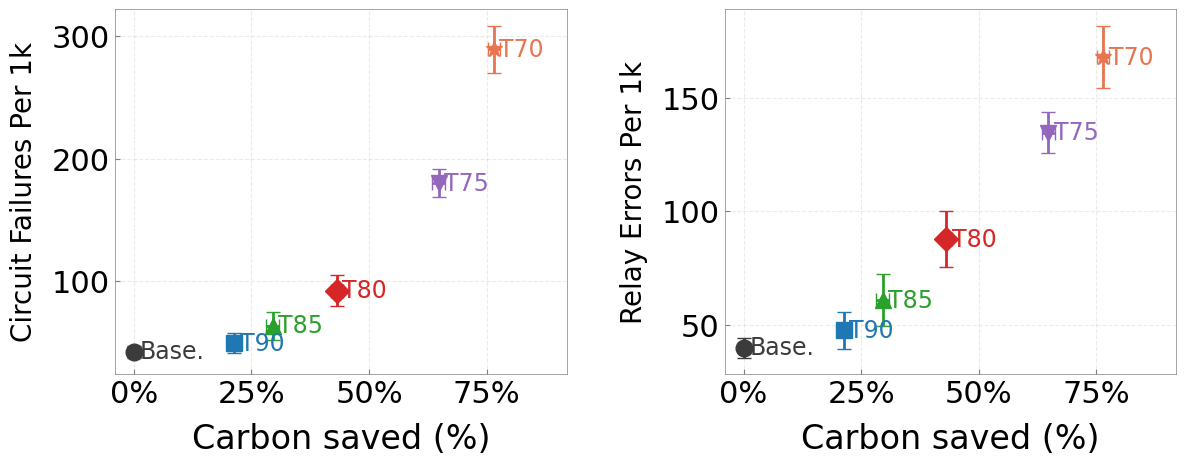

In [254]:
# Plot: carbon savings versus circuit reliability costs.
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharex=True)
reliability_plot_specs = [
    ("failures_per_1000_built", "failures_per_1000_built_std", "Circuit Failures Per 1k"),
    ("errors_per_1000_built", "errors_per_1000_built_std", "Relay Errors Per 1k"),
]

for ax, (metric, std_metric, ylabel) in zip(axes, reliability_plot_specs):
    for _, row in reliability_summary_df.iterrows():
        config = row["config"]
        ax.errorbar(
            row["carbon_saved_pct"], row[metric],
            xerr=0 if pd.isna(row["carbon_saved_std"]) else row["carbon_saved_std"],
            yerr=0 if pd.isna(row[std_metric]) else row[std_metric],
            fmt=CONFIG_MARKERS[config], markersize=12,
            color=CONFIG_COLORS[config], ecolor=CONFIG_COLORS[config],
            elinewidth=2.0, capsize=5,
        )
        ax.text(
            row["carbon_saved_pct"] + 1.2, row[metric], row["label"],
            fontsize=17, color=CONFIG_COLORS[config], va="center",
        )

    ax.set_xlabel("Carbon saved (%)", fontsize=LABEL_SIZE, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=20, labelpad=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    format_axes(ax)

axes[0].set_xlim(-4, 92)
fig.subplots_adjust(left=0.11, right=0.98, bottom=0.20, top=0.96, wspace=0.35)

out_path = FIGURES_DIR / "reliability_vs_carbon_saved.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


This analysis below can likely be included in text

In [255]:
# Load concentration summary. Effective count is 1 / sum(share^2), so higher means less concentration.
relay_daily_df = (
    relay_hour_df.groupby(["network", "config", "config_label", "relay"], as_index=False)
    .agg(throughput_bytes=("throughput", "sum"))
)
relay_daily_df["share"] = (
    relay_daily_df["throughput_bytes"]
    / relay_daily_df.groupby(["network", "config"])["throughput_bytes"].transform("sum")
)

relay_concentration_network_df = (
    relay_daily_df.groupby(["network", "config", "config_label"], as_index=False)
    .agg(
        relays=("relay", "nunique"),
        relay_hhi=("share", lambda s: (s ** 2).sum() * 10000),
        effective_relays=("share", lambda s: 1 / (s ** 2).sum()),
        top10_relay_share=("share", lambda s: s.nlargest(10).sum() * 100),
    )
)

country_daily_load_df = (
    relay_hour_df.groupby(["network", "config", "config_label", "country"], as_index=False)
    .agg(throughput_bytes=("throughput", "sum"))
)
country_daily_load_df["share"] = (
    country_daily_load_df["throughput_bytes"]
    / country_daily_load_df.groupby(["network", "config"])["throughput_bytes"].transform("sum")
)

country_concentration_network_df = (
    country_daily_load_df.groupby(["network", "config", "config_label"], as_index=False)
    .agg(
        countries=("country", "nunique"),
        country_hhi=("share", lambda s: (s ** 2).sum() * 10000),
        effective_countries=("share", lambda s: 1 / (s ** 2).sum()),
        top3_country_share=("share", lambda s: s.nlargest(3).sum() * 100),
    )
)

concentration_network_df = relay_concentration_network_df.merge(
    country_concentration_network_df.drop(columns="config_label"),
    on=["network", "config"],
    how="left",
).merge(
    tradeoff_network_df[["network", "config", "carbon_pct_baseline"]],
    on=["network", "config"],
    how="left",
)
concentration_network_df["carbon_saved_pct"] = 100 - concentration_network_df["carbon_pct_baseline"]

concentration_summary_df = (
    concentration_network_df.groupby(["config", "config_label"], as_index=False)
    .agg(
        carbon_saved_pct=("carbon_saved_pct", "mean"),
        carbon_saved_std=("carbon_saved_pct", "std"),
        effective_relays=("effective_relays", "mean"),
        effective_relays_std=("effective_relays", "std"),
        top10_relay_share=("top10_relay_share", "mean"),
        effective_countries=("effective_countries", "mean"),
        effective_countries_std=("effective_countries", "std"),
        top3_country_share=("top3_country_share", "mean"),
    )
)
concentration_summary_df["label"] = concentration_summary_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})
concentration_summary_df["config_rank"] = concentration_summary_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
concentration_summary_df = concentration_summary_df.sort_values("config_rank").drop(columns="config_rank")

concentration_display_df = pd.DataFrame({
    "Setting": concentration_summary_df["label"],
    "Carbon saved": concentration_summary_df["carbon_saved_pct"].map(lambda v: f"{v:.1f}%"),
    "Effective relays": concentration_summary_df["effective_relays"].map(lambda v: f"{v:.0f}"),
    "Top-10 relay share": concentration_summary_df["top10_relay_share"].map(lambda v: f"{v:.1f}%"),
    "Effective countries": concentration_summary_df["effective_countries"].map(lambda v: f"{v:.1f}"),
    "Top-3 country share": concentration_summary_df["top3_country_share"].map(lambda v: f"{v:.1f}%"),
})

concentration_csv_path = FIGURES_DIR / "load_concentration_summary.csv"
concentration_display_df.to_csv(concentration_csv_path, index=False)
print(concentration_csv_path)
concentration_display_df


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/load_concentration_summary.csv


,Setting,Carbon saved,Effective relays,Top-10 relay share,Effective countries,Top-3 country share
5,Base.,0.0%,243,10.9%,5.9,60.9%
0,T90,21.3%,293,8.4%,9.5,45.7%
1,T85,29.5%,281,7.8%,10.8,42.5%
2,T80,43.1%,233,7.7%,11.6,39.1%
3,T75,64.8%,183,9.1%,10.1,41.7%
4,T70,76.5%,134,11.1%,8.5,47.7%


In [256]:
# Relay usage overlap: baseline vs T70/T75.
relay_usage_df = relay_daily_df[relay_daily_df["throughput_bytes"] > 0]

overlap_rows = []
for network in NETWORKS:
    net_usage = relay_usage_df[relay_usage_df["network"] == network]
    baseline_relays = set(net_usage.loc[net_usage["config"] == "baseline", "relay"])

    for label in ["T75", "T70"]:
        config_val = next(c for c in CONFIG_ORDER if CONFIG_LABELS.get(c) == label)
        case_relays = set(net_usage.loc[net_usage["config"] == config_val, "relay"])

        dropped = baseline_relays - case_relays  # used in baseline, not in this case
        added = case_relays - baseline_relays    # used in this case, not in baseline

        overlap_rows.append({
            "network": network,
            "config_label": label,
            "baseline_relays_used": len(baseline_relays),
            "case_relays_used": len(case_relays),
            "relays_dropped": len(dropped),
            "relays_added": len(added),
        })

relay_overlap_df = pd.DataFrame(overlap_rows)
print(relay_overlap_df)

relay_overlap_summary_df = (
    relay_overlap_df.groupby("config_label", as_index=False)
    .agg(
        baseline_relays_used=("baseline_relays_used", "mean"),
        case_relays_used=("case_relays_used", "mean"),
        relays_dropped=("relays_dropped", "mean"),
        relays_added=("relays_added", "mean"),
    )
)
print("\nAveraged across networks (if more than one replicate):")
print(relay_overlap_summary_df.round(1))

  network config_label  baseline_relays_used  case_relays_used  \
0      n1          T75                   618               587   
1      n1          T70                   618               432   
2      n2          T75                   618               581   
3      n2          T70                   618               428   
4      n4          T75                   618               589   
5      n4          T70                   618               427   
6      n5          T75                   620               601   
7      n5          T70                   620               433   
8      n6          T75                   620               579   
9      n6          T70                   620               437   

   relays_dropped  relays_added  
0              77            46  
1             212            26  
2              79            42  
3             219            29  
4              70            41  
5             223            32  
6              66            47  
7

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/load_concentration_vs_carbon_saved.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/load_concentration_vs_carbon_saved.pdf


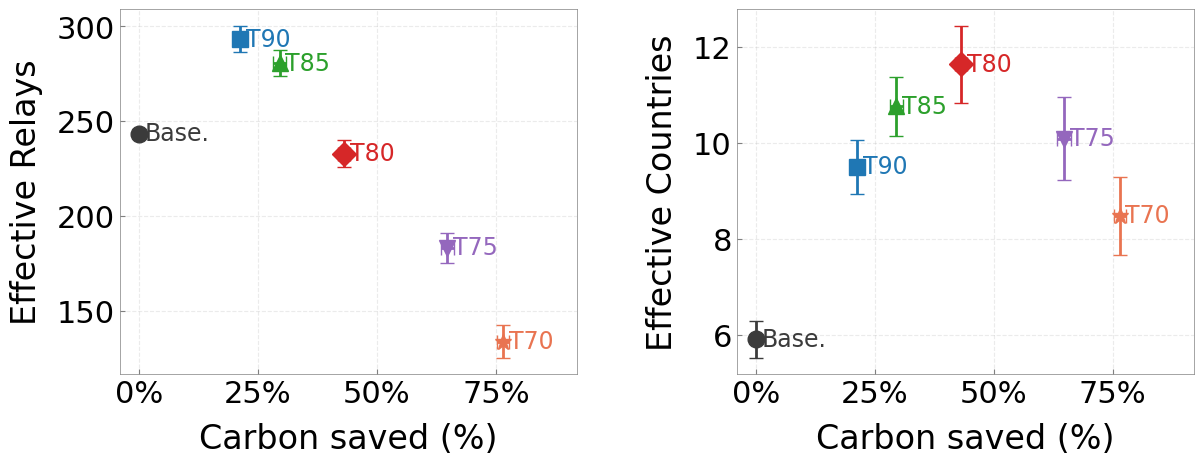

In [257]:
# Plot: carbon savings versus load concentration.
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8), sharex=True)
concentration_plot_specs = [
    ("effective_relays", "effective_relays_std", "Effective Relays"),
    ("effective_countries", "effective_countries_std", "Effective Countries"),
]

for ax, (metric, std_metric, ylabel) in zip(axes, concentration_plot_specs):
    for _, row in concentration_summary_df.iterrows():
        config = row["config"]
        ax.errorbar(
            row["carbon_saved_pct"], row[metric],
            xerr=0 if pd.isna(row["carbon_saved_std"]) else row["carbon_saved_std"],
            yerr=0 if pd.isna(row[std_metric]) else row[std_metric],
            fmt=CONFIG_MARKERS[config], markersize=12,
            color=CONFIG_COLORS[config], ecolor=CONFIG_COLORS[config],
            elinewidth=2.0, capsize=5,
        )
        ax.text(
            row["carbon_saved_pct"] + 1.2, row[metric], row["label"],
            fontsize=17, color=CONFIG_COLORS[config], va="center",
        )

    ax.set_xlabel("Carbon saved (%)", fontsize=LABEL_SIZE, labelpad=10)
    ax.set_ylabel(ylabel, fontsize=LABEL_SIZE, labelpad=10)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    format_axes(ax)

axes[0].set_xlim(-4, 92)
fig.subplots_adjust(left=0.10, right=0.98, bottom=0.20, top=0.96, wspace=0.35)

out_path = FIGURES_DIR / "load_concentration_vs_carbon_saved.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


In [258]:
# Share of traffic routed through countries above dirty-grid thresholds.
dirty_thresholds = [150, 300, 400, 600]
high_carbon_rows = []

for (network, config, config_label), sub in relay_hour_df.groupby(["network", "config", "config_label"]):
    row = {
        "network": network,
        "config": config,
        "config_label": config_label,
        "throughput_bytes": sub["throughput"].sum(),
    }
    for threshold in dirty_thresholds:
        row[f"traffic_ge_{threshold}_bytes"] = sub.loc[
            sub["carbon_intensity"] >= threshold, "throughput"
        ].sum()
    high_carbon_rows.append(row)

high_carbon_network_df = pd.DataFrame(high_carbon_rows)
for threshold in dirty_thresholds:
    high_carbon_network_df[f"traffic_ge_{threshold}_share"] = (
        high_carbon_network_df[f"traffic_ge_{threshold}_bytes"]
        / high_carbon_network_df["throughput_bytes"] * 100
    )

high_carbon_network_df = high_carbon_network_df.merge(
    tradeoff_network_df[["network", "config", "carbon_pct_baseline"]],
    on=["network", "config"],
    how="left",
)
high_carbon_network_df["carbon_saved_pct"] = 100 - high_carbon_network_df["carbon_pct_baseline"]

agg_spec = {
    "carbon_saved_pct": ("carbon_saved_pct", "mean"),
    "carbon_saved_std": ("carbon_saved_pct", "std"),
}
for threshold in dirty_thresholds:
    agg_spec[f"traffic_ge_{threshold}_share"] = (f"traffic_ge_{threshold}_share", "mean")
    agg_spec[f"traffic_ge_{threshold}_share_std"] = (f"traffic_ge_{threshold}_share", "std")

high_carbon_summary_df = (
    high_carbon_network_df.groupby(["config", "config_label"], as_index=False)
    .agg(**agg_spec)
)
high_carbon_summary_df["label"] = high_carbon_summary_df["config"].map({**CONFIG_LABELS, "baseline": "Base."})
high_carbon_summary_df["config_rank"] = high_carbon_summary_df["config"].map({config: i for i, config in enumerate(CONFIG_ORDER)})
high_carbon_summary_df = high_carbon_summary_df.sort_values("config_rank").drop(columns="config_rank")

high_carbon_display_df = pd.DataFrame({
    "Setting": high_carbon_summary_df["label"],
    "Carbon saved": high_carbon_summary_df["carbon_saved_pct"].map(lambda v: f"{v:.1f}%"),
    ">=150": high_carbon_summary_df["traffic_ge_150_share"].map(lambda v: f"{v:.1f}%"),
    ">=300": high_carbon_summary_df["traffic_ge_300_share"].map(lambda v: f"{v:.1f}%"),
    ">=400": high_carbon_summary_df["traffic_ge_400_share"].map(lambda v: f"{v:.1f}%"),
    ">=600": high_carbon_summary_df["traffic_ge_600_share"].map(lambda v: f"{v:.1f}%"),
})

high_carbon_csv_path = FIGURES_DIR / "dirty_grid_traffic_share_summary.csv"
high_carbon_display_df.to_csv(high_carbon_csv_path, index=False)
print(high_carbon_csv_path)
high_carbon_display_df


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/dirty_grid_traffic_share_summary.csv


,Setting,Carbon saved,>=150,>=300,>=400,>=600
5,Base.,0.0%,48.4%,20.8%,4.0%,1.2%
0,T90,21.3%,33.4%,14.4%,2.7%,0.8%
1,T85,29.5%,27.8%,12.1%,2.2%,0.6%
2,T80,43.1%,18.6%,8.3%,1.4%,0.4%
3,T75,64.8%,4.6%,0.0%,0.0%,0.0%
4,T70,76.5%,0.1%,0.0%,0.0%,0.0%


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/dirty_grid_traffic_vs_carbon_saved.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/dirty_grid_traffic_vs_carbon_saved.pdf


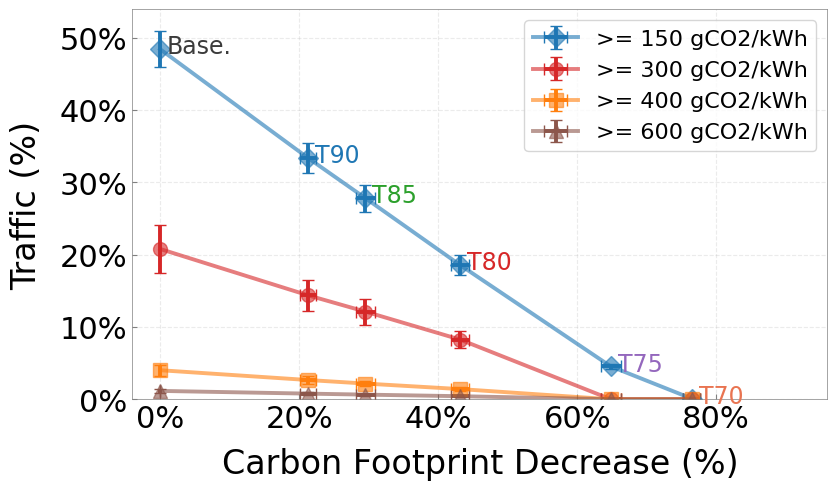

In [259]:
# Plot: the optimizer quickly removes traffic from high-carbon grids.
fig, ax = plt.subplots(figsize=(8.8, 5.0))
threshold_colors = {150: "#1F77B4", 300: "#D62728", 400: "#FF7F0E", 600: "#8C564B"}
threshold_markers = {150: "D", 300: "o", 400: "s", 600: "^"}

for threshold in dirty_thresholds:
    y_col = f"traffic_ge_{threshold}_share"
    yerr_col = f"traffic_ge_{threshold}_share_std"
    plotline, caps, bars = ax.errorbar(
        high_carbon_summary_df["carbon_saved_pct"], high_carbon_summary_df[y_col],
        xerr=high_carbon_summary_df["carbon_saved_std"].fillna(0),
        yerr=high_carbon_summary_df[yerr_col].fillna(0),
        marker=threshold_markers[threshold], markersize=10,
        linewidth=2.8, capsize=4,
        color=threshold_colors[threshold],
        label=f">= {threshold} gCO2/kWh",
    )
    plotline.set_alpha(0.6) 

for _, row in high_carbon_summary_df.iterrows():
    ax.text(
        row["carbon_saved_pct"] + 1.0, row["traffic_ge_150_share"] + 0.35,
        row["label"], fontsize=17, color=CONFIG_COLORS[row["config"]], va="center",
    )

ax.set_xlabel("Carbon Footprint Decrease (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Traffic (%)", fontsize=LABEL_SIZE, labelpad=12)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlim(-4, 96)
max_dirty_grid_share = max(
    (
        high_carbon_summary_df[f"traffic_ge_{threshold}_share"]
        + high_carbon_summary_df[f"traffic_ge_{threshold}_share_std"]
    ).max()
    for threshold in dirty_thresholds
)
ax.set_ylim(0, max(26, max_dirty_grid_share + 3))
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.tick_params(axis="both", labelsize=FONT_SIZE)
ax.legend(ncol=1, loc="upper right", frameon=True, fontsize=16)
format_axes(ax)
fig.subplots_adjust(left=0.18, right=0.97, bottom=0.18, top=0.96)

out_path = FIGURES_DIR / "dirty_grid_traffic_vs_carbon_saved.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()


# Section 5(C)2 - security analysis

We compare a naive attacker that can controls relays at random with attackers that target to control the lowest-carbon or highest-bandwidth relays. The attacker budget is a percentage of the relay count. A circuit is compromised when the attacker controls its guard and exit; controlling all three relays is a stricter secondary outcome.

## Load security data

In [260]:
# One row per network, configuration, attacker, and attacker budget.
SECURITY_ATTACKERS = {
    "random": ("cache_sybil_random.csv", "Naive: random relays"),
    "low_ci": ("cache_sybil_ci.csv", "Adaptive: lowest-carbon relays"),
    "high_bw": ("cache_sybil_bw.csv", "Highest-bandwidth relays"),
}

security_sybil_parts = []
security_sybil_missing = []

for network in NETWORKS:
    for config in CONFIG_ORDER:
        config_dir = config_paths[network][config]
        for strategy, (filename, attacker_label) in SECURITY_ATTACKERS.items():
            cache_path = config_dir / filename
            if not cache_path.exists():
                security_sybil_missing.append({
                    "network": network,
                    "config": config,
                    "strategy": strategy,
                    "missing": filename,
                })
                continue

            sybil = pd.read_csv(cache_path)
            sybil["network"] = network
            sybil["config"] = config
            sybil["config_label"] = CONFIG_LABELS[config]
            sybil["strategy"] = strategy
            sybil["attacker_label"] = attacker_label
            security_sybil_parts.append(sybil)

security_sybil_df = pd.concat(security_sybil_parts, ignore_index=True)
security_sybil_df["percent"] = pd.to_numeric(security_sybil_df["percent"])
security_sybil_missing_df = pd.DataFrame(security_sybil_missing)

security_sybil_coverage_df = (
    security_sybil_df.groupby(["network", "config", "strategy"], as_index=False)
    .agg(attacker_budgets=("percent", "nunique"), circuits=("total_circuits", "max"))
)

print(f"Sybil rows: {len(security_sybil_df):,}")
print(f"Missing Sybil caches: {len(security_sybil_missing_df):,}")
security_sybil_coverage_df.head()

Sybil rows: 9,000
Missing Sybil caches: 0


,network,config,strategy,attacker_budgets,circuits
0,n1,a0.20-k0.10-q1,high_bw,100,6439345
1,n1,a0.20-k0.10-q1,low_ci,100,6439345
2,n1,a0.20-k0.10-q1,random,100,6439345
3,n1,a0.30-k0.10-q1,high_bw,100,6348352
4,n1,a0.30-k0.10-q1,low_ci,100,6348352


In [261]:
# Aggregate the hourly ASN caches within each network and configuration.
security_asn_network_rows = []
security_asn_match_rows = []

for network in NETWORKS:
    for config in CONFIG_ORDER:
        total_circuits = 0
        hours = 0
        guard_exit_by_asn = {}
        all_three_by_asn = {}

        for hour_dir in hour_dirs_for(network, config_paths[network][config]):
            cache_path = hour_dir / "cache_asn_analysis.json"
            if not cache_path.exists():
                continue

            cached = json.loads(cache_path.read_text())
            total_circuits += cached["total"]
            hours += 1

            for asn, count in cached["match_1_3"].items():
                guard_exit_by_asn[asn] = guard_exit_by_asn.get(asn, 0) + count
            for asn, count in cached["match_all"].items():
                all_three_by_asn[asn] = all_three_by_asn.get(asn, 0) + count

        guard_exit_matches = sum(guard_exit_by_asn.values())
        all_three_matches = sum(all_three_by_asn.values())
        security_asn_network_rows.append({
            "network": network,
            "config": config,
            "config_label": CONFIG_LABELS[config],
            "hours": hours,
            "total_circuits": total_circuits,
            "guard_exit_matches": guard_exit_matches,
            "all_three_matches": all_three_matches,
            "guard_exit_pct": guard_exit_matches / total_circuits * 100,
            "all_three_pct": all_three_matches / total_circuits * 100,
        })

        for outcome, matches in [
            ("Guard and exit", guard_exit_by_asn),
            ("All three", all_three_by_asn),
        ]:
            for asn, count in matches.items():
                security_asn_match_rows.append({
                    "network": network,
                    "config": config,
                    "config_label": CONFIG_LABELS[config],
                    "outcome": outcome,
                    "asn": asn,
                    "matches": count,
                    "total_circuits": total_circuits,
                })

security_asn_network_df = pd.DataFrame(security_asn_network_rows)
security_asn_match_df = pd.DataFrame(security_asn_match_rows)

print(f"ASN network/config rows: {len(security_asn_network_df):,}")
security_asn_network_df.head()

ASN network/config rows: 30


,network,config,config_label,hours,total_circuits,guard_exit_matches,all_three_matches,guard_exit_pct,all_three_pct
0,n1,baseline,Baseline,24,6739847,50634,2641,0.751263,0.039185
1,n1,a0.20-k0.10-q1,T90,24,6439345,49262,2773,0.765016,0.043063
2,n1,a0.30-k0.10-q1,T85,24,6348352,51076,2867,0.804555,0.045161
3,n1,a0.50-k0.10-q1,T80,24,6258206,56299,2995,0.899603,0.047857
4,n1,a1.0-k0.04-q1,T75,24,6967145,72346,3253,1.038388,0.046691


## Malicious relays

The random attacker is unaware of the selection policy. The lowest-carbon attacker targets the relays favored by carbon-aware selection, while the highest-bandwidth attacker targets the relays favored by Tor's baseline. The main panels show the complete 1--100% range; the insets use independent y-axis scales to show 1--10%.

In [262]:
# Mean and one standard deviation across networks.
security_sybil_summary_df = (
    security_sybil_df.groupby(
        ["strategy", "attacker_label", "config", "config_label", "percent"],
        as_index=False,
    )
    .agg(
        networks=("network", "nunique"),
        guard_exit_mean=("match_rate_2hop", "mean"),
        guard_exit_std=("match_rate_2hop", "std"),
        all_three_mean=("match_rate_3hop", "mean"),
        all_three_std=("match_rate_3hop", "std"),
    )
)

for col in ["guard_exit_mean", "guard_exit_std", "all_three_mean", "all_three_std"]:
    security_sybil_summary_df[col] *= 100

security_sybil_10pct_df = security_sybil_summary_df[
    security_sybil_summary_df["percent"] == 10
].copy()

for metric in ["guard_exit", "all_three"]:
    baseline = (
        security_sybil_10pct_df[security_sybil_10pct_df["config"] == "baseline"]
        .set_index("strategy")[f"{metric}_mean"]
    )
    security_sybil_10pct_df[f"{metric}_vs_baseline"] = (
        security_sybil_10pct_df.apply(
            lambda row: row[f"{metric}_mean"] / baseline[row["strategy"]], axis=1
        )
    )

security_sybil_10pct_df["config_rank"] = security_sybil_10pct_df["config"].map(config_rank)
security_sybil_10pct_df["strategy_rank"] = security_sybil_10pct_df["strategy"].map(
    {"random": 0, "low_ci": 1, "high_bw": 2}
)
security_sybil_10pct_df = security_sybil_10pct_df.sort_values(
    ["strategy_rank", "config_rank"]
)

security_sybil_10pct_display_df = pd.DataFrame({
    "Attacker": security_sybil_10pct_df["attacker_label"],
    "Setting": security_sybil_10pct_df["config_label"],
    "Guard + exit": security_sybil_10pct_df["guard_exit_mean"].map(lambda v: f"{v:.2f}%"),
    "G+E / Base": security_sybil_10pct_df["guard_exit_vs_baseline"].map(lambda v: f"{v:.2f}x"),
    "All three": security_sybil_10pct_df["all_three_mean"].map(lambda v: f"{v:.2f}%"),
    "All 3 / Base": security_sybil_10pct_df["all_three_vs_baseline"].map(lambda v: f"{v:.2f}x"),
})

security_sybil_csv_path = FIGURES_DIR / "security_sybil_summary.csv"
security_sybil_10pct_csv_path = FIGURES_DIR / "security_sybil_10pct_summary.csv"
security_sybil_summary_df.to_csv(security_sybil_csv_path, index=False)
security_sybil_10pct_display_df.to_csv(security_sybil_10pct_csv_path, index=False)
print(security_sybil_csv_path)
print(security_sybil_10pct_csv_path)
security_sybil_10pct_display_df

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_sybil_summary.csv
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_sybil_10pct_summary.csv


,Attacker,Setting,Guard + exit,G+E / Base,All three,All 3 / Base
1709,Naive: random relays,Baseline,0.51%,1.00x,0.04%,1.00x
1209,Naive: random relays,T90,0.57%,1.12x,0.04%,1.21x
1309,Naive: random relays,T85,0.43%,0.85x,0.03%,0.92x
1409,Naive: random relays,T80,0.43%,0.84x,0.03%,0.92x
1509,Naive: random relays,T75,0.45%,0.88x,0.04%,0.99x
1609,Naive: random relays,T70,0.65%,1.26x,0.06%,1.57x
1109,Adaptive: lowest-carbon relays,Baseline,0.80%,1.00x,0.04%,1.00x
609,Adaptive: lowest-carbon relays,T90,3.26%,4.05x,0.40%,9.34x
709,Adaptive: lowest-carbon relays,T85,3.80%,4.72x,0.55%,12.83x
809,Adaptive: lowest-carbon relays,T80,5.83%,7.24x,1.16%,27.28x


In [263]:
LABEL_SIZE_LARGE = LABEL_SIZE + 6

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_sybil_guard_exit_all_networks.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_sybil_guard_exit_all_networks.pdf


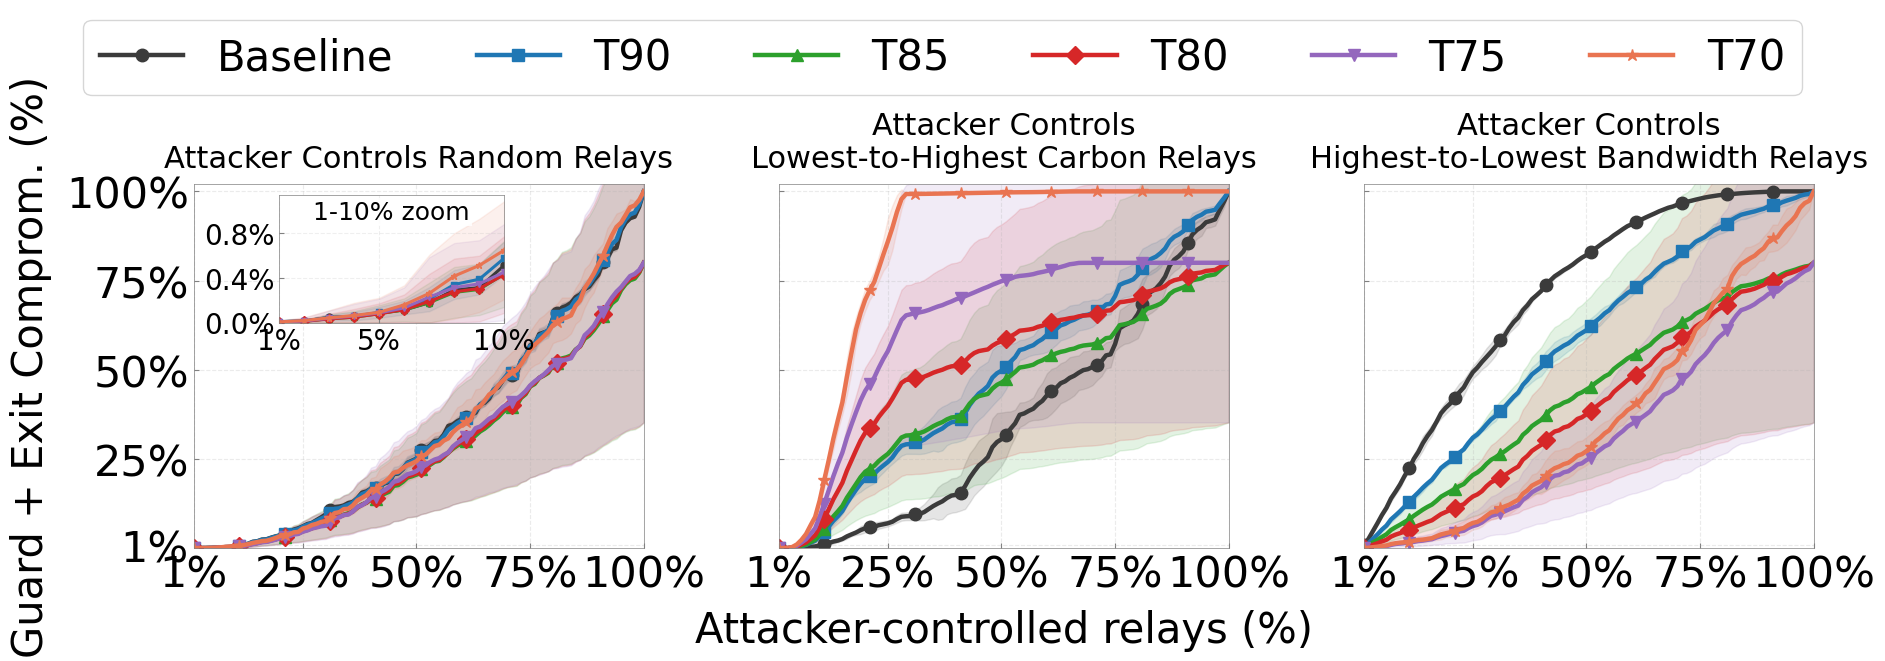

In [304]:
# Guard and exit compromise rate. This is the main relay-adversary figure.
strategy_order = ["random", "low_ci", "high_bw"]
strategy_titles = {
    "random": "Attacker Controls Random Relays",
    "low_ci": "Attacker Controls\nLowest-to-Highest Carbon Relays",
    "high_bw": "Attacker Controls\nHighest-to-Lowest Bandwidth Relays",
}

fig, axes = plt.subplots(1, 3, figsize=(18.0, 7.0), sharey=True)

for ax, strategy in zip(axes, strategy_order):
    strategy_df = security_sybil_summary_df[
        security_sybil_summary_df["strategy"] == strategy
    ]
    if strategy == "random":
        axins = ax.inset_axes([0.19, 0.62, 0.50, 0.35])

    for config in CONFIG_ORDER:
        sub = strategy_df[strategy_df["config"] == config].sort_values("percent")
        lower = np.maximum(0, sub["guard_exit_mean"] - sub["guard_exit_std"])
        upper = sub["guard_exit_mean"] + sub["guard_exit_std"]
        ax.plot(
            sub["percent"], sub["guard_exit_mean"],
            color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
            linewidth=LINE_WIDTH, markersize=MARKER_SIZE, markevery=10,
            label=CONFIG_LABELS[config],
        )
        ax.fill_between(sub["percent"], lower, upper, color=CONFIG_COLORS[config], alpha=0.13)

        if strategy == "random":
            zoom = sub[sub["percent"] <= 10]
            zoom_lower = np.maximum(0, zoom["guard_exit_mean"] - zoom["guard_exit_std"])
            zoom_upper = zoom["guard_exit_mean"] + zoom["guard_exit_std"]
            axins.plot(
                zoom["percent"], zoom["guard_exit_mean"],
                color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
                linewidth=2.2, markersize=5,
            )
            axins.fill_between(
                zoom["percent"], zoom_lower, zoom_upper,
                color=CONFIG_COLORS[config], alpha=0.10,
            )

    ax.set_title(strategy_titles[strategy], fontsize=FONT_SIZE, pad=12)
    if strategy == "low_ci":
        ax.set_xlabel("Attacker-controlled relays (%)", fontsize=LABEL_SIZE_LARGE, labelpad=10)
    else: 
        ax.set_xlabel("")
    ax.set_xlim(1, 100)
    ax.set_ylim(0, 102)
    ax.set_xticks([1, 25, 50, 75, 100])
    ax.set_yticks([1, 25, 50, 75, 100])
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=LABEL_SIZE_LARGE+1)
    format_axes(ax)
    if ax is not axes[0]:
        plt.setp(ax.get_yticklabels(), visible=False)

    if strategy == "random":
        zoom_df = strategy_df[strategy_df["percent"] <= 10]
        zoom_max = (zoom_df["guard_exit_mean"] + zoom_df["guard_exit_std"]).max()
        axins.set_xlim(1, 10)
        axins.set_ylim(0, max(0.1, zoom_max * 1.05))
        axins.set_xticks([1, 5, 10])
        axins.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
        axins.yaxis.set_major_locator(mtick.MaxNLocator(nbins=3))
        axins.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
        axins.set_facecolor("white")
        axins.text(
            0.50, 0.96, "1-10% zoom", transform=axins.transAxes,
            ha="center", va="top", fontsize=18,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.5},
        )
        axins.grid(axis="both", linestyle="--", alpha=0.20)
        axins.tick_params(axis="both", labelsize=20)
        format_axes(axins)

axes[0].set_ylabel("Guard + Exit Comprom. (%)", fontsize=LABEL_SIZE_LARGE, labelpad=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc="upper center", frameon=True, fontsize=LABEL_SIZE_LARGE)
fig.subplots_adjust(left=0.09, right=0.99, bottom=0.20, top=0.72, wspace=0.30)

out_path = FIGURES_DIR / "security_sybil_guard_exit_all_networks.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_sybil_all_three_all_networks.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_sybil_all_three_all_networks.pdf


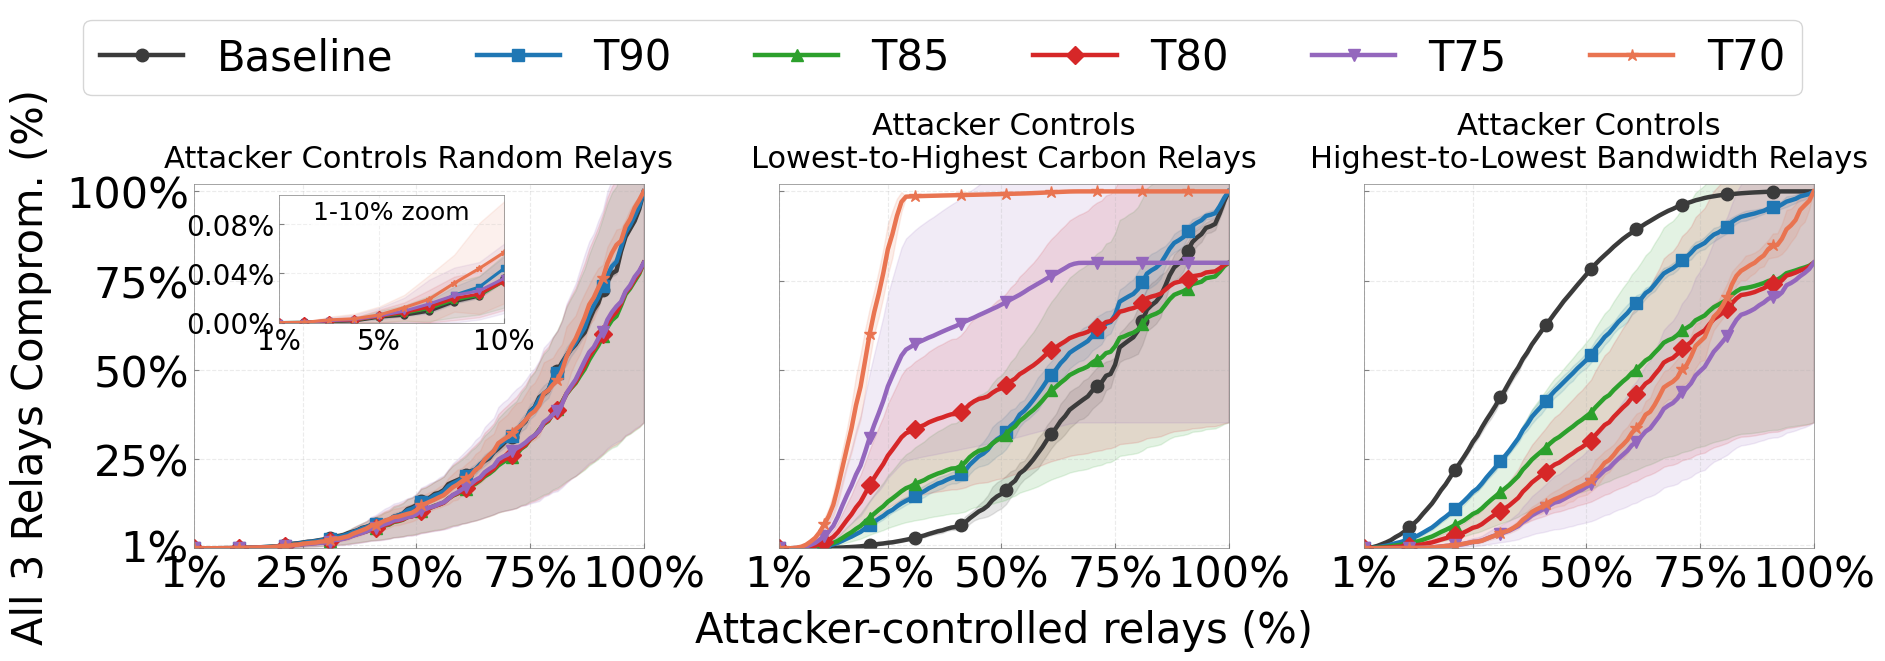

In [305]:
# All-three compromise rate, separated because it is much smaller.
fig, axes = plt.subplots(1, 3, figsize=(18.0, 7.0), sharey=True)

for ax, strategy in zip(axes, strategy_order):
    strategy_df = security_sybil_summary_df[
        security_sybil_summary_df["strategy"] == strategy
    ]
    if strategy == "random":
        axins = ax.inset_axes([0.19, 0.62, 0.50, 0.35])

    for config in CONFIG_ORDER:
        sub = strategy_df[strategy_df["config"] == config].sort_values("percent")
        lower = np.maximum(0, sub["all_three_mean"] - sub["all_three_std"])
        upper = sub["all_three_mean"] + sub["all_three_std"]
        ax.plot(
            sub["percent"], sub["all_three_mean"],
            color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
            linewidth=LINE_WIDTH, markersize=MARKER_SIZE, markevery=10,
            label=CONFIG_LABELS[config],
        )
        ax.fill_between(sub["percent"], lower, upper, color=CONFIG_COLORS[config], alpha=0.13)

        if strategy == "random":
            zoom = sub[sub["percent"] <= 10]
            zoom_lower = np.maximum(0, zoom["all_three_mean"] - zoom["all_three_std"])
            zoom_upper = zoom["all_three_mean"] + zoom["all_three_std"]
            axins.plot(
                zoom["percent"], zoom["all_three_mean"],
                color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
                linewidth=2.2, markersize=5,
            )
            axins.fill_between(
                zoom["percent"], zoom_lower, zoom_upper,
                color=CONFIG_COLORS[config], alpha=0.10,
            )

    ax.set_title(strategy_titles[strategy], fontsize=FONT_SIZE, pad=12)
    if strategy == "low_ci":
        ax.set_xlabel("Attacker-controlled relays (%)", fontsize=LABEL_SIZE_LARGE, labelpad=10)
    else:
        ax.set_xlabel("")
    ax.set_xlim(1, 100)
    ax.set_ylim(0, 102)
    ax.set_xticks([1, 25, 50, 75, 100])
    ax.set_yticks([1, 25, 50, 75, 100])
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=LABEL_SIZE_LARGE+1)
    format_axes(ax)
    if ax is not axes[0]:
        plt.setp(ax.get_yticklabels(), visible=False)

    if strategy == "random":
        zoom_df = strategy_df[strategy_df["percent"] <= 10]
        zoom_max = (zoom_df["all_three_mean"] + zoom_df["all_three_std"]).max()
        axins.set_xlim(1, 10)
        axins.set_ylim(0, max(0.01, zoom_max * 1.05))
        axins.set_xticks([1, 5, 10])
        axins.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
        axins.yaxis.set_major_locator(mtick.MaxNLocator(nbins=3))
        axins.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))
        axins.set_facecolor("white")
        axins.text(
            0.50, 0.96, "1-10% zoom", transform=axins.transAxes,
            ha="center", va="top", fontsize=18,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.5},
        )
        axins.grid(axis="both", linestyle="--", alpha=0.20)
        axins.tick_params(axis="both", labelsize=20)
        format_axes(axins)

axes[0].set_ylabel("All 3 Relays Comprom. (%)", fontsize=LABEL_SIZE_LARGE, labelpad=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=6, loc="upper center", frameon=True, fontsize=LABEL_SIZE_LARGE)
fig.subplots_adjust(left=0.09, right=0.99, bottom=0.20, top=0.72, wspace=0.30)

out_path = FIGURES_DIR / "security_sybil_all_three_all_networks.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

## Autonomous systems

The cached ASN analysis checks whether selected relays share the same hosting ASN. In the figure below, white points are individual generated networks, bars are the unweighted mean across networks, and whiskers show one standard deviation. This is a relay co-location measure, not a full AS-path correlation analysis: it does not include ASes on the client-to-guard or exit-to-destination paths, route asymmetry, or BGP manipulation.

In [268]:
# ASN co-location summary across networks.
security_asn_summary_df = (
    security_asn_network_df.groupby(["config", "config_label"], as_index=False)
    .agg(
        networks=("network", "nunique"),
        hours_min=("hours", "min"),
        guard_exit_mean=("guard_exit_pct", "mean"),
        guard_exit_std=("guard_exit_pct", "std"),
        all_three_mean=("all_three_pct", "mean"),
        all_three_std=("all_three_pct", "std"),
    )
)
security_asn_summary_df["config_rank"] = security_asn_summary_df["config"].map(config_rank)
security_asn_summary_df = security_asn_summary_df.sort_values("config_rank").drop(columns="config_rank")

security_asn_display_df = pd.DataFrame({
    "Setting": security_asn_summary_df["config_label"],
    "Guard + exit": security_asn_summary_df.apply(
        lambda row: f"{row['guard_exit_mean']:.3f}% +/- {row['guard_exit_std']:.3f}", axis=1
    ),
    "All three": security_asn_summary_df.apply(
        lambda row: f"{row['all_three_mean']:.3f}% +/- {row['all_three_std']:.3f}", axis=1
    ),
})

security_asn_contributors_df = (
    security_asn_match_df.groupby(["outcome", "asn"], as_index=False)
    .agg(matches=("matches", "sum"))
)
security_asn_contributors_df["matched_share_pct"] = (
    security_asn_contributors_df["matches"]
    / security_asn_contributors_df.groupby("outcome")["matches"].transform("sum") * 100
)
security_asn_top_df = (
    security_asn_contributors_df.sort_values(["outcome", "matches"], ascending=[True, False])
    .groupby("outcome", as_index=False)
    .head(5)
)

security_asn_csv_path = FIGURES_DIR / "security_asn_summary.csv"
security_asn_top_csv_path = FIGURES_DIR / "security_asn_top_contributors.csv"
security_asn_summary_df.to_csv(security_asn_csv_path, index=False)
security_asn_top_df.to_csv(security_asn_top_csv_path, index=False)
print(security_asn_csv_path)
print(security_asn_top_csv_path)
security_asn_display_df

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_asn_summary.csv
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_asn_top_contributors.csv


,Setting,Guard + exit,All three
5,Baseline,1.163% +/- 0.554,0.060% +/- 0.053
0,T90,1.029% +/- 0.347,0.055% +/- 0.028
1,T85,1.030% +/- 0.281,0.055% +/- 0.021
2,T80,1.108% +/- 0.239,0.058% +/- 0.016
3,T75,1.259% +/- 0.271,0.051% +/- 0.016
4,T70,1.534% +/- 0.408,0.064% +/- 0.026


22
24
30
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_asn_correlation_all_networks.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_asn_correlation_all_networks.pdf


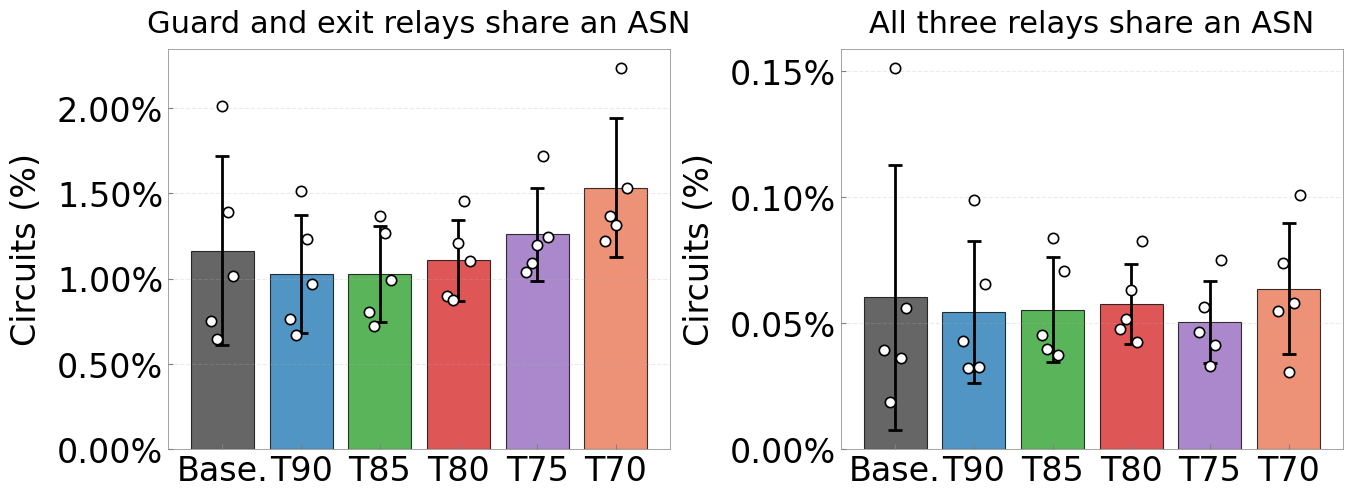

In [276]:
# Bars show the network mean and one standard deviation; dots are individual networks.
fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.8))
asn_plot_specs = [
    ("guard_exit_mean", "guard_exit_std", "guard_exit_pct", "Guard and exit relays share an ASN"),
    ("all_three_mean", "all_three_std", "all_three_pct", "All three relays share an ASN"),
]
x = np.arange(len(CONFIG_ORDER))
network_offsets = dict(zip(NETWORKS, np.linspace(-0.14, 0.14, len(NETWORKS))))

for ax, (mean_col, std_col, network_col, title) in zip(axes, asn_plot_specs):
    means = security_asn_summary_df.set_index("config").loc[CONFIG_ORDER, mean_col]
    errors = security_asn_summary_df.set_index("config").loc[CONFIG_ORDER, std_col]
    ax.bar(
        x, means, yerr=errors,
        color=[CONFIG_COLORS[config] for config in CONFIG_ORDER],
        edgecolor="black", linewidth=0.8, alpha=0.78,
        error_kw={"elinewidth": 2.0, "capsize": 5, "capthick": 2.0},
    )

    for config_i, config in enumerate(CONFIG_ORDER):
        points = security_asn_network_df[security_asn_network_df["config"] == config]
        for _, row in points.iterrows():
            ax.scatter(
                config_i + network_offsets[row["network"]], row[network_col],
                s=55, color="white", edgecolor="black", linewidth=1.2, zorder=3,
            )

    ax.set_title(title, fontsize=FONT_SIZE, pad=12)
    ax.set_xticks(x)
    ax.set_xticklabels(["Base.", "T90", "T85", "T80", "T75", "T70"])
    ax.set_ylabel("Circuits (%)", fontsize=LABEL_SIZE, labelpad=10)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.tick_params(axis="both", labelsize=LABEL_SIZE)
    format_axes(ax)
print(FONT_SIZE)
print(LABEL_SIZE)
print(LABEL_SIZE_LARGE)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.17, top=0.86, wspace=0.34)
out_path = FIGURES_DIR / "security_asn_correlation_all_networks.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

### ASNs contributing to relay co-location

We report public ASN identifiers only and describe them as contributors to same-AS circuits. Hosting multiple selected Tor relays is not evidence that an AS is malicious, controls those relays, or performs traffic correlation.

In [270]:
# Pooled guard-and-exit co-location rate for the most frequent ASNs.
guard_exit_asn_df = (
    security_asn_match_df[security_asn_match_df["outcome"] == "Guard and exit"]
    .groupby(["config", "config_label", "asn"], as_index=False)
    .agg(matches=("matches", "sum"))
)
asn_config_totals_df = (
    security_asn_network_df.groupby(["config", "config_label"], as_index=False)
    .agg(total_circuits=("total_circuits", "sum"))
)
guard_exit_asn_df = guard_exit_asn_df.merge(
    asn_config_totals_df, on=["config", "config_label"], how="left"
)
guard_exit_asn_df["circuit_pct"] = (
    guard_exit_asn_df["matches"] / guard_exit_asn_df["total_circuits"] * 100
)

top_guard_exit_asns = (
    guard_exit_asn_df.groupby("asn")["matches"].sum()
    .nlargest(6)
    .index.tolist()
)
guard_exit_top_df = guard_exit_asn_df[guard_exit_asn_df["asn"].isin(top_guard_exit_asns)].copy()
guard_exit_asn_matrix_df = (
    guard_exit_top_df.pivot(index="config", columns="asn", values="circuit_pct")
    .reindex(index=CONFIG_ORDER, columns=top_guard_exit_asns)
    .fillna(0)
)

guard_exit_total_pct = (
    security_asn_network_df.groupby("config")
    .apply(lambda sub: sub["guard_exit_matches"].sum() / sub["total_circuits"].sum() * 100)
    .reindex(CONFIG_ORDER)
)
guard_exit_asn_matrix_df["Other"] = (
    guard_exit_total_pct - guard_exit_asn_matrix_df.sum(axis=1)
).clip(lower=0)

guard_exit_asn_heatmap_csv_path = FIGURES_DIR / "security_asn_guard_exit_contributors.csv"
guard_exit_asn_matrix_df.to_csv(guard_exit_asn_heatmap_csv_path)
print(guard_exit_asn_heatmap_csv_path)
guard_exit_asn_matrix_df

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_asn_guard_exit_contributors.csv


/var/folders/9z/r9l790y91n7f72h1knh0981h0000gn/T/ipykernel_1366/2594050698.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  security_asn_network_df.groupby("config")


asn,16276,53667,60729,56655,51852,197540,Other
config,,,,,,,
baseline,0.309860,0.056681,0.547059,0.025313,0.001386,0.099683,0.111385
a0.20-k0.10-q1,0.365654,0.118334,0.290470,0.074440,0.014794,0.052007,0.104632
a0.30-k0.10-q1,0.393770,0.152213,0.202682,0.102813,0.025771,0.037623,0.106992
a0.50-k0.10-q1,0.442935,0.218490,0.090587,0.160864,0.050643,0.016258,0.122159
a1.0-k0.04-q1,0.446930,0.246892,0.042920,0.228434,0.092200,0.020489,0.175299
a1.0-k0.10-q1,0.531859,0.367400,0.000102,0.308391,0.121416,0.000042,0.197092


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_asn_guard_exit_contributors.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_asn_guard_exit_contributors.pdf


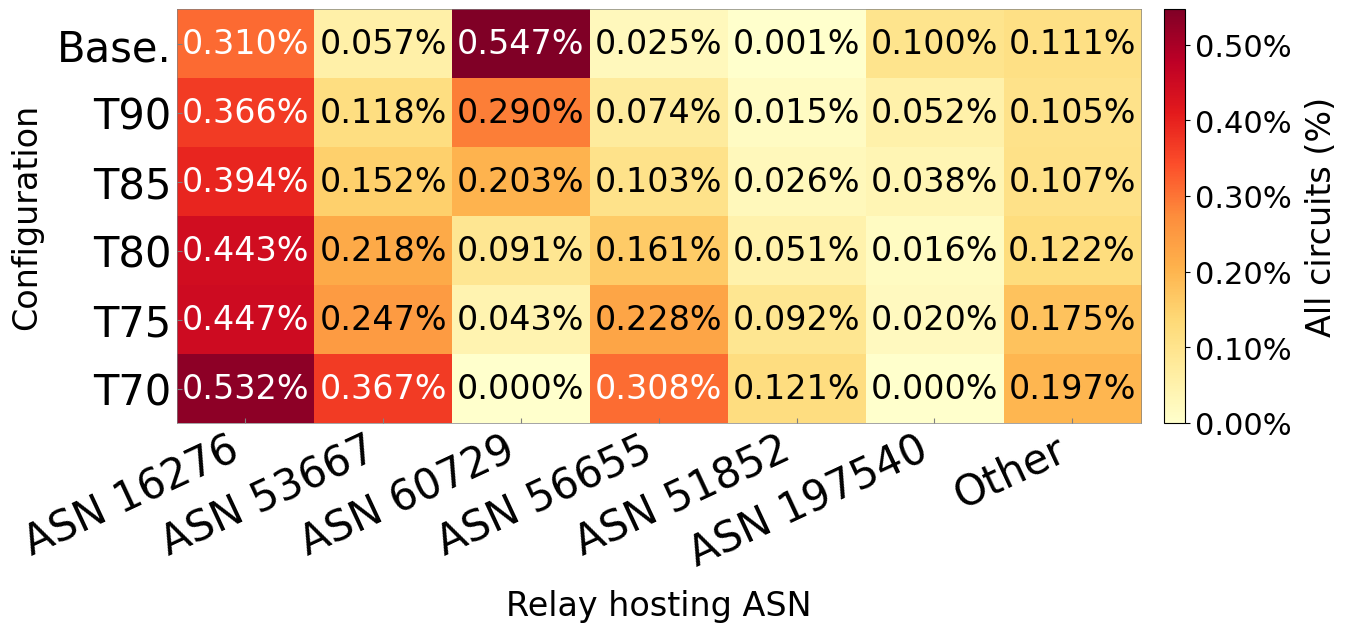

In [279]:
# Heatmap of each ASN's contribution to guard-and-exit same-AS circuits.
fig, ax = plt.subplots(figsize=(14.0, 6.0))
heatmap_values = guard_exit_asn_matrix_df.to_numpy()
image = ax.imshow(heatmap_values, cmap="YlOrRd", aspect="auto", vmin=0)

ax.set_xticks(np.arange(len(guard_exit_asn_matrix_df.columns)))
ax.set_xticklabels(
    [f"ASN {asn}" if asn != "Other" else "Other" for asn in guard_exit_asn_matrix_df.columns],
    rotation=25, ha="right",
)
ax.set_yticks(np.arange(len(CONFIG_ORDER)))
ax.set_yticklabels(["Base.", "T90", "T85", "T80", "T75", "T70"])
ax.set_xlabel("Relay hosting ASN", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Configuration", fontsize=LABEL_SIZE, labelpad=10)
ax.tick_params(axis="both", labelsize=LABEL_SIZE_LARGE)

threshold = heatmap_values.max() * 0.55
for row in range(heatmap_values.shape[0]):
    for col in range(heatmap_values.shape[1]):
        value = heatmap_values[row, col]
        ax.text(
            col, row, f"{value:.3f}%",
            ha="center", va="center", fontsize=LABEL_SIZE,
            color="white" if value >= threshold else "black",
        )

colorbar = fig.colorbar(image, ax=ax, pad=0.02)
colorbar.set_label("All circuits (%)", fontsize=LABEL_SIZE, labelpad=10)
colorbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=2))
colorbar.ax.tick_params(labelsize=FONT_SIZE)
format_axes(ax)
fig.subplots_adjust(left=0.12, right=0.95, bottom=0.28, top=0.97)

out_path = FIGURES_DIR / "security_asn_guard_exit_contributors.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

## Additional security models

In [280]:
# Load the relay fields used by the additional security models.
security_relay_columns = [
    "relay", "country", "circuit_count", "circuits_built", "throughput",
    "carbon_intensity", "bw_rate", "error_count", "write_congested_s",
]
security_relay_hour_parts = []

for network in NETWORKS:
    for config in CONFIG_ORDER:
        for hour_dir in hour_dirs_for(network, config_paths[network][config]):
            emissions_path = hour_dir / "cache_emissions.csv"
            if not emissions_path.exists():
                continue

            available_columns = pd.read_csv(emissions_path, nrows=0).columns
            usecols = [column for column in security_relay_columns if column in available_columns]
            relay_hour = pd.read_csv(emissions_path, usecols=usecols)
            for column in security_relay_columns:
                if column not in relay_hour.columns:
                    relay_hour[column] = 0

            relay_hour["relay"] = relay_hour["relay"].fillna("Unknown").astype(str)
            relay_hour["country"] = relay_hour["country"].fillna("Unknown").astype(str)
            relay_hour["network"] = network
            relay_hour["config"] = config
            relay_hour["config_label"] = CONFIG_LABELS[config]
            security_relay_hour_parts.append(relay_hour)

security_relay_hour_df = pd.concat(security_relay_hour_parts, ignore_index=True)
for column in security_relay_columns[2:]:
    security_relay_hour_df[column] = pd.to_numeric(
        security_relay_hour_df[column], errors="coerce"
    ).fillna(0)

# One row per relay, network, and configuration across the observed hours.
security_relay_daily_df = (
    security_relay_hour_df.groupby(
        ["network", "config", "config_label", "relay", "country"],
        as_index=False,
    )
    .agg(
        circuit_uses=("circuit_count", "sum"),
        circuits_built=("circuits_built", "sum"),
        throughput_bytes=("throughput", "sum"),
        carbon_intensity=("carbon_intensity", "mean"),
        bw_rate=("bw_rate", "max"),
        error_count=("error_count", "sum"),
        write_congested_s=("write_congested_s", "sum"),
    )
)
security_relay_daily_df["eligible_guard"] = security_relay_daily_df["relay"].str.contains("guard")
security_relay_daily_df["eligible_exit"] = security_relay_daily_df["relay"].str.contains("exit")
security_relay_daily_df["relay_role"] = np.select(
    [
        security_relay_daily_df["eligible_guard"] & security_relay_daily_df["eligible_exit"],
        security_relay_daily_df["eligible_guard"],
        security_relay_daily_df["eligible_exit"],
    ],
    ["Guard + Exit", "Guard", "Exit"],
    default="Middle",
)
security_relay_daily_df["load_share"] = (
    security_relay_daily_df["circuit_uses"]
    / security_relay_daily_df.groupby(["network", "config"])["circuit_uses"].transform("sum")
)

print(f"Security relay rows: {len(security_relay_daily_df):,}")
security_relay_daily_df.head()

Security relay rows: 17,808


,network,config,config_label,relay,country,circuit_uses,circuits_built,throughput_bytes,carbon_intensity,bw_rate,error_count,write_congested_s,eligible_guard,eligible_exit,relay_role,load_share
0,n1,a0.20-k0.10-q1,T90,relay100exit,NL,40808,3818,106207943229,165.916667,1.073742e+09,295,0,False,True,Exit,0.002112
1,n1,a0.20-k0.10-q1,T90,relay101exit,NL,39888,2981,107695142941,165.916667,1.048576e+08,109,0,False,True,Exit,0.002065
2,n1,a0.20-k0.10-q1,T90,relay102exit,NL,39658,2893,106861483243,165.916667,1.073742e+09,44,0,False,True,Exit,0.002053
3,n1,a0.20-k0.10-q1,T90,relay103exit,NL,39083,2656,105018061868,165.916667,1.048576e+08,58,0,False,True,Exit,0.002023
4,n1,a0.20-k0.10-q1,T90,relay104exit,AT,38801,3694,105181965958,147.833333,1.073742e+09,291,0,False,True,Exit,0.002009


### 1. Position-coupled attacker exposure

The Sybil attacks retain end-to-end compromise but not individual circuit positions. It would be good to pair the measured compromise rate with the fraction of load carried by guard-eligible and exit-eligible relays selected by each attacker This follows the resource-amplification question raised by [low-resource routing attacks](https://damonmccoy.com/papers/wpes25-bauer.pdf).

In [281]:
# Exposure of role-eligible relay load to an attacker controlling 10% of relays.
ATTACK_BUDGET_PCT = 10
SECURITY_STRATEGY_LABELS = {
    "random": "Random",
    "low_ci": "Lowest carbon",
    "high_bw": "Highest bandwidth",
}
SECURITY_STRATEGY_COLORS = {
    "random": "#3f3f3f",
    "low_ci": "#2ca02c",
    "high_bw": "#d62728",
}
SECURITY_STRATEGY_MARKERS = {"random": "o", "low_ci": "^", "high_bw": "s"}

position_exposure_rows = []
for (network, config), relays in security_relay_daily_df.groupby(["network", "config"]):
    relays = relays.copy()
    attacker_relays = max(1, int(np.ceil(len(relays) * ATTACK_BUDGET_PCT / 100)))

    for strategy in SECURITY_STRATEGY_LABELS:
        if strategy == "low_ci":
            selected = relays.sort_values(
                ["carbon_intensity", "circuit_uses"], ascending=[True, False]
            ).head(attacker_relays)
        elif strategy == "high_bw":
            selected = relays.sort_values(
                ["bw_rate", "circuit_uses"], ascending=False
            ).head(attacker_relays)
        else:
            selected = None

        for role, role_column in [("Guard-eligible", "eligible_guard"), ("Exit-eligible", "eligible_exit")]:
            role_relays = relays[relays[role_column]]
            role_load = role_relays["circuit_uses"].sum()
            if strategy == "random":
                exposure_pct = attacker_relays / len(relays) * 100
            else:
                controlled_load = selected[selected[role_column]]["circuit_uses"].sum()
                exposure_pct = controlled_load / role_load * 100 if role_load else np.nan

            position_exposure_rows.append({
                "network": network,
                "config": config,
                "strategy": strategy,
                "role": role,
                "exposure_pct": exposure_pct,
            })

position_exposure_network_df = pd.DataFrame(position_exposure_rows)
position_exposure_summary_df = (
    position_exposure_network_df.groupby(["config", "strategy", "role"], as_index=False)
    .agg(exposure_pct=("exposure_pct", "mean"), exposure_std=("exposure_pct", "std"))
)

compromise_amplification_10_df = security_sybil_summary_df[
    security_sybil_summary_df["percent"] == ATTACK_BUDGET_PCT
].copy()
uniform_guard_exit_pct = ATTACK_BUDGET_PCT ** 2 / 100
compromise_amplification_10_df["amplification"] = (
    compromise_amplification_10_df["guard_exit_mean"] / uniform_guard_exit_pct
)
compromise_amplification_10_df["amplification_std"] = (
    compromise_amplification_10_df["guard_exit_std"] / uniform_guard_exit_pct
)

position_exposure_summary_df.to_csv(
    FIGURES_DIR / "security_position_exposure_10pct.csv", index=False
)
compromise_amplification_10_df.to_csv(
    FIGURES_DIR / "security_compromise_amplification_10pct.csv", index=False
)
position_exposure_summary_df.head()

,config,strategy,role,exposure_pct,exposure_std
0,a0.20-k0.10-q1,high_bw,Exit-eligible,24.561934,2.617069
1,a0.20-k0.10-q1,high_bw,Guard-eligible,35.953132,0.616378
2,a0.20-k0.10-q1,low_ci,Exit-eligible,13.974950,3.629571
3,a0.20-k0.10-q1,low_ci,Guard-eligible,19.316052,2.219421
4,a0.20-k0.10-q1,random,Exit-eligible,10.055969,0.053607


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_position_exposure_amplification.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_position_exposure_amplification.pdf


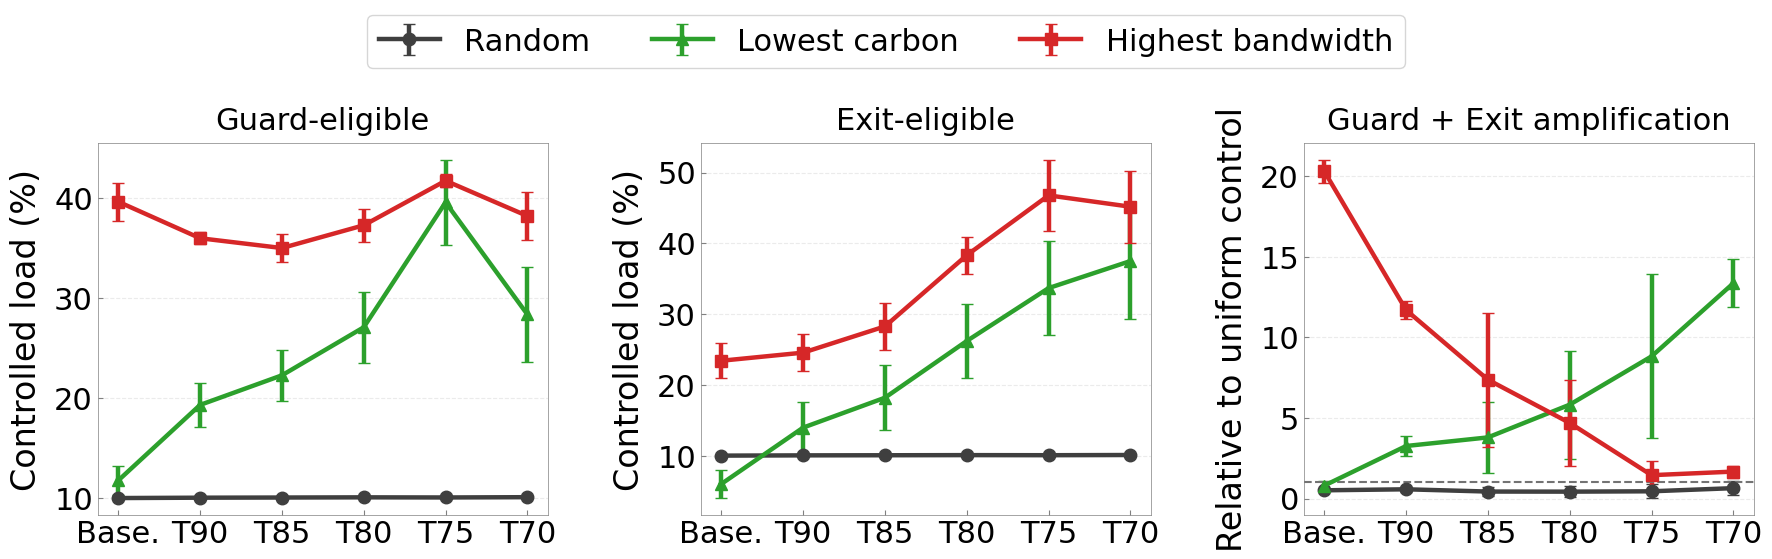

In [282]:
# Role-eligible exposure and empirical two-end compromise amplification.
fig, axes = plt.subplots(1, 3, figsize=(18.0, 6.2))
x = np.arange(len(CONFIG_ORDER))

for ax, role in zip(axes[:2], ["Guard-eligible", "Exit-eligible"]):
    for strategy in SECURITY_STRATEGY_LABELS:
        sub = (
            position_exposure_summary_df[
                (position_exposure_summary_df["role"] == role)
                & (position_exposure_summary_df["strategy"] == strategy)
            ]
            .set_index("config")
            .reindex(CONFIG_ORDER)
        )
        ax.errorbar(
            x, sub["exposure_pct"], yerr=sub["exposure_std"].fillna(0),
            color=SECURITY_STRATEGY_COLORS[strategy],
            marker=SECURITY_STRATEGY_MARKERS[strategy],
            linewidth=LINE_WIDTH, markersize=MARKER_SIZE, capsize=4,
            label=SECURITY_STRATEGY_LABELS[strategy],
        )
    ax.set_title(role, fontsize=FONT_SIZE, pad=10)
    ax.set_ylabel("Controlled load (%)", fontsize=LABEL_SIZE, labelpad=8)

for strategy in SECURITY_STRATEGY_LABELS:
    sub = (
        compromise_amplification_10_df[compromise_amplification_10_df["strategy"] == strategy]
        .set_index("config")
        .reindex(CONFIG_ORDER)
    )
    axes[2].errorbar(
        x, sub["amplification"], yerr=sub["amplification_std"].fillna(0),
        color=SECURITY_STRATEGY_COLORS[strategy],
        marker=SECURITY_STRATEGY_MARKERS[strategy],
        linewidth=LINE_WIDTH, markersize=MARKER_SIZE, capsize=4,
    )
axes[2].axhline(1, color="0.45", linestyle="--", linewidth=1.5)
axes[2].set_title("Guard + Exit amplification", fontsize=FONT_SIZE, pad=10)
axes[2].set_ylabel("Relative to uniform control", fontsize=LABEL_SIZE, labelpad=8)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(["Base.", "T90", "T85", "T80", "T75", "T70"])
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(axis="y", linestyle="--", alpha=0.25)
    format_axes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=3, loc="upper center", fontsize=LEGEND_SIZE, frameon=True)
fig.subplots_adjust(left=0.07, right=0.99, bottom=0.16, top=0.76, wspace=0.34)

out_path = FIGURES_DIR / "security_position_exposure_amplification.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

### 2. Jurisdictional concentration

Following the country-level adversary in [TAPS](https://www.ndss-symposium.org/ndss2017/ndss-2017-programme/avoding-man-wire-improving-tors-security-trust-aware-path-selection/), this measures how much simulated relay traffic the largest country coalitions cover. It is a traffic-concentration proxy; exact guard–exit jurisdiction compromise requires retained circuit paths.

In [283]:
# Cumulative relay-traffic coverage by the largest country coalitions.
jurisdiction_rows = []
jurisdiction_threshold_rows = []

for (network, config), countries in country_daily_load_df.groupby(["network", "config"]):
    countries = countries.sort_values("share", ascending=False).reset_index(drop=True)
    cumulative = countries["share"].cumsum() * 100
    for coalition_size in range(1, min(15, len(countries)) + 1):
        jurisdiction_rows.append({
            "network": network,
            "config": config,
            "coalition_size": coalition_size,
            "traffic_coverage_pct": cumulative.iloc[coalition_size - 1],
        })
    for threshold in [25, 50, 75]:
        reached = np.flatnonzero(cumulative.to_numpy() >= threshold)
        jurisdiction_threshold_rows.append({
            "network": network,
            "config": config,
            "threshold_pct": threshold,
            "countries_needed": int(reached[0] + 1) if len(reached) else np.nan,
        })

jurisdiction_network_df = pd.DataFrame(jurisdiction_rows)
jurisdiction_summary_df = (
    jurisdiction_network_df.groupby(["config", "coalition_size"], as_index=False)
    .agg(
        traffic_coverage_pct=("traffic_coverage_pct", "mean"),
        traffic_coverage_std=("traffic_coverage_pct", "std"),
    )
)
jurisdiction_threshold_network_df = pd.DataFrame(jurisdiction_threshold_rows)
jurisdiction_threshold_summary_df = (
    jurisdiction_threshold_network_df.groupby(["config", "threshold_pct"], as_index=False)
    .agg(countries_needed=("countries_needed", "mean"), countries_needed_std=("countries_needed", "std"))
)

jurisdiction_summary_df.to_csv(FIGURES_DIR / "security_jurisdiction_coalitions.csv", index=False)
jurisdiction_threshold_summary_df.to_csv(
    FIGURES_DIR / "security_jurisdiction_thresholds.csv", index=False
)
jurisdiction_threshold_summary_df

,config,threshold_pct,countries_needed,countries_needed_std
0,a0.20-k0.10-q1,25,1.8,0.447214
1,a0.20-k0.10-q1,50,3.8,0.447214
2,a0.20-k0.10-q1,75,8.2,0.447214
3,a0.30-k0.10-q1,25,2.0,0.000000
4,a0.30-k0.10-q1,50,4.8,0.447214
5,a0.30-k0.10-q1,75,8.6,0.547723
6,a0.50-k0.10-q1,25,2.0,0.000000
7,a0.50-k0.10-q1,50,5.0,0.000000
8,a0.50-k0.10-q1,75,8.8,0.447214
9,a1.0-k0.04-q1,25,2.0,0.000000


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_jurisdiction_coalition_coverage.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_jurisdiction_coalition_coverage.pdf


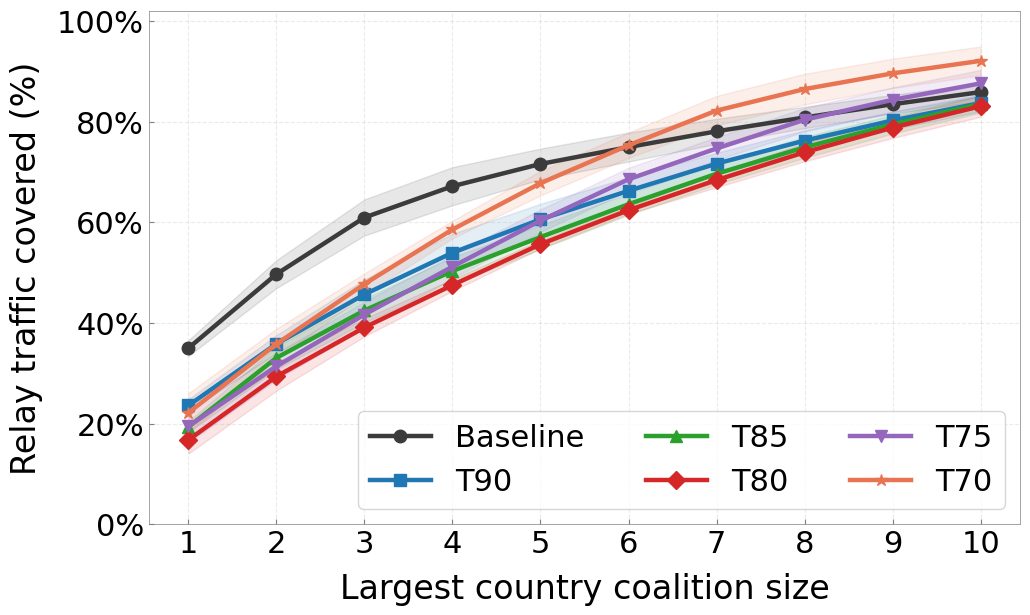

In [284]:
# Country-coalition traffic coverage.
fig, ax = plt.subplots(figsize=(10.5, 6.5))

for config in CONFIG_ORDER:
    sub = jurisdiction_summary_df[
        (jurisdiction_summary_df["config"] == config)
        & (jurisdiction_summary_df["coalition_size"] <= 10)
    ].sort_values("coalition_size")
    lower = np.maximum(0, sub["traffic_coverage_pct"] - sub["traffic_coverage_std"].fillna(0))
    upper = np.minimum(100, sub["traffic_coverage_pct"] + sub["traffic_coverage_std"].fillna(0))
    ax.plot(
        sub["coalition_size"], sub["traffic_coverage_pct"],
        color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
        linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        label=CONFIG_LABELS[config],
    )
    ax.fill_between(sub["coalition_size"], lower, upper, color=CONFIG_COLORS[config], alpha=0.12)

ax.set_xlabel("Largest country coalition size", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Relay traffic covered (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 102)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="both", labelsize=FONT_SIZE)
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.legend(ncol=3, fontsize=LEGEND_SIZE, frameon=True, loc="lower right")
format_axes(ax)
fig.subplots_adjust(left=0.15, right=0.98, bottom=0.18, top=0.97)

out_path = FIGURES_DIR / "security_jurisdiction_coalition_coverage.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

### 3. Persistent guard exposure

[Tor's guard design](https://spec.torproject.org/guard-spec/) keeps a small guard set rather than choosing a fresh guard independently for every circuit. Without multi-month client state in the retained logs, we model repeated independent samples of three guards using the measured guard-eligible load exposure above. This is a sensitivity analysis, not a timeline.

In [285]:
# Probability that at least one attacker guard is sampled across repeated guard-set draws.
persistent_guard_rows = []
guard_exposure_network_df = position_exposure_network_df[
    position_exposure_network_df["role"] == "Guard-eligible"
].copy()

for row in guard_exposure_network_df.itertuples(index=False):
    attacker_guard_probability = np.clip(row.exposure_pct / 100, 0, 1)
    for guard_set_samples in range(1, 13):
        sampled_guards = 3 * guard_set_samples
        persistent_guard_rows.append({
            "network": row.network,
            "config": row.config,
            "strategy": row.strategy,
            "guard_set_samples": guard_set_samples,
            "sampled_guards": sampled_guards,
            "attacker_guard_probability_pct": (
                1 - (1 - attacker_guard_probability) ** sampled_guards
            ) * 100,
        })

persistent_guard_network_df = pd.DataFrame(persistent_guard_rows)
persistent_guard_summary_df = (
    persistent_guard_network_df.groupby(
        ["config", "strategy", "guard_set_samples", "sampled_guards"], as_index=False
    )
    .agg(
        attacker_guard_probability_pct=("attacker_guard_probability_pct", "mean"),
        attacker_guard_probability_std=("attacker_guard_probability_pct", "std"),
    )
)
persistent_guard_summary_df.to_csv(
    FIGURES_DIR / "security_persistent_guard_exposure.csv", index=False
)
persistent_guard_summary_df.head()

,config,strategy,guard_set_samples,sampled_guards,attacker_guard_probability_pct,attacker_guard_probability_std
0,a0.20-k0.10-q1,high_bw,1,3,73.722114,0.763390
1,a0.20-k0.10-q1,high_bw,2,6,93.090065,0.405201
2,a0.20-k0.10-q1,high_bw,3,9,98.181741,0.161408
3,a0.20-k0.10-q1,high_bw,4,12,99.521214,0.057187
4,a0.20-k0.10-q1,high_bw,5,15,99.873836,0.019006


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_persistent_guard_exposure.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_persistent_guard_exposure.pdf


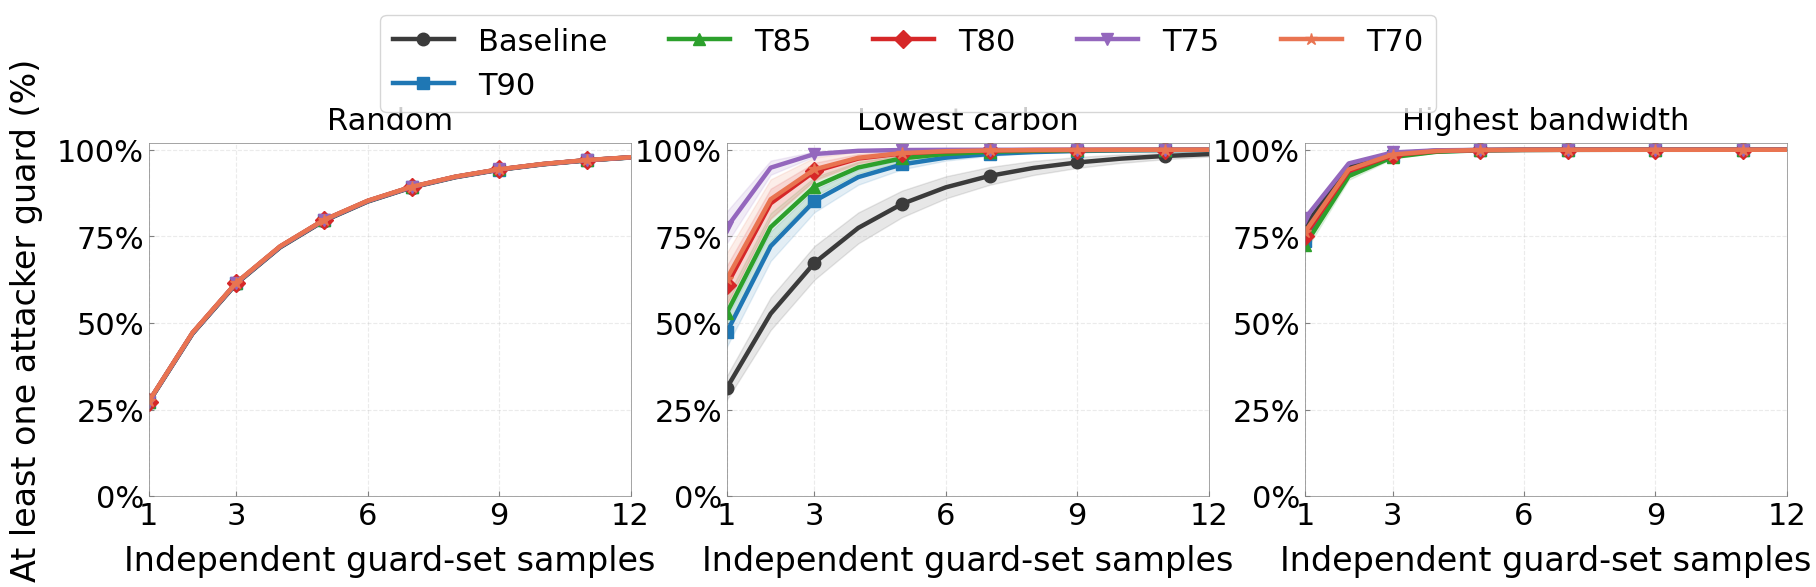

In [286]:
# Repeated guard-set exposure for each attacker strategy.
fig, axes = plt.subplots(1, 3, figsize=(18.0, 6.2), sharey=True)

for ax, strategy in zip(axes, SECURITY_STRATEGY_LABELS):
    for config in CONFIG_ORDER:
        sub = persistent_guard_summary_df[
            (persistent_guard_summary_df["strategy"] == strategy)
            & (persistent_guard_summary_df["config"] == config)
        ].sort_values("guard_set_samples")
        lower = np.maximum(
            0,
            sub["attacker_guard_probability_pct"]
            - sub["attacker_guard_probability_std"].fillna(0),
        )
        upper = np.minimum(
            100,
            sub["attacker_guard_probability_pct"]
            + sub["attacker_guard_probability_std"].fillna(0),
        )
        ax.plot(
            sub["guard_set_samples"], sub["attacker_guard_probability_pct"],
            color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
            linewidth=LINE_WIDTH, markersize=MARKER_SIZE, markevery=2,
            label=CONFIG_LABELS[config],
        )
        ax.fill_between(
            sub["guard_set_samples"], lower, upper,
            color=CONFIG_COLORS[config], alpha=0.12,
        )
    ax.set_title(SECURITY_STRATEGY_LABELS[strategy], fontsize=FONT_SIZE, pad=10)
    ax.set_xlabel("Independent guard-set samples", fontsize=LABEL_SIZE, labelpad=10)
    ax.set_xlim(1, 12)
    ax.set_ylim(0, 102)
    ax.set_xticks([1, 3, 6, 9, 12])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    format_axes(ax)

axes[0].set_ylabel("At least one attacker guard (%)", fontsize=LABEL_SIZE, labelpad=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc="upper center", fontsize=LEGEND_SIZE, frameon=True)
fig.subplots_adjust(left=0.08, right=0.99, bottom=0.19, top=0.76, wspace=0.20)

out_path = FIGURES_DIR / "security_persistent_guard_exposure.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_persistent_guard_exposure_random.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_persistent_guard_exposure_random.pdf


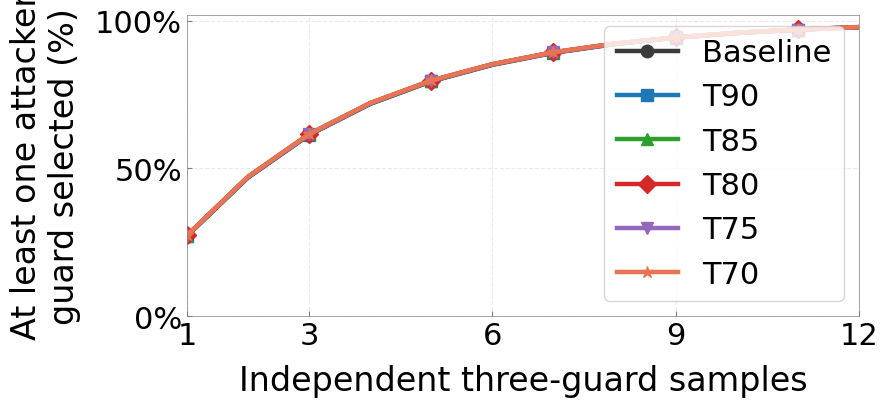

In [287]:
# Repeated three-guard samples for a random-relay attacker.
fig, ax = plt.subplots(figsize=(8, 4.5))

for config in CONFIG_ORDER:
    sub = persistent_guard_summary_df[
        (persistent_guard_summary_df["strategy"] == "random")
        & (persistent_guard_summary_df["config"] == config)
    ].sort_values("guard_set_samples")
    lower = np.maximum(
        0,
        sub["attacker_guard_probability_pct"]
        - sub["attacker_guard_probability_std"].fillna(0),
    )
    upper = np.minimum(
        100,
        sub["attacker_guard_probability_pct"]
        + sub["attacker_guard_probability_std"].fillna(0),
    )
    ax.plot(
        sub["guard_set_samples"], sub["attacker_guard_probability_pct"],
        color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
        linewidth=LINE_WIDTH, markersize=MARKER_SIZE, markevery=2,
        label=CONFIG_LABELS[config],
    )
    ax.fill_between(
        sub["guard_set_samples"], lower, upper,
        color=CONFIG_COLORS[config], alpha=0.12,
    )

ax.set_xlabel("Independent three-guard samples", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("At least one attacker\nguard selected (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xlim(1, 12)
ax.set_ylim(0, 102)
ax.set_xticks([1, 3, 6, 9, 12])
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="both", labelsize=FONT_SIZE)
ax.grid(axis="both", linestyle="--", alpha=0.25)
format_axes(ax)
ax.legend(ncol=1, loc="lower right", fontsize=LEGEND_SIZE, frameon=True)
fig.subplots_adjust(left=0.15, right=0.99, bottom=0.19, top=0.86)

out_path = FIGURES_DIR / "security_persistent_guard_exposure_random.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

In [288]:
# Y-value at x=1 (first guard-set sample) for the random-attacker figure.
first_sample_df = (
    persistent_guard_summary_df[
        (persistent_guard_summary_df["strategy"] == "random")
        & (persistent_guard_summary_df["guard_set_samples"] == 12)
    ]
    .set_index("config")
    .reindex(CONFIG_ORDER)[["attacker_guard_probability_pct", "attacker_guard_probability_std"]]
)
first_sample_df["setting"] = ["Base." if c == "baseline" else CONFIG_LABELS[c] for c in CONFIG_ORDER]
first_sample_df = first_sample_df[["setting", "attacker_guard_probability_pct", "attacker_guard_probability_std"]]

print(first_sample_df.round(2))
# Average of the x=1 values across configs.
avg_first_sample_pct = first_sample_df["attacker_guard_probability_pct"].mean()
print(f"Average across all configs (including baseline): {avg_first_sample_pct:.2f}%")


               setting  attacker_guard_probability_pct  \
config                                                   
baseline         Base.                           97.76   
a0.20-k0.10-q1     T90                           97.80   
a0.30-k0.10-q1     T85                           97.81   
a0.50-k0.10-q1     T80                           97.83   
a1.0-k0.04-q1      T75                           97.82   
a1.0-k0.10-q1      T70                           97.84   

                attacker_guard_probability_std  
config                                          
baseline                                  0.02  
a0.20-k0.10-q1                            0.05  
a0.30-k0.10-q1                            0.02  
a0.50-k0.10-q1                            0.04  
a1.0-k0.04-q1                             0.06  
a1.0-k0.10-q1                             0.05  
Average across all configs (including baseline): 97.81%


### 4. Carbon-aware selective denial of service

A low-carbon attacker may reject circuits that are not already end-compromised and force clients to retry. Starting from the measured 10% low-carbon-attacker result, this upper-bound model varies the fraction of otherwise uncompromised circuits rejected. It does not model [Tor's Path Bias defense](https://spec.torproject.org/path-spec/detecting-route-manipulation.html) or the performance feedback of retries.

In [289]:
# Analytical selective-failure amplification of measured Guard + Exit compromise.
selective_dos_rows = []
selective_dos_base_df = security_sybil_df[
    (security_sybil_df["strategy"] == "low_ci")
    & (security_sybil_df["percent"] == ATTACK_BUDGET_PCT)
].copy()

for row in selective_dos_base_df.itertuples(index=False):
    compromise_probability = float(row.match_rate_2hop)
    for rejected_uncompromised_pct in range(0, 91, 5):
        rejected_probability = rejected_uncompromised_pct / 100
        acceptance_probability = (
            compromise_probability
            + (1 - compromise_probability) * (1 - rejected_probability)
        )
        selective_dos_rows.append({
            "network": row.network,
            "config": row.config,
            "rejected_uncompromised_pct": rejected_uncompromised_pct,
            "effective_compromise_pct": (
                compromise_probability / acceptance_probability * 100
            ),
            "accepted_attempts_pct": acceptance_probability * 100,
            "expected_attempts": 1 / acceptance_probability,
        })

selective_dos_network_df = pd.DataFrame(selective_dos_rows)
selective_dos_summary_df = (
    selective_dos_network_df.groupby(
        ["config", "rejected_uncompromised_pct"], as_index=False
    )
    .agg(
        effective_compromise_pct=("effective_compromise_pct", "mean"),
        effective_compromise_std=("effective_compromise_pct", "std"),
        expected_attempts=("expected_attempts", "mean"),
        expected_attempts_std=("expected_attempts", "std"),
    )
)
selective_dos_summary_df.to_csv(
    FIGURES_DIR / "security_selective_dos_counterfactual.csv", index=False
)
selective_dos_summary_df.head()

,config,rejected_uncompromised_pct,effective_compromise_pct,effective_compromise_std,expected_attempts,expected_attempts_std
0,a0.20-k0.10-q1,0,3.261480,0.602888,1.000000,0.000000
1,a0.20-k0.10-q1,5,3.427093,0.632337,1.050828,0.000333
2,a0.20-k0.10-q1,10,3.610427,0.664806,1.107100,0.000739
3,a0.20-k0.10-q1,15,3.814484,0.700784,1.169739,0.001237
4,a0.20-k0.10-q1,20,4.042991,0.740871,1.239893,0.001852


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_selective_dos_counterfactual.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_selective_dos_counterfactual.pdf


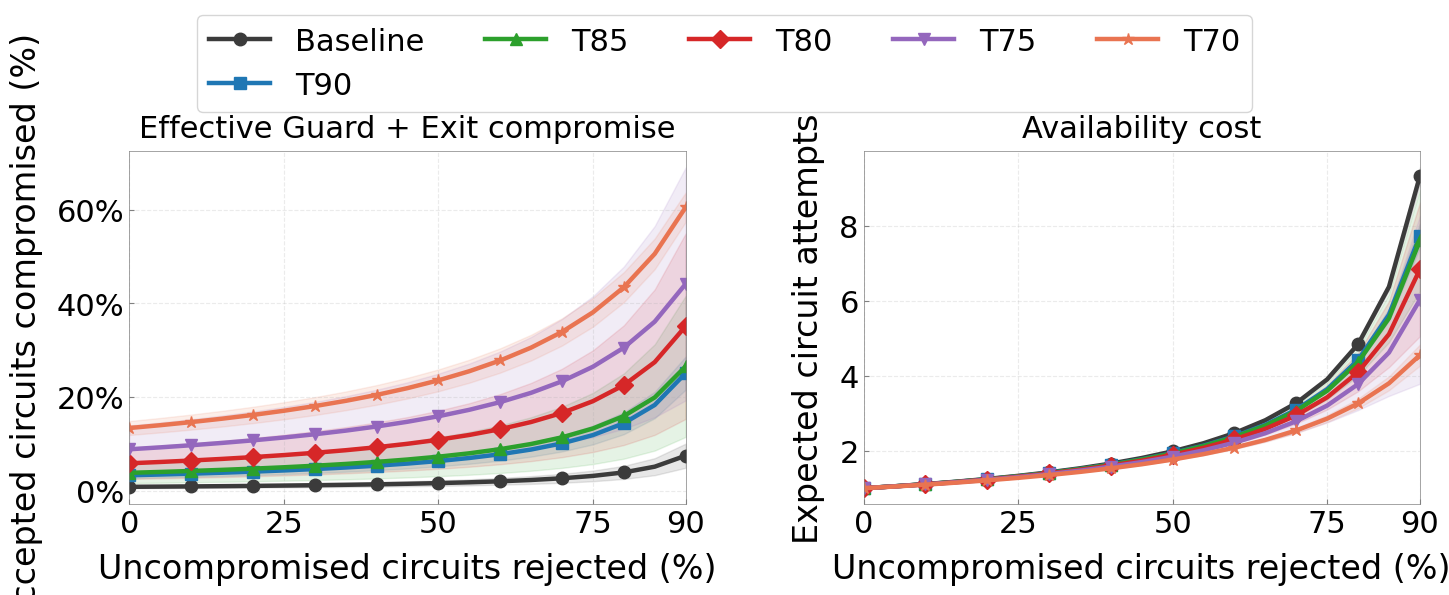

In [290]:
# Compromise amplification and retry cost under selective failures.
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.3))

for config in CONFIG_ORDER:
    sub = selective_dos_summary_df[
        selective_dos_summary_df["config"] == config
    ].sort_values("rejected_uncompromised_pct")
    for ax, mean_col, std_col in [
        (axes[0], "effective_compromise_pct", "effective_compromise_std"),
        (axes[1], "expected_attempts", "expected_attempts_std"),
    ]:
        lower = np.maximum(0, sub[mean_col] - sub[std_col].fillna(0))
        upper = sub[mean_col] + sub[std_col].fillna(0)
        ax.plot(
            sub["rejected_uncompromised_pct"], sub[mean_col],
            color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
            linewidth=LINE_WIDTH, markersize=MARKER_SIZE, markevery=2,
            label=CONFIG_LABELS[config],
        )
        ax.fill_between(
            sub["rejected_uncompromised_pct"], lower, upper,
            color=CONFIG_COLORS[config], alpha=0.12,
        )

axes[0].set_title("Effective Guard + Exit compromise", fontsize=FONT_SIZE, pad=10)
axes[0].set_ylabel("Accepted circuits compromised (%)", fontsize=LABEL_SIZE, labelpad=10)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
axes[1].set_title("Availability cost", fontsize=FONT_SIZE, pad=10)
axes[1].set_ylabel("Expected circuit attempts", fontsize=LABEL_SIZE, labelpad=10)

for ax in axes:
    ax.set_xlabel("Uncompromised circuits rejected (%)", fontsize=LABEL_SIZE, labelpad=10)
    ax.set_xlim(0, 90)
    ax.set_xticks([0, 25, 50, 75, 90])
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    format_axes(ax)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc="upper center", fontsize=LEGEND_SIZE, frameon=True)
fig.subplots_adjust(left=0.10, right=0.99, bottom=0.19, top=0.75, wspace=0.32)

out_path = FIGURES_DIR / "security_selective_dos_counterfactual.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

### 5. Routing-layer exposure

[RAPTOR](https://www.usenix.org/conference/usenixsecurity15/technical-sessions/presentation/sun)-style analysis requires client–guard and exit–destination AS paths, including asymmetric routes. Those paths are not present in these caches. The figure below is the measurable lower bound: the fraction of all circuits whose guard and exit are co-located in the largest coalition of relay-hosting ASNs. It does not include transit ASes, sibling organizations, IXPs, BGP hijacks, or RPKI status.

The path is a TODO for next time

In [291]:
# Lower bound from coalitions of relay-hosting ASNs with same-AS Guard + Exit circuits.
guard_exit_provider_df = security_asn_match_df[
    security_asn_match_df["outcome"] == "Guard and exit"
].copy()

hosting_as_coalition_rows = []

for (network, config), matches in guard_exit_provider_df.groupby(["network", "config"]):
    asn_counts = matches.groupby("asn")["matches"].sum().sort_values(ascending=False)
    total_circuits = matches["total_circuits"].iloc[0]
    cumulative_matches = asn_counts.cumsum()
    for coalition_size in range(1, min(10, len(cumulative_matches)) + 1):
        hosting_as_coalition_rows.append({
            "network": network,
            "config": config,
            "coalition_size": coalition_size,
            "same_host_as_circuit_pct": (
                cumulative_matches.iloc[coalition_size - 1] / total_circuits * 100
            ),
        })

hosting_as_coalition_network_df = pd.DataFrame(hosting_as_coalition_rows)
hosting_as_coalition_summary_df = (
    hosting_as_coalition_network_df.groupby(["config", "coalition_size"], as_index=False)
    .agg(
        same_host_as_circuit_pct=("same_host_as_circuit_pct", "mean"),
        same_host_as_circuit_std=("same_host_as_circuit_pct", "std"),
    )
)
hosting_as_coalition_summary_df.to_csv(
    FIGURES_DIR / "security_hosting_as_coalition_lower_bound.csv", index=False
)
hosting_as_coalition_summary_df.head()

,config,coalition_size,same_host_as_circuit_pct,same_host_as_circuit_std
0,a0.20-k0.10-q1,1,0.429174,0.139604
1,a0.20-k0.10-q1,2,0.672225,0.269008
2,a0.20-k0.10-q1,3,0.801333,0.275335
3,a0.20-k0.10-q1,4,0.881572,0.304882
4,a0.20-k0.10-q1,5,0.929187,0.313965


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_hosting_as_coalition_lower_bound.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_hosting_as_coalition_lower_bound.pdf


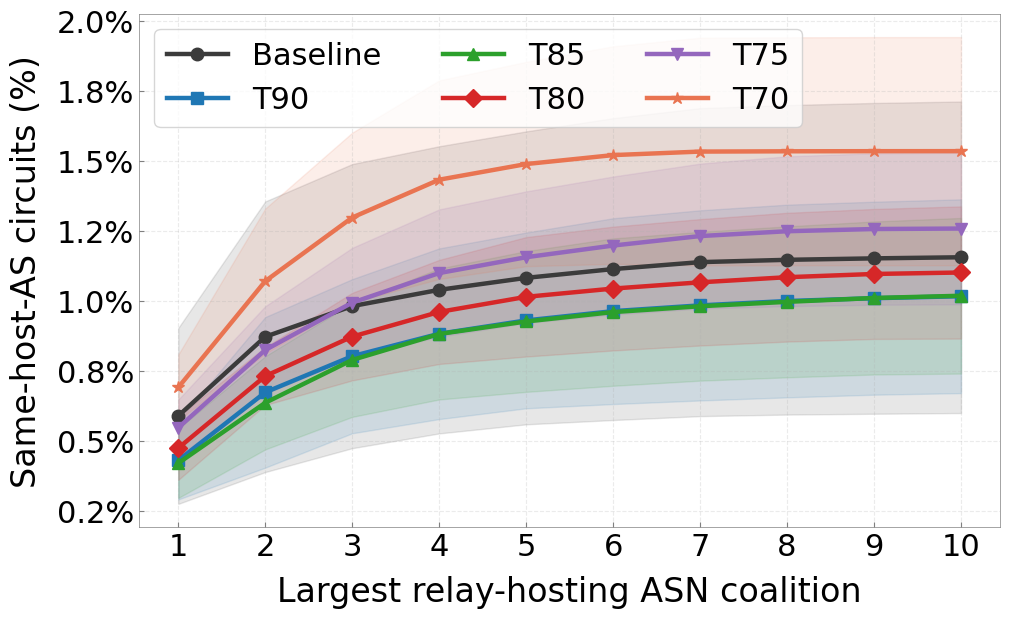

In [292]:
# Lower-bound circuit exposure to coalitions of relay-hosting ASNs.
fig, ax = plt.subplots(figsize=(10.5, 6.5))

for config in CONFIG_ORDER:
    sub = hosting_as_coalition_summary_df[
        hosting_as_coalition_summary_df["config"] == config
    ].sort_values("coalition_size")
    lower = np.maximum(
        0, sub["same_host_as_circuit_pct"] - sub["same_host_as_circuit_std"].fillna(0)
    )
    upper = sub["same_host_as_circuit_pct"] + sub["same_host_as_circuit_std"].fillna(0)
    ax.plot(
        sub["coalition_size"], sub["same_host_as_circuit_pct"],
        color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
        linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        label=CONFIG_LABELS[config],
    )
    ax.fill_between(
        sub["coalition_size"], lower, upper,
        color=CONFIG_COLORS[config], alpha=0.12,
    )

ax.set_xlabel("Largest relay-hosting ASN coalition", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Same-host-AS circuits (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
ax.tick_params(axis="both", labelsize=FONT_SIZE)
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.legend(ncol=3, fontsize=LEGEND_SIZE, frameon=True, loc="upper left")
format_axes(ax)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.18, top=0.97)

out_path = FIGURES_DIR / "security_hosting_as_coalition_lower_bound.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

### 6. Targeted relay outage

Motivated by targeted relay attacks such as [Sniper](https://www.robgjansen.com/publications/sniper-ndss2014.html) and [Point Break](https://www.usenix.org/system/files/sec19-jansen.pdf), this first-order stress test removes either the most-used relays or the lowest-carbon relays and reports their observed share of relay selections. It measures immediate exposure before path rebuilding. 

In [293]:
# Immediate observed relay load affected by targeted removal.
outage_strategy_labels = {
    "highest_load": "Highest-load relays",
    "lowest_carbon": "Lowest-carbon relays",
}
targeted_outage_rows = []

for (network, config), relays in security_relay_daily_df.groupby(["network", "config"]):
    total_load = relays["circuit_uses"].sum()
    for strategy in outage_strategy_labels:
        if strategy == "highest_load":
            ranked = relays.sort_values("circuit_uses", ascending=False)
        else:
            ranked = relays.sort_values(
                ["carbon_intensity", "circuit_uses"], ascending=[True, False]
            )

        for removed_relays_pct in range(1, 21):
            removed_relays = max(1, int(np.ceil(len(ranked) * removed_relays_pct / 100)))
            removed = ranked.head(removed_relays)
            targeted_outage_rows.append({
                "network": network,
                "config": config,
                "strategy": strategy,
                "removed_relays_pct": removed_relays_pct,
                "removed_relays": removed_relays,
                "affected_load_pct": removed["circuit_uses"].sum() / total_load * 100,
            })

targeted_outage_network_df = pd.DataFrame(targeted_outage_rows)
targeted_outage_summary_df = (
    targeted_outage_network_df.groupby(
        ["config", "strategy", "removed_relays_pct"], as_index=False
    )
    .agg(
        affected_load_pct=("affected_load_pct", "mean"),
        affected_load_std=("affected_load_pct", "std"),
    )
)
targeted_outage_summary_df.to_csv(
    FIGURES_DIR / "security_targeted_outage_exposure.csv", index=False
)
targeted_outage_summary_df[
    targeted_outage_summary_df["removed_relays_pct"].isin([5, 10])
]

,config,strategy,removed_relays_pct,affected_load_pct,affected_load_std
4,a0.20-k0.10-q1,highest_load,5,19.834757,0.710337
9,a0.20-k0.10-q1,highest_load,10,32.832769,0.780064
24,a0.20-k0.10-q1,lowest_carbon,5,7.222294,0.766276
29,a0.20-k0.10-q1,lowest_carbon,10,18.590658,0.809014
44,a0.30-k0.10-q1,highest_load,5,19.407571,0.745192
49,a0.30-k0.10-q1,highest_load,10,33.580330,0.970501
64,a0.30-k0.10-q1,lowest_carbon,5,8.609530,0.977854
69,a0.30-k0.10-q1,lowest_carbon,10,21.840617,1.123277
84,a0.50-k0.10-q1,highest_load,5,21.750235,0.728464
89,a0.50-k0.10-q1,highest_load,10,39.017578,1.317781


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_targeted_outage_exposure.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_targeted_outage_exposure.pdf


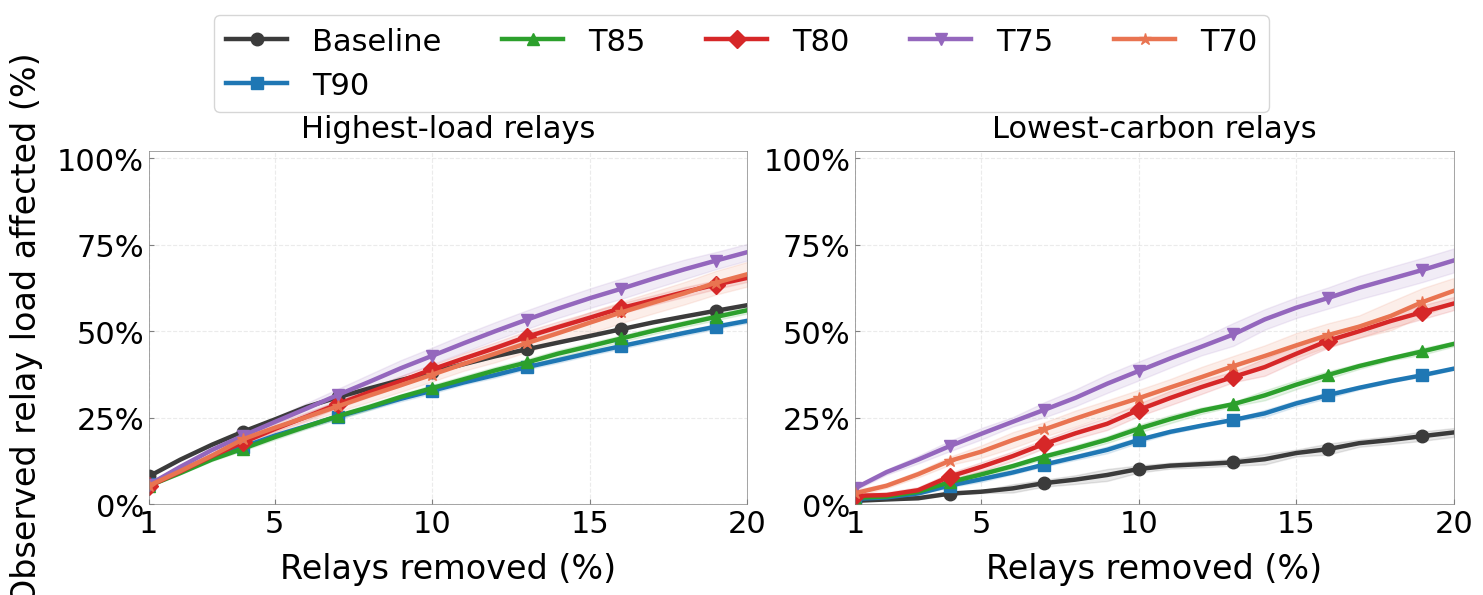

In [294]:
# First-order load exposure under targeted relay outages.
fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.3), sharey=True)

for ax, strategy in zip(axes, outage_strategy_labels):
    for config in CONFIG_ORDER:
        sub = targeted_outage_summary_df[
            (targeted_outage_summary_df["strategy"] == strategy)
            & (targeted_outage_summary_df["config"] == config)
        ].sort_values("removed_relays_pct")
        lower = np.maximum(0, sub["affected_load_pct"] - sub["affected_load_std"].fillna(0))
        upper = np.minimum(100, sub["affected_load_pct"] + sub["affected_load_std"].fillna(0))
        ax.plot(
            sub["removed_relays_pct"], sub["affected_load_pct"],
            color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
            linewidth=LINE_WIDTH, markersize=MARKER_SIZE, markevery=3,
            label=CONFIG_LABELS[config],
        )
        ax.fill_between(
            sub["removed_relays_pct"], lower, upper,
            color=CONFIG_COLORS[config], alpha=0.12,
        )
    ax.set_title(outage_strategy_labels[strategy], fontsize=FONT_SIZE, pad=10)
    ax.set_xlabel("Relays removed (%)", fontsize=LABEL_SIZE, labelpad=10)
    ax.set_xlim(1, 20)
    ax.set_ylim(0, 102)
    ax.set_xticks([1, 5, 10, 15, 20])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
    ax.tick_params(axis="both", labelsize=FONT_SIZE)
    ax.grid(axis="both", linestyle="--", alpha=0.25)
    format_axes(ax)

axes[0].set_ylabel("Observed relay load affected (%)", fontsize=LABEL_SIZE, labelpad=10)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=5, loc="upper center", fontsize=LEGEND_SIZE, frameon=True)
fig.subplots_adjust(left=0.09, right=0.99, bottom=0.19, top=0.75, wspace=0.18)

out_path = FIGURES_DIR / "security_targeted_outage_exposure.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

In [295]:
# Estimated all-three circuit exposure to the largest colluding-country sets.
country_collusion_rows = []

for (network, config), relays in security_relay_daily_df.groupby(["network", "config"]):
    countries = (
        relays.groupby("country", as_index=False)
        .agg(circuit_uses=("circuit_uses", "sum"))
        .sort_values("circuit_uses", ascending=False)
        .reset_index(drop=True)
    )
    countries["selection_share"] = countries["circuit_uses"] / countries["circuit_uses"].sum()
    cumulative_share = countries["selection_share"].cumsum()

    for colluding_countries in range(1, min(10, len(countries)) + 1):
        colluding_selection_share = cumulative_share.iloc[colluding_countries - 1]
        country_collusion_rows.append({
            "network": network,
            "config": config,
            "colluding_countries": colluding_countries,
            "colluding_selection_share": colluding_selection_share,
            "all_three_circuits_pct": colluding_selection_share ** 3 * 100,
        })

country_collusion_network_df = pd.DataFrame(country_collusion_rows)
country_collusion_summary_df = (
    country_collusion_network_df.groupby(["config", "colluding_countries"], as_index=False)
    .agg(
        all_three_circuits_pct=("all_three_circuits_pct", "mean"),
        all_three_circuits_std=("all_three_circuits_pct", "std"),
    )
)

country_collusion_summary_df.to_csv(
    FIGURES_DIR / "security_country_collusion_all_three_estimate.csv", index=False
)
country_collusion_summary_df.head()

,config,colluding_countries,all_three_circuits_pct,all_three_circuits_std
0,a0.20-k0.10-q1,1,1.080274,0.171721
1,a0.20-k0.10-q1,2,4.064176,0.820601
2,a0.20-k0.10-q1,3,9.010329,2.172109
3,a0.20-k0.10-q1,4,14.899820,3.599643
4,a0.20-k0.10-q1,5,21.465567,3.905965


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_country_collusion_all_three_estimate.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_country_collusion_all_three_estimate.pdf


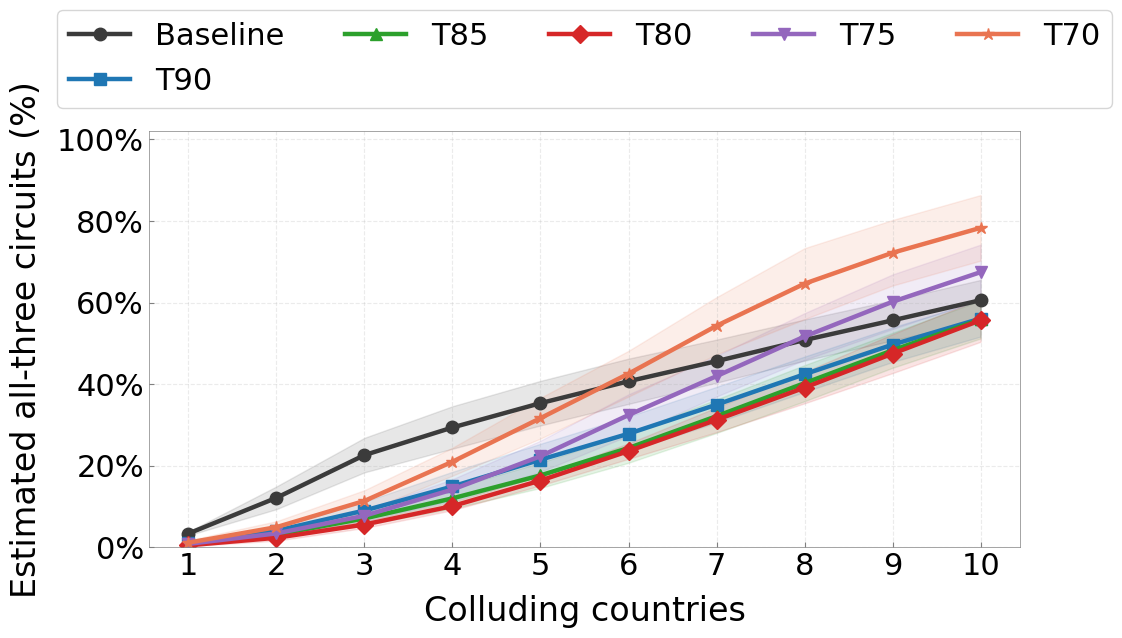

In [296]:
# Estimated all-three circuit exposure to colluding countries.
fig, ax = plt.subplots(figsize=(10.5, 6.5))

for config in CONFIG_ORDER:
    sub = country_collusion_summary_df[
        country_collusion_summary_df["config"] == config
    ].sort_values("colluding_countries")
    lower = np.maximum(0, sub["all_three_circuits_pct"] - sub["all_three_circuits_std"].fillna(0))
    upper = np.minimum(100, sub["all_three_circuits_pct"] + sub["all_three_circuits_std"].fillna(0))
    ax.plot(
        sub["colluding_countries"], sub["all_three_circuits_pct"],
        color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
        linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        label=CONFIG_LABELS[config],
    )
    ax.fill_between(sub["colluding_countries"], lower, upper, color=CONFIG_COLORS[config], alpha=0.12)

ax.set_xlabel("Colluding countries", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Estimated all-three circuits (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 102)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=0))
ax.tick_params(axis="both", labelsize=FONT_SIZE)
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.legend(
    ncol=5, fontsize=LEGEND_SIZE, frameon=True,
    loc="lower center", bbox_to_anchor=(0.5, 1.02),
)
format_axes(ax)
fig.subplots_adjust(left=0.15, right=0.98, bottom=0.18, top=0.82)

out_path = FIGURES_DIR / "security_country_collusion_all_three_estimate.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()

In [297]:
# Largest country by traffic share, per config.
largest_country_rows = []
for config in CONFIG_ORDER:
    sub = country_avg_df[country_avg_df["config"] == config].sort_values("data_share", ascending=False)
    top = sub.iloc[0]
    largest_country_rows.append({
        "config": config,
        "setting": "Base." if config == "baseline" else CONFIG_LABELS[config],
        "country": top["country"],
        "data_share": top["data_share"],
    })

largest_country_df = pd.DataFrame(largest_country_rows)
print(largest_country_df[["setting", "country", "data_share"]].round(2))

  setting country  data_share
0   Base.      DE       34.97
1     T90      DE       23.59
2     T85      DE       19.35
3     T80      FR       16.74
4     T75      FR       19.45
5     T70      FR       22.14


In [298]:
# Top-3 countries by traffic share, summed, per config.
top3_country_rows = []
for config in CONFIG_ORDER:
    sub = country_avg_df[country_avg_df["config"] == config].sort_values("data_share", ascending=False)
    top3 = sub.head(10)
    top3_country_rows.append({
        "config": config,
        "setting": "Base." if config == "baseline" else CONFIG_LABELS[config],
        "countries": ", ".join(f"{row.country} ({row.data_share:.1f}%)" for row in top3.itertuples()),
        "top3_data_share": top3["data_share"].sum(),
    })

top3_country_df = pd.DataFrame(top3_country_rows)
print(top3_country_df[["setting", "countries", "top3_data_share"]].round(2))

  setting                                          countries  top3_data_share
0   Base.  DE (35.0%), US (13.9%), NL (12.1%), FR (6.0%),...            84.90
1     T90  DE (23.6%), FR (11.8%), US (9.7%), NL (8.5%), ...            83.10
2     T85  DE (19.3%), FR (13.7%), US (8.3%), NL (7.1%), ...            83.01
3     T80  FR (16.7%), DE (12.6%), SE (8.4%), CH (8.2%), ...            82.73
4     T75  FR (19.5%), SE (10.4%), DE (9.9%), CH (9.5%), ...            87.30
5     T70  FR (22.1%), SE (11.8%), CH (11.1%), FI (9.8%),...            92.01


In [299]:
# Lower bound from colluding relay-hosting ASNs with same-AS Guard + Exit circuits.
guard_exit_provider_df = security_asn_match_df[
    security_asn_match_df["outcome"] == "Guard and exit"
].copy()

hosting_as_collusion_rows = []

for (network, config), matches in guard_exit_provider_df.groupby(["network", "config"]):
    asn_counts = matches.groupby("asn")["matches"].sum().sort_values(ascending=False)
    total_circuits = matches["total_circuits"].iloc[0]
    cumulative_matches = asn_counts.cumsum()
    for colluding_asns in range(1, min(10, len(cumulative_matches)) + 1):
        hosting_as_collusion_rows.append({
            "network": network,
            "config": config,
            "colluding_asns": colluding_asns,
            "same_host_as_circuit_pct": (
                cumulative_matches.iloc[colluding_asns - 1] / total_circuits * 100
            ),
        })

hosting_as_collusion_network_df = pd.DataFrame(hosting_as_collusion_rows)
hosting_as_collusion_summary_df = (
    hosting_as_collusion_network_df.groupby(["config", "colluding_asns"], as_index=False)
    .agg(
        same_host_as_circuit_pct=("same_host_as_circuit_pct", "mean"),
        same_host_as_circuit_std=("same_host_as_circuit_pct", "std"),
    )
)
hosting_as_collusion_summary_df.to_csv(
    FIGURES_DIR / "security_hosting_as_collusion_lower_bound.csv", index=False
)
hosting_as_collusion_summary_df.head()

,config,colluding_asns,same_host_as_circuit_pct,same_host_as_circuit_std
0,a0.20-k0.10-q1,1,0.429174,0.139604
1,a0.20-k0.10-q1,2,0.672225,0.269008
2,a0.20-k0.10-q1,3,0.801333,0.275335
3,a0.20-k0.10-q1,4,0.881572,0.304882
4,a0.20-k0.10-q1,5,0.929187,0.313965


/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_hosting_as_collusion_lower_bound.png
/Users/ramontorres/Desktop/sustainability/new-results/figures/section5/security_hosting_as_collusion_lower_bound.pdf


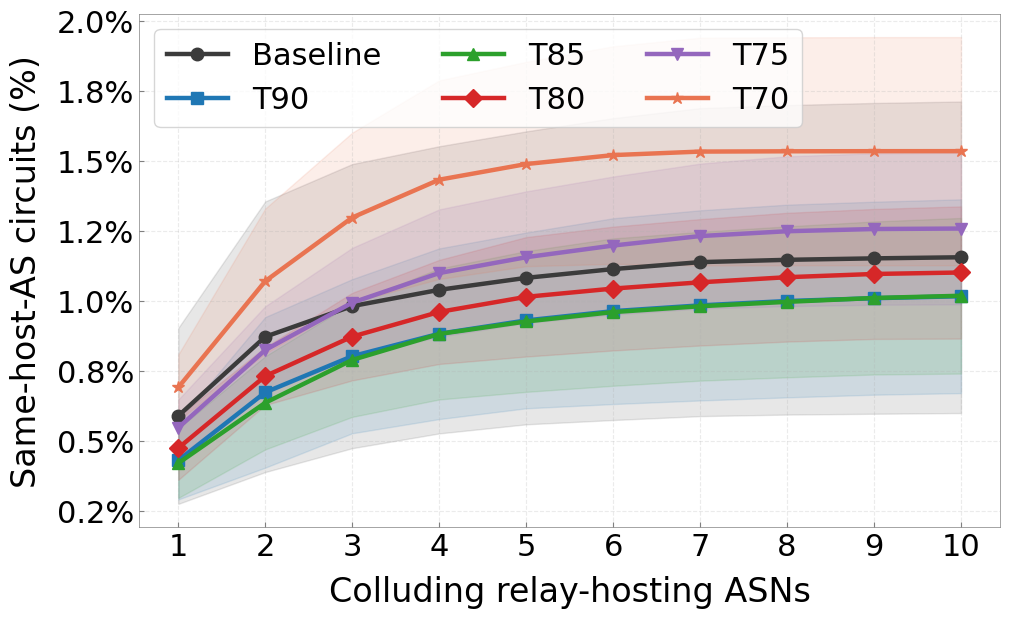

In [300]:
# Lower-bound circuit exposure to colluding relay-hosting ASNs.
fig, ax = plt.subplots(figsize=(10.5, 6.5))

for config in CONFIG_ORDER:
    sub = hosting_as_collusion_summary_df[
        hosting_as_collusion_summary_df["config"] == config
    ].sort_values("colluding_asns")
    lower = np.maximum(
        0, sub["same_host_as_circuit_pct"] - sub["same_host_as_circuit_std"].fillna(0)
    )
    upper = sub["same_host_as_circuit_pct"] + sub["same_host_as_circuit_std"].fillna(0)
    ax.plot(
        sub["colluding_asns"], sub["same_host_as_circuit_pct"],
        color=CONFIG_COLORS[config], marker=CONFIG_MARKERS[config],
        linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        label=CONFIG_LABELS[config],
    )
    ax.fill_between(
        sub["colluding_asns"], lower, upper,
        color=CONFIG_COLORS[config], alpha=0.12,
    )

ax.set_xlabel("Colluding relay-hosting ASNs", fontsize=LABEL_SIZE, labelpad=10)
ax.set_ylabel("Same-host-AS circuits (%)", fontsize=LABEL_SIZE, labelpad=10)
ax.set_xticks(range(1, 11))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
ax.tick_params(axis="both", labelsize=FONT_SIZE)
ax.grid(axis="both", linestyle="--", alpha=0.25)
ax.legend(ncol=3, fontsize=LEGEND_SIZE, frameon=True, loc="upper left")
format_axes(ax)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.18, top=0.97)

out_path = FIGURES_DIR / "security_hosting_as_collusion_lower_bound.png"
png_path, pdf_path = save_figure(fig, out_path, bbox_inches="tight", pad_inches=0.05)
print(png_path)
print(pdf_path)
plt.show()